# Turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook runs the 1D turbulence synthesis experiment and compares MGD theta trajectories with the regularised trajectories. 


In [1]:
import torch
import numpy as np
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

<class 'SyntaxError'>: from __future__ imports must occur at the beginning of the file (data_loader.py, line 116)

## Data preprocessing: jets data

In [ ]:
dataset = load_helium_jets() 

In [4]:
dataset.keys() 

<class 'AttributeError'>: 'HeliumJetDataset' object has no attribute 'keys'

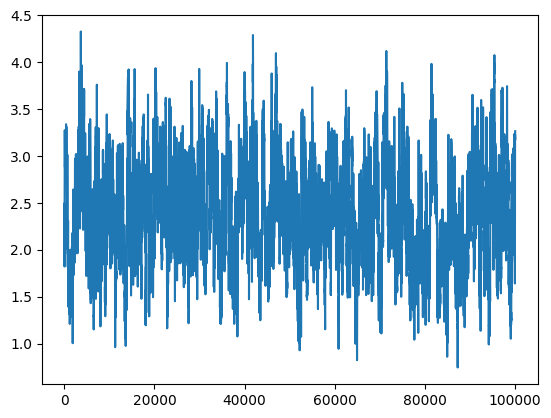

In [10]:
%matplotlib inline
plt.plot(Data[0,0,:100000]) 
plt.show() 

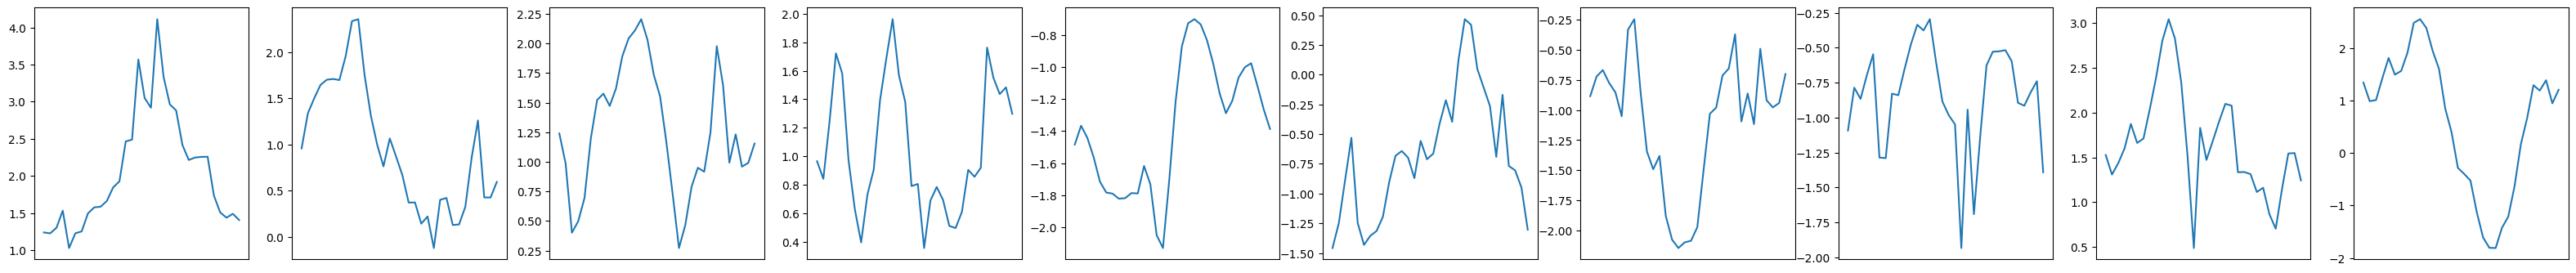

In [77]:
plot_time_series_row(x1, 10)


## Shared model/SDE parameters

In [78]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 5
Q = 3

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

print("filters shape:", filters.shape) 
print("filters Q shape:", filters_Q.shape) 

interpolant = 'Cos'
nt = 70000

# originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2  # LINEAR SCHEDULE 
sigma = 25

nb_workers = x1.shape[0]
nb_interpolants = x1.shape[0]
batch_size = x1.shape[0] 
regularization = 1e-1

base_config = f'turbulence_synthesis_{M}_J_{J}_Q_{Q}_sigma_{sigma}'
print('base_config:', base_config)


(B, C, T) = (2000, 1, 32).
filters shape: torch.Size([1, 6, 32])
filters Q shape: torch.Size([1, 16, 32])
base_config: turbulence_synthesis_32_J_5_Q_3_sigma_25


## Check wavelet coefficients histograms

torch.Size([2000, 6, 32])


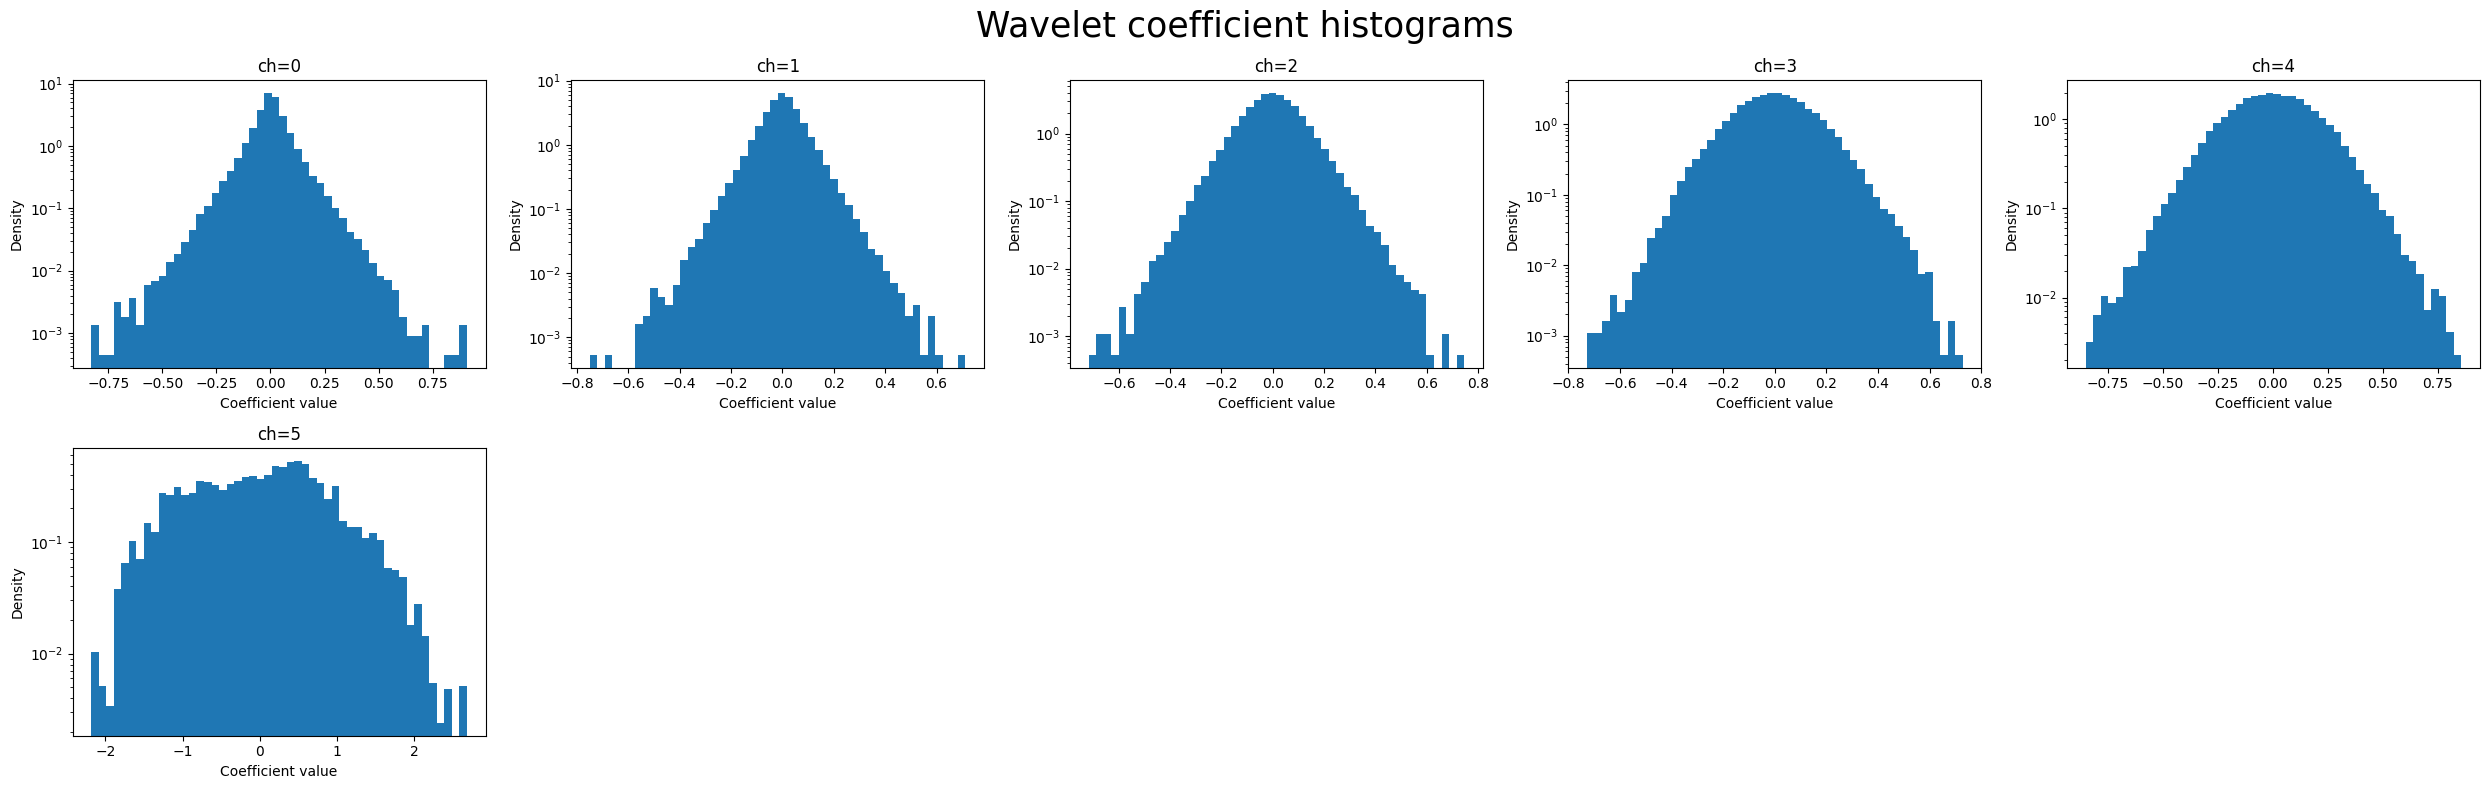

In [79]:
%matplotlib inline 
wt = torch.fft.ifft(torch.fft.fft(x1) * filters).real  # (B, J, T)
print(wt.shape) 
n_wavelets = filters.shape[1]
# ------------------------------------------------------------------
# 1. Overview grid
# ------------------------------------------------------------------
ncols = 5
nrows = math.ceil(n_wavelets / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i in range(n_wavelets):
    vals = wt[:, i, :].detach().cpu().flatten().numpy()
    axes[i].hist(vals, bins=50, density=True, log=True)
    axes[i].set_title(f"ch={i}")
    axes[i].set_xlabel("Coefficient value")
    axes[i].set_ylabel("Density")
for j in range(n_wavelets, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Wavelet coefficient histograms", fontsize=25)
plt.tight_layout()
plt.show()

## Run or load an experiment

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


In [80]:
from pathlib import Path

PARAM_DIR = root.parent / "fixed_potentials"
PARAM_DIR.mkdir(exist_ok=True)

def parameter_path(name):
    return PARAM_DIR / f"{name}.pt"

In [91]:
FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

def aux_path(config):
    print("aux moments path:", root.parent / 'saved_results' / 'aux_moments' / f'{config}_aux_moments.pt') 
    return root.parent / 'saved_results' / 'aux_moments' / f'{config}_aux_moments.pt'


def try_load_experiment(config):
    """Try loading saved SDE outputs and auxiliary moment-matching data."""
    try:
        loaded = load_results(root.parent, config)
        # Fixed: Correctly unpack the 5 values returned by load_results
        xt, theta_t, dH_t_bound, t_loaded, Theta_reg = loaded
        
        out = {
            'xt': xt.to(device) if torch.is_tensor(xt) else xt,
            'theta_t': theta_t,
            'dH_t_bound': dH_t_bound,
            't': t_loaded.to(device) if torch.is_tensor(t_loaded) else t_loaded,
            'Theta_reg': Theta_reg,
            'loaded': True,
        }
        ap = aux_path(config)
        if ap.exists():
            aux = torch.load(ap, map_location=device)
            out.update(aux)
        else:
            out['barphi_e'] = None
            out['barphi_p'] = None
        return out
    except Exception as e:
        print(f'Could not load {config}: {e}')
        return None


def run_experiment(exp, force_rerun=False, lam=1.0, t=None, n_subsample=100):
    config = exp['config']
    terms = exp['terms']

    if not force_rerun:
        loaded = try_load_experiment(config)
        if loaded is not None:
            print(f'Loaded existing results for {config}')
            return loaded

    print(f'Running experiment: {config}')
    print('terms:', terms)

    potentials = get_1d_potentials(
        terms,
        J,
        filters,
        Q,
        filters_Q,
        filters_Phi,
        scalar_param=None,
        parallel=False,
    )

    print("--- Debugging Potentials Structure ---")
    
    # Iterate through the dictionary items
    for key, potential_obj in potentials.items():
        print(f"Checking potential: {key} | Type: {type(potential_obj).__name__}")
        
        # If the object is wrapped in Potential_Parallel or Potential_Prepare,
        # it might have a '.potential' attribute.
        target = potential_obj
        if hasattr(potential_obj, 'potential'):
            target = potential_obj.potential
            print(f"  >> Found wrapper, digging into: {type(target).__name__}")

        # Check if the target (or the original object) has the method
        if hasattr(target, "plot_fit"):
        
            print(f"Loaded {type(target).__name__}")
        
            if hasattr(target, "scale"):      # optional
                target.plot_fit(x1)
            
    #plot potentials fits 
    iterable_pots = potentials.modules() if isinstance(potentials, torch.nn.Module) else potentials

    print(iterable_pots) 
    
    for sub_potential in iterable_pots:
            # Duck typing: if it walks like a duck and quacks like a duck...
            if hasattr(sub_potential, 'plot_fit'):
                pot_name = sub_potential.__class__.__name__
                print(f"\n--- Found plottable potential: {pot_name} ---")
                
                print("Fitting potential to target data...")
                # FIX 2: Corrected typo 'sub_potentials' -> 'sub_potential'
                #sub_potential.fit(x_target) 
                
                print(f"Plotting the fit for {pot_name}...")
                #sub_potential.plot_fit(x_target, label=f"Target Fit: {pot_name}")
                
    print("Starting MGD...")

    Solver = SDE(
        x1,
        nb_workers,
        nb_interpolants,
        t,
        sigma,
        potentials,
        batch_size,
        device=device,
        regularization=regularization,
        interpolant=interpolant,
    )

    xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound, Theta_reg = Solver.forward_regularised(lam=lam,n_subsample=n_subsample) 
    # xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

    # --- save ---
    save_results_theta_reg(
        xt,
        theta_t,
        dH_t_bound,
        t,
        root.parent,
        config,
        Theta_reg=Theta_reg, # Removed the duplicate t=None here
    )

    if SAVE_AUX_MOMENTS:
        torch.save(
            {
                'barphi_e': barphi_e.detach().cpu(),
                'barphi_p': barphi_p.detach().cpu(),
            },
            aux_path(config),
        )

    return {
        'xt': xt,
        'theta_t': theta_t,
        'Theta_reg': Theta_reg,
        't': t,
        'dH_t_bound': dH_t_bound,
        'barphi_e': barphi_e,
        'barphi_p': barphi_p,
        'loaded': False,
    }


## Define and run experiments 

In [82]:
results = {}

n_subsample = 500
lam = 5e-7

experiments = {
    'GaussianK_psi': {
        'label': 'GaussianKregions ψ',
        'suffix': f'_nt{nt}_n1_{x1.shape[0]}_GaussianK_lam_{lam}_Q=3only',
        'terms': [
            #'L_2_lowpass',
            #'Scattering_Fourth_Order_Mod2_Real_Q1',
            'Scalar_psi_gaussianK',
            #'Scalar_morlet_gaussianK',
        ],
    },

}

for key, exp in experiments.items():
    exp['config'] = base_config + exp['suffix']
    print(key, '->', exp['config'])


GaussianK_psi -> turbulence_synthesis_32_J_5_Q_3_sigma_25_nt70000_n1_2000_GaussianK_lam_5e-07_Q=3only


## Fit check 

In [86]:
root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from potentials.potentials_classes.generalized_gauss_Kregions import Scalar_GGD_KRegion

In [87]:
filters = return_Filters(M, J, 1, device=device, include_phi=False)
model1= Scalar_GGD_KRegion(filters)
model1.fit_reference(x1)

    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-136061  K2=-136255)
[GGD^4][ch 0] kurt=   5.92  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0168]  pi=[0.0% 0.0% 25.2% 74.8%]  alpha=[1.00 1.00 2.47 0.73]  active=2
    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-139197  K2=-139346)
[GGD^4][ch 1] kurt=   3.10  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0485]  pi=[0.0% 0.0% 53.1% 46.9%]  alpha=[1.00 1.00 1.66 0.94]  active=2
    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-95550  K2=-95643)
[GGD^4][ch 2] kurt=   1.33  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0744]  pi=[0.0% 0.0% 52.9% 47.1%]  alpha=[1.00 1.00 2.52 1.23]  active=2
    [model-select] chose K=1  (Kmax=1)  (BIC: K1=-60523)
[GGD^4][ch 3] kurt=   0.40  Kmax=1  Keff=1  cuts=[0.0000 0.0000 0.0000]  pi=[0.0% 0.0% 0.0% 100.0%]  alpha=[1.00 1.00 1.00 1.74]  active=1
    [model-select] chose K=1  (Kmax=1)  (BIC: K1=-20146)
[GGD^4][ch 4] kurt=   0.31  Kmax=1  Keff=1  cuts=[0.0000 0.0000 0.0000]  pi=[0.0% 0.0% 0.0% 100.0%]  alpha=[1.00 1.00 1.00

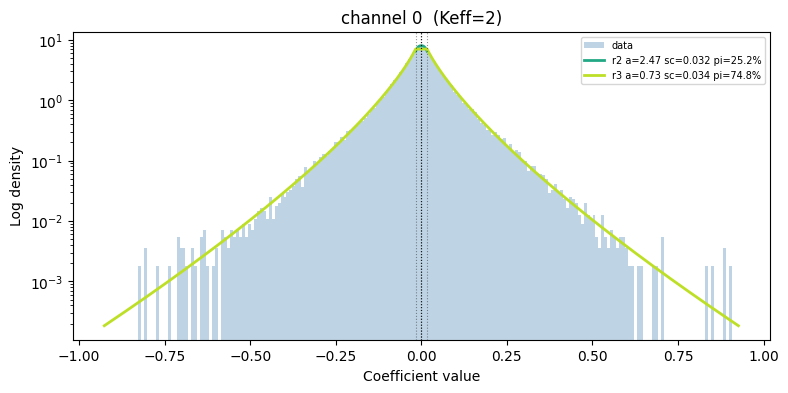

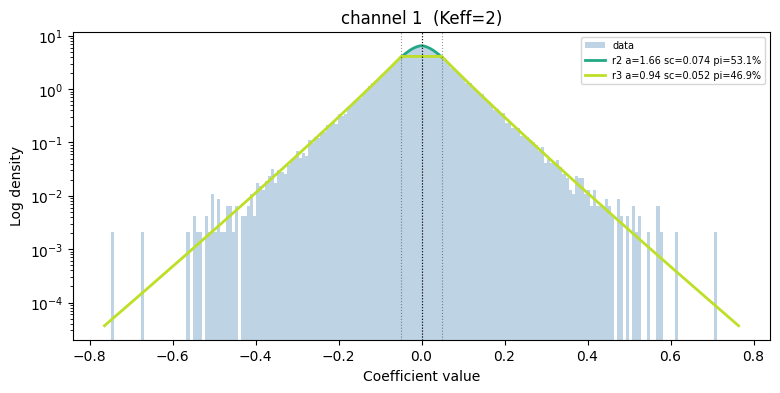

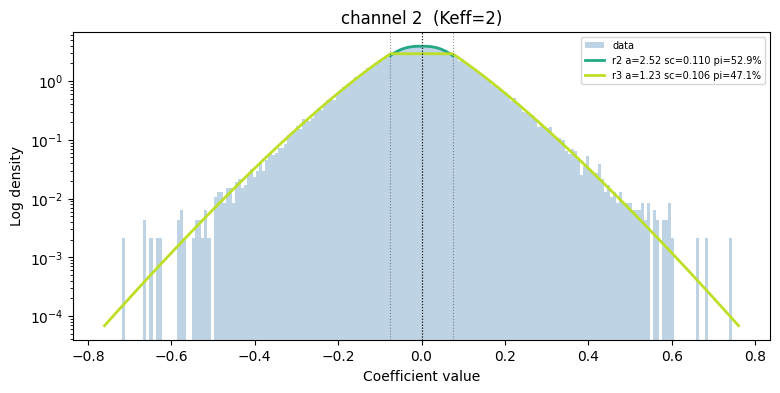

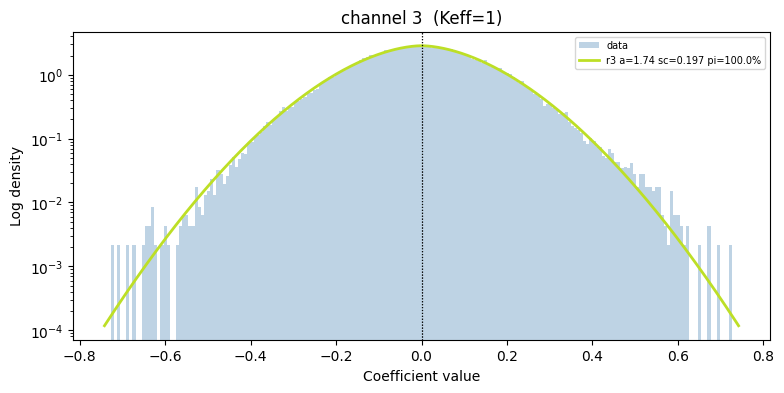

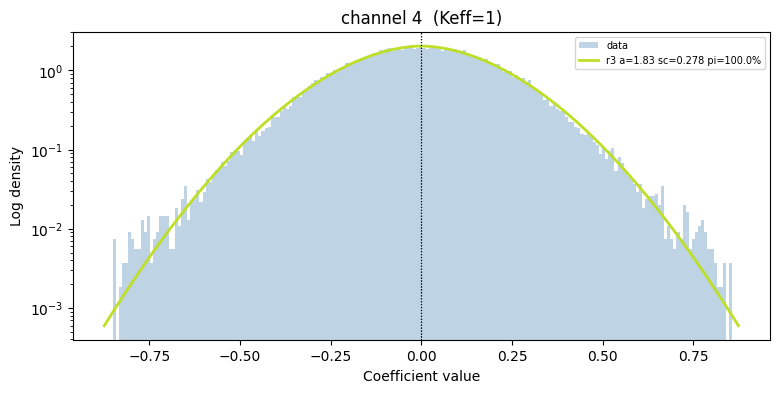

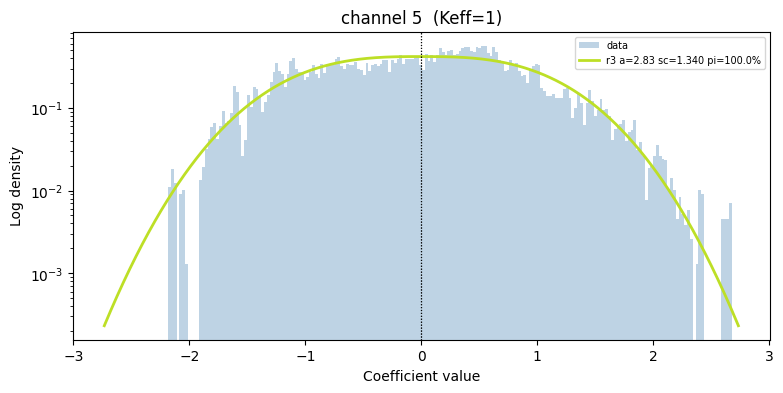

In [88]:
model1.plot_fit(x1)

In [89]:
filtersQ = return_Filters(M, J, 3, device=device, include_phi=False)
model3 = Scalar_GGD_KRegion(filtersQ)
model3.fit_reference(x1)

    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-246557  K2=-246619)
[GGD^4][ch 0] kurt=   6.45  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0265]  pi=[0.0% 0.0% 66.2% 33.8%]  alpha=[1.00 1.00 0.92 0.71]  active=2
    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-267187  K2=-267281)
[GGD^4][ch 1] kurt=   6.10  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0082]  pi=[0.0% 0.0% 32.2% 67.8%]  alpha=[1.00 1.00 2.00 0.78]  active=2
    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-238789  K2=-238887)
[GGD^4][ch 2] kurt=   4.76  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0371]  pi=[0.0% 0.0% 73.3% 26.7%]  alpha=[1.00 1.00 1.38 0.89]  active=2
    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-216355  K2=-216526)
[GGD^4][ch 3] kurt=   2.58  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0376]  pi=[0.0% 0.0% 65.9% 34.1%]  alpha=[1.00 1.00 1.80 0.95]  active=2
    [model-select] chose K=2  (Kmax=2)  (BIC: K1=-197738  K2=-197946)
[GGD^4][ch 4] kurt=   2.01  Kmax=2  Keff=2  cuts=[0.0000 0.0000 0.0630]  pi=[0.0% 0.0% 80.2% 1

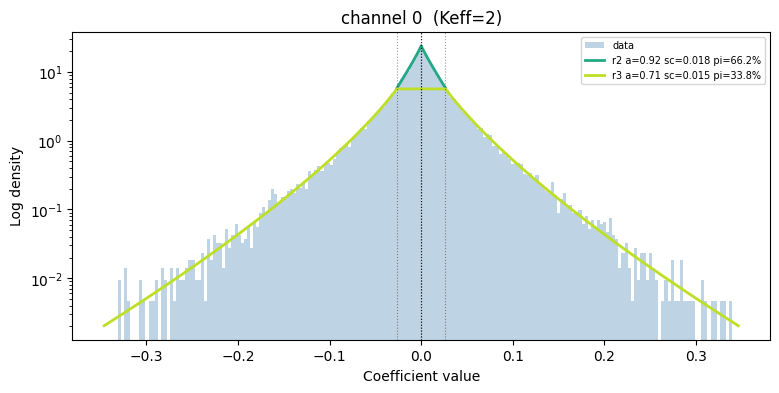

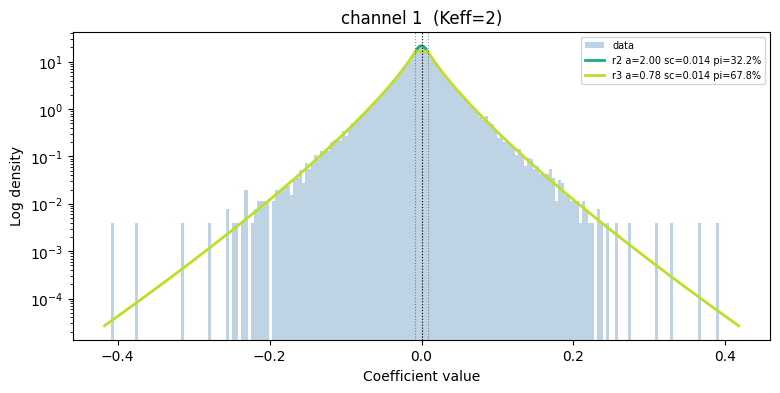

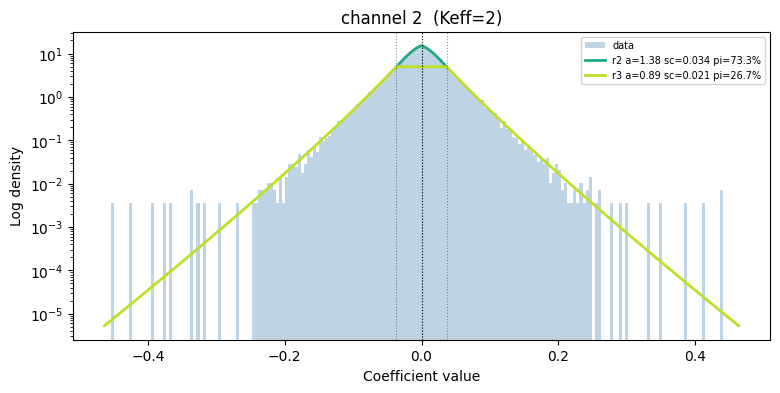

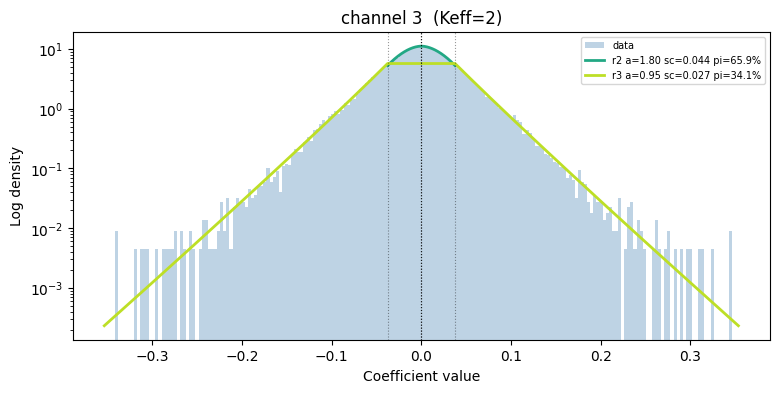

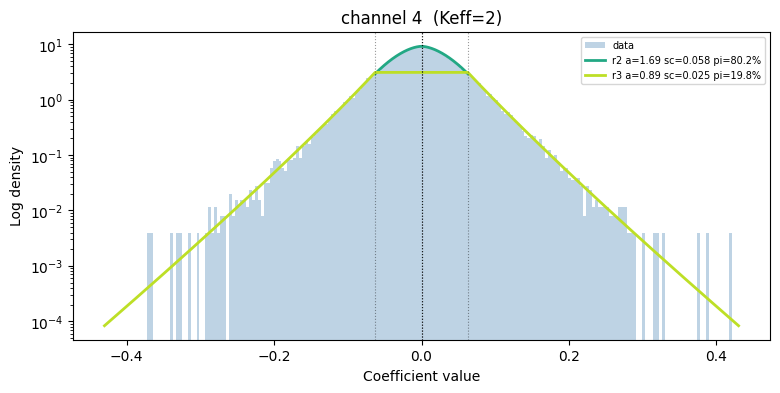

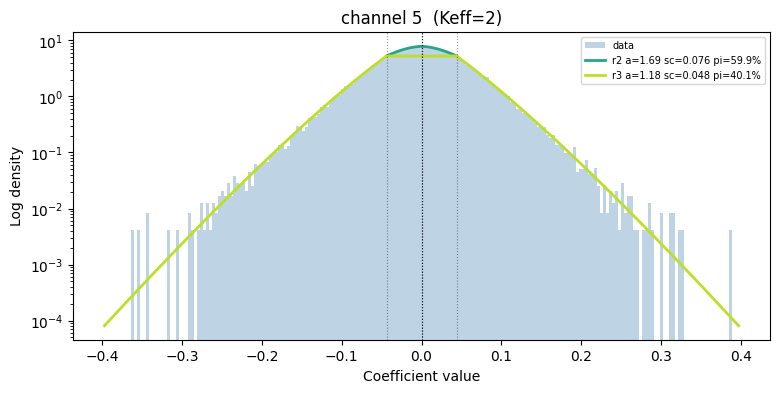

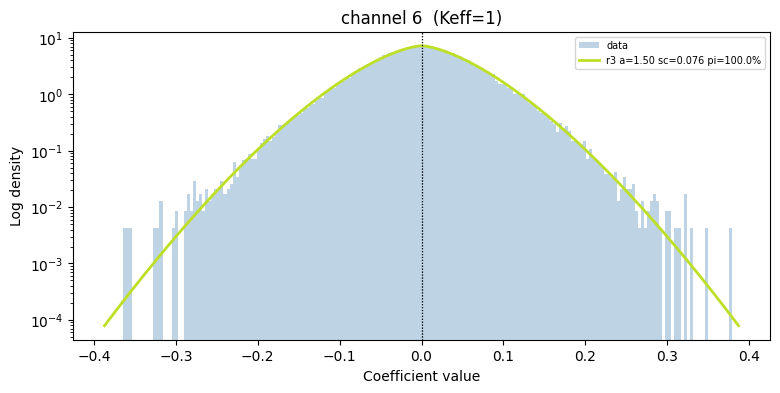

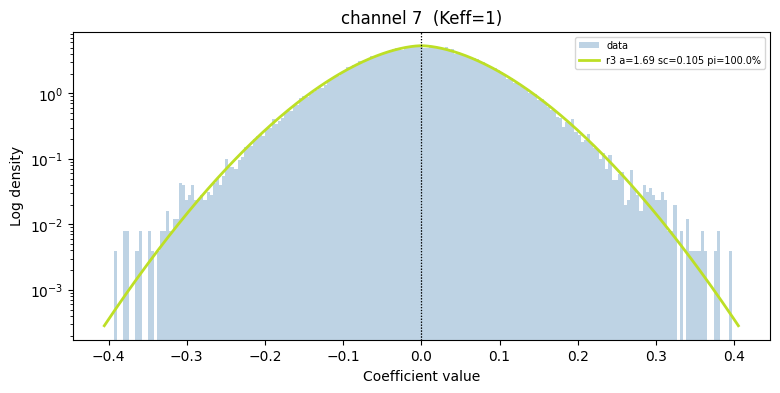

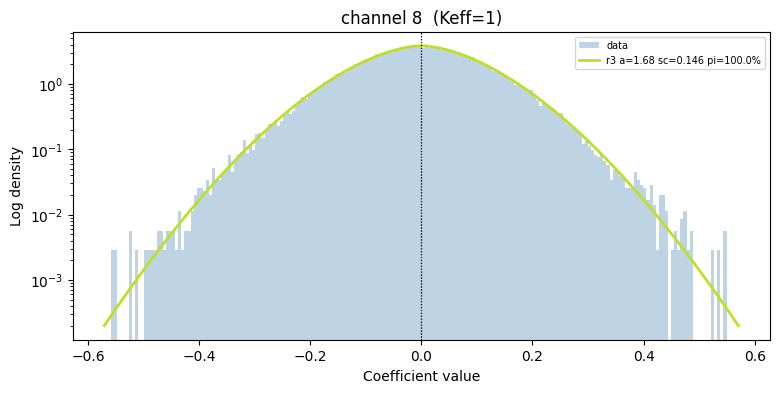

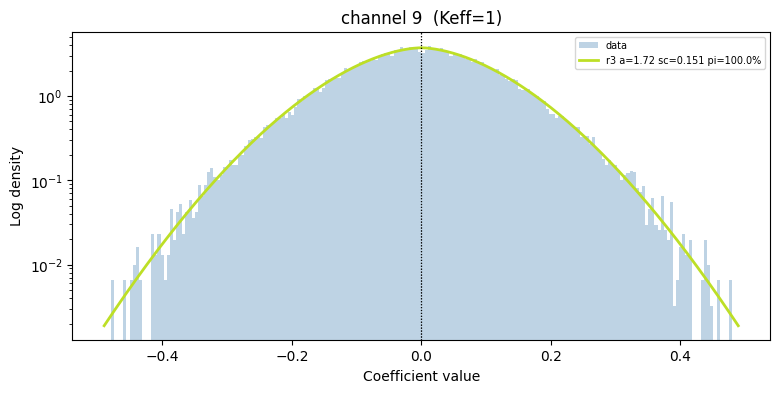

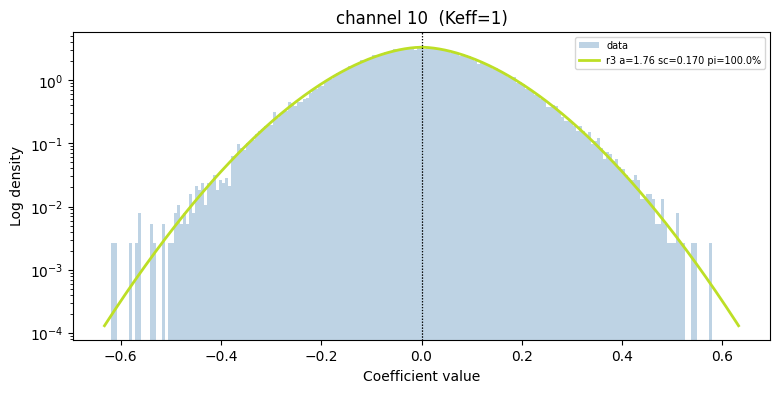

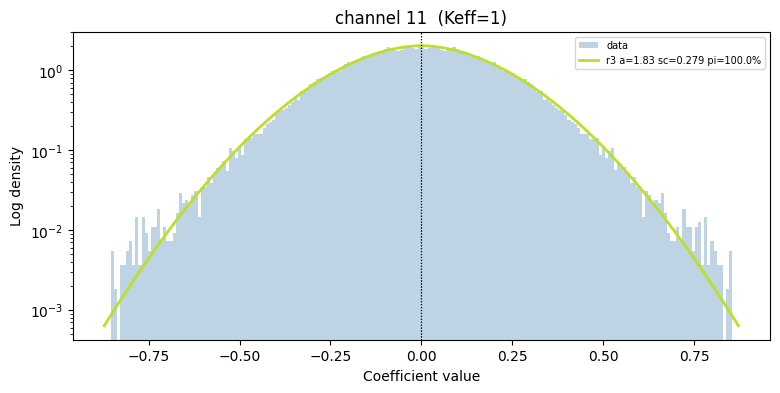

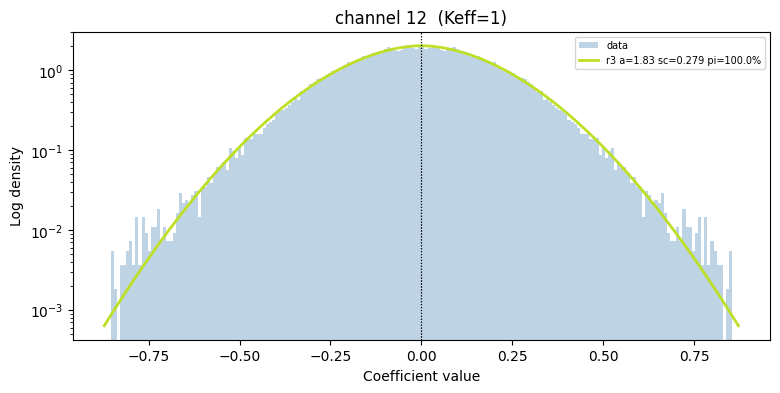

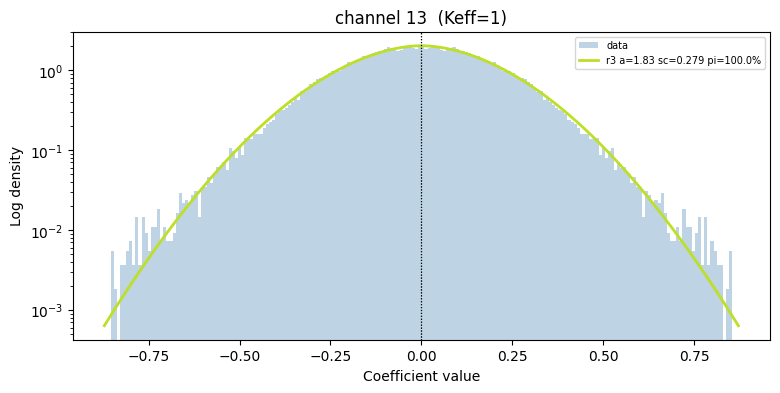

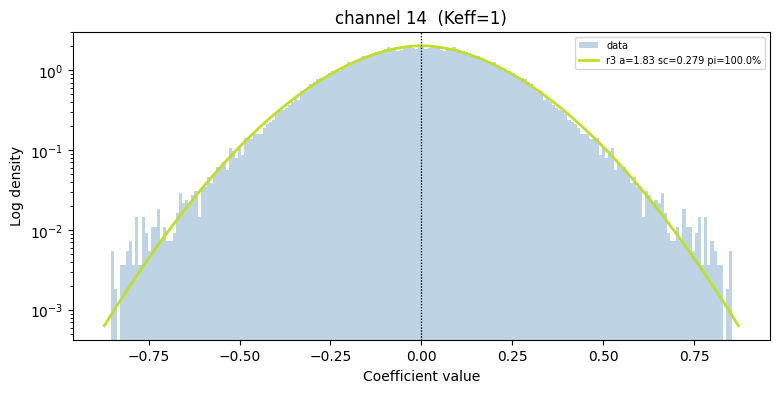

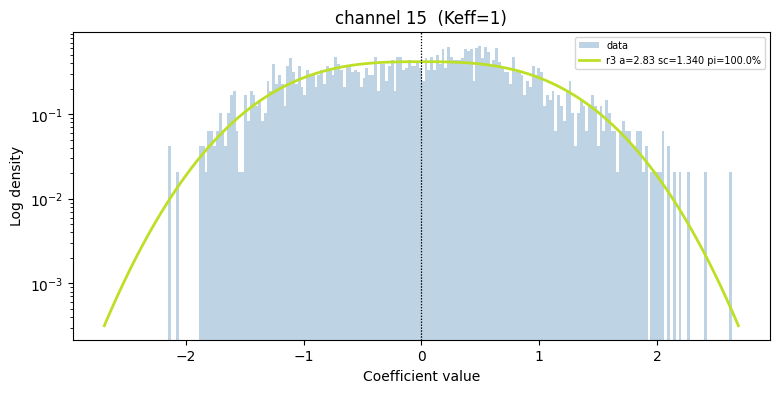

In [90]:
model3.plot_fit(x1)

## Run experiment 

In [83]:
for key, exp in experiments.items():
    #results[key] = run_experiment(exp, force_rerun=FORCE_RERUN, lam=lam, t=t, n_subsample=n_subsample)
    results[key] = run_experiment(exp, force_rerun=False, lam=lam, t=t, n_subsample=n_subsample)
    print('-' * 80)

aux moments path: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/saved_results/aux_moments/turbulence_synthesis_32_J_5_Q_3_sigma_25_nt70000_n1_2000_GaussianK_lam_5e-07_Q=3only_aux_moments.pt
Loaded existing results for turbulence_synthesis_32_J_5_Q_3_sigma_25_nt70000_n1_2000_GaussianK_lam_5e-07_Q=3only
--------------------------------------------------------------------------------


## Analyze results 

In [72]:
for key, exp in experiments.items():
    res = results[key]
    theta_t = res['theta_t']
    print(theta_t.shape, theta_t.device)
    theta_reg_t = res['Theta_reg']

torch.Size([9999, 19]) cuda:0


## Theta scaling analysis 

potential                             dim            cols  source
L_2_lowpass                             1  [   0:1   ]  'num_coefficients' attribute
Scalar_psi_GGG                         66  [   1:67  ]  'num_coefficients' attribute
Scalar_morlet_GGG                      24  [  67:91  ]  'num_coefficients' attribute
Scattering_Fourth_Order_Mod2_Real_Q1    56  [  91:147 ]  'num_coefficients' attribute
OK: 4 potentials account for all 147 theta columns (theta_t.shape[1]=147).
-> Scattering_Fourth_Order_Mod2_Real_Q1: cols [91:147] out of 147
scat_potential.J = 7  scat_potential.Q = 1  num_coefficients = 56
scat_potential.filters.shape = (1, 8, 128)
scat_potential.filters_Q.shape = (1, 7, 128)
Expected #coefficients per j (combinatorial fingerprint): {0: 21, 1: 15, 2: 10, 3: 6, 4: 3, 5: 1}

 row   min   max  n_unique  value_counts
   0     0     5         6  {0: 21, 1: 15, 2: 10, 3: 6, 4: 3, 5: 1}
   1     1     6         6  {1: 6, 2: 10, 3: 12, 4: 12, 5: 10, 6: 6}
   2     2     7     

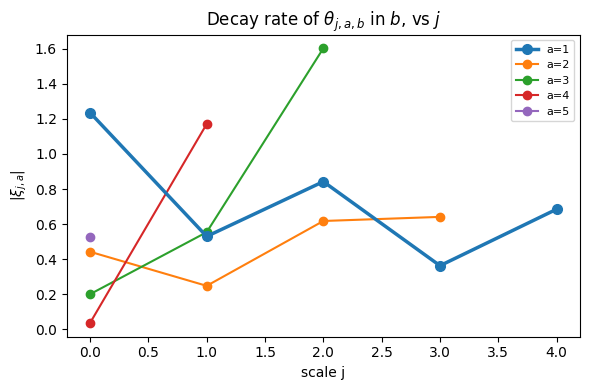

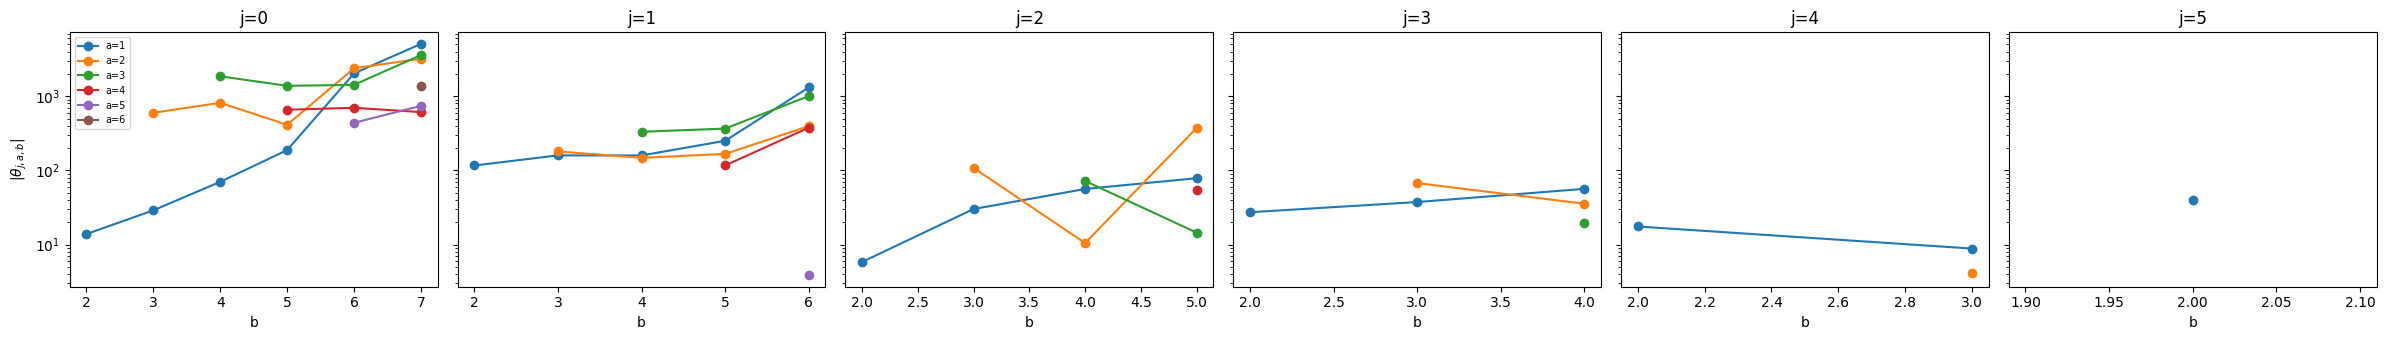

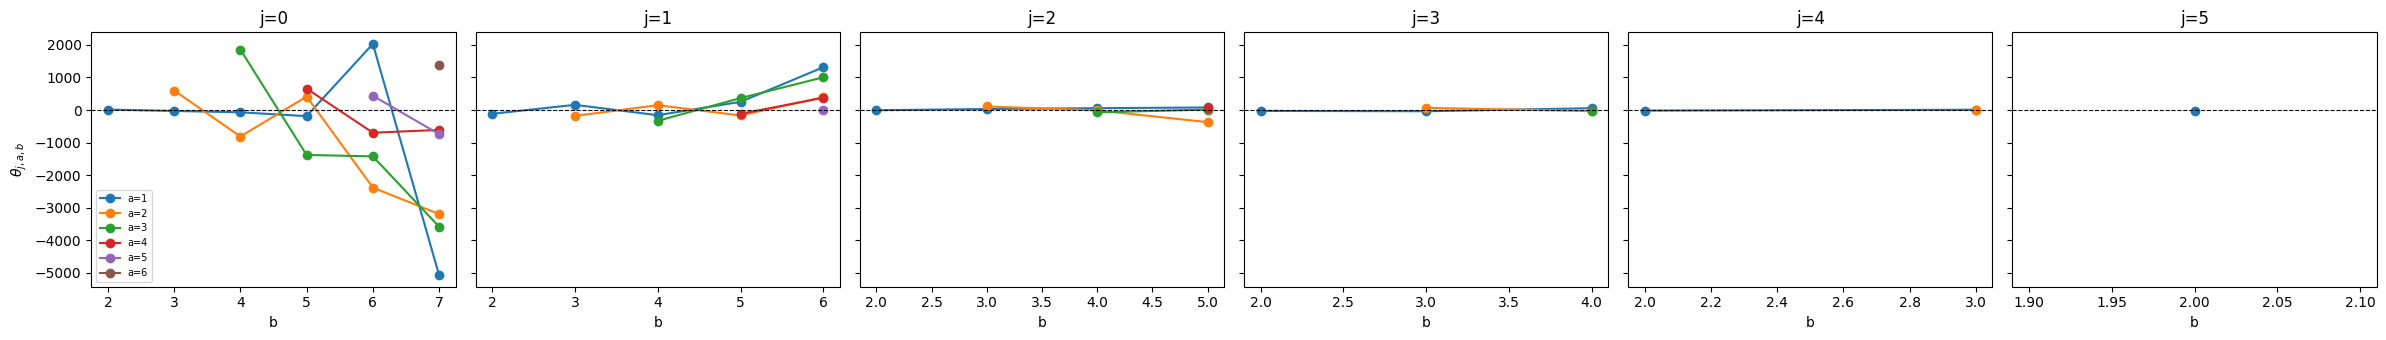

In [12]:
## Scattering theta scaling analysis
 
# ----------------------------------------------------------------------
# Pick the experiment to analyse explicitly instead of relying on the
# "last value of a for-loop" trick (there is currently only one entry
# in `experiments`, but this makes the dependency explicit and avoids
# silently picking the wrong one if a second experiment is added later).
# ----------------------------------------------------------------------
ANALYSIS_KEY = 'coshgt_psi'
exp = experiments[ANALYSIS_KEY]
res = results[ANALYSIS_KEY]
theta_t = res['theta_t']
 
from collections import defaultdict
 
# ----------------------------------------------------------------------
# 0. Locate every potential's columns in theta_t WITHOUT hardcoding
#    position.
#
#    THE BUG: the previous version assumed any potential lacking an
#    `.indices` attribute occupies exactly 1 theta column. That's true
#    for `L_2_lowpass`, but FALSE for the multi-region cosh-Gt scalar
#    potentials: `Scalar_psi_coshgt` (44 columns) and
#    `Scalar_morlet_coshgt` (16 columns) each expand into many theta
#    entries -- one per telescoping-sigmoid bulk/tail region -- despite
#    being "Scalar_*" potentials. That silent "assume 1" fallback is
#    exactly why sum(dims) came out as 59 (1 + 56 + 1 + 1) instead of
#    the true 117 (1 + 56 + 44 + 16).
#
#    FIX: try to introspect the true width first (in decreasing order
#    of reliability), and only fall back to an explicit, independently
#    verified override table -- never to a silent "assume 1".
# ----------------------------------------------------------------------
terms = exp['terms']
potentials = get_1d_potentials(
    terms, J, filters, Q, filters_Q, filters_Phi,
    scalar_param=None, parallel=False,
)
 
TARGET_KEY = 'Scattering_Fourth_Order_Mod2_Real_Q1'
 
# Independently verified column counts (see comments next to `terms` in
# the experiment dict above). Used only when a potential does not
# expose enough introspection to determine its own width -- this is
# currently the case for the multi-region scalar cosh-Gt potentials.
# If you add a new term, count its true theta width (e.g. from the
# potential's own construction code, or empirically -- see note below)
# and add it here rather than letting n_theta() guess.
KNOWN_POTENTIAL_DIMS = {
    'L_2_lowpass': 1,
    'Scattering_Fourth_Order_Mod2_Real_Q1': 84,
    'Scalar_psi_coshgt': 50,
    'Scalar_morlet_coshgt': 18,
}
 
def n_theta(p, key, known_dims=KNOWN_POTENTIAL_DIMS):
    """
    Return (dim, source) for potential `p`, trying progressively less
    direct ways of finding its true theta-block width. Never silently
    assumes dim=1.
    """
    # 1. An explicit width attribute/method, if the class defines one.
    for attr in ('n_theta', 'num_theta', 'theta_dim'):
        if hasattr(p, attr):
            val = getattr(p, attr)
            val = val() if callable(val) else val
            if torch.is_tensor(val):
                val = val.numel()
            return int(val), f"'{attr}' attribute"
 
    # 2. Scattering-style potentials set this at construction time:
    #    self.num_coefficients = len(self.indices[0]).
    if hasattr(p, 'num_coefficients'):
        return int(p.num_coefficients), "'num_coefficients' attribute"
 
    # 3. Any potential storing an (..., N) index tensor.
    if hasattr(p, 'indices'):
        idx = p.indices
        width = idx.shape[-1] if torch.is_tensor(idx) else np.asarray(idx).shape[-1]
        return int(width), "'.indices.shape[-1]'"
 
    # 4. Multi-region scalar potentials: if the class exposes its
    #    region count directly, prefer that over the hardcoded table.
    for attr in ('num_regions', 'n_regions'):
        if hasattr(p, attr):
            n_regions = int(getattr(p, attr))
            params_per_region = int(getattr(p, 'n_params_per_region', 1))
            return n_regions * params_per_region, f"'{attr}' x n_params_per_region"
 
    # 5. Last resort: an explicit, independently-verified override.
    if key in known_dims:
        return int(known_dims[key]), "KNOWN_POTENTIAL_DIMS override (UNVERIFIED by introspection -- fix the class if possible)"
 
    raise RuntimeError(
        f"Cannot determine theta width for potential '{key}' "
        f"({type(p).__name__}): no n_theta/num_theta/theta_dim/"
        "num_coefficients/.indices/num_regions attribute, and no entry "
        "in KNOWN_POTENTIAL_DIMS. Add one rather than guessing."
    )
 
keys = list(potentials.keys())
dims, sources = [], []
for k in keys:
    d, src = n_theta(potentials[k], k)
    dims.append(d)
    sources.append(src)
    # Cross-check: if introspection succeeded via a real attribute AND
    # we also have an independent KNOWN_POTENTIAL_DIMS entry, they must
    # agree -- a mismatch means one of the two is stale.
    if k in KNOWN_POTENTIAL_DIMS and 'override' not in src and d != KNOWN_POTENTIAL_DIMS[k]:
        print(f"WARNING: introspected dim for {k} ({d}) != "
              f"KNOWN_POTENTIAL_DIMS[{k}] ({KNOWN_POTENTIAL_DIMS[k]}) "
              "-- one of them is out of date, please reconcile.")
 
offsets = np.cumsum([0] + dims)
print(f"{'potential':35s} {'dim':>5s}  {'cols':>14s}  source")
for k, d, o, src in zip(keys, dims, offsets[:-1], sources):
    print(f"{k:35s} {d:5d}  [{o:4d}:{o+d:<4d}]  {src}")
 
assert sum(dims) == theta_t.shape[1], (
    f"sum(dims)={sum(dims)} != theta_t.shape[1]={theta_t.shape[1]} -- "
    "dict order != column order, or a dim above is still wrong "
    "(check the per-potential 'source' column printed above)."
)
print(f"OK: {len(keys)} potentials account for all {sum(dims)} theta "
      f"columns (theta_t.shape[1]={theta_t.shape[1]}).")
 
def get_theta_columns(key, keys=keys, offsets=offsets, dims=dims, theta_t=theta_t):
    """Slice out the theta_t columns belonging to potential `key`."""
    i = keys.index(key)
    start, dim = int(offsets[i]), dims[i]
    block = theta_t[:, start:start + dim]
    block = block.cpu().numpy() if torch.is_tensor(block) else block
    return block, start, dim
 
theta_scat_raw, scat_start, scat_dim = get_theta_columns(TARGET_KEY)
scat_potential = potentials[TARGET_KEY]
assert scat_dim == scat_potential.num_coefficients == scat_potential.indices.shape[-1]
print(f"-> {TARGET_KEY}: cols [{scat_start}:{scat_start+scat_dim}] "
      f"out of {theta_t.shape[1]}")
 
# The two multi-region scalar potentials are now also correctly
# located, in case you want to extend the analysis to them later, e.g.:
#   theta_psi_coshgt, _, _    = get_theta_columns('Scalar_psi_coshgt')     # 44 cols
#   theta_morlet_coshgt, _, _ = get_theta_columns('Scalar_morlet_coshgt')  # 16 cols
 
# ----------------------------------------------------------------------
# 1. Decode (j, a, b) from potential.indices.
#
#    Tracing Scattering_Fourth_Order_Real_1d.forward() to find out what
#    indices[0], indices[1], indices[2] actually index into:
#
#      x_filtered      = ifft(filters_Q * fft(x))           # (B, JQ, T)
#      x_filtered_abs   -> envelope                          # (B, JQ, T)
#      W_Wx            = ifft(filters[:,:,None] * fft(x_filtered_abs)[:,None])
#                                                             # (B, JQ, J+1, T)
#      output = real(W_Wx[:,:,:,None] * W_Wx[:,:,None].conj())
#                                                             # (B, JQ, J+1_a, J+1_b, T)
#      output = output.mean(-1)                              # (B, JQ, J+1_a, J+1_b)
#      output = output.permute(0, 3, 2, 1)                   # (B, J+1_b, J+1_a, JQ)
#      output = output[:, indices[0], indices[1], indices[2]]
#
#    The JQ axis (the *first-layer* scale j) is never broadcast against
#    itself -- W_Wx[:, :, :, None] and W_Wx[:, :, None] both keep their
#    JQ axis (axis 1) aligned, only the J+1 axis gets broadcast into a
#    J+1 x J+1 grid. So there is exactly ONE first-layer scale j per
#    coefficient, and TWO second-layer *absolute* scales (call them
#    s1, s2, both in [0, J]) being cross-multiplied.
#
#    After the permute, axis order is (B, J+1_b, J+1_a, JQ), so:
#       indices[0] -> s2  (absolute scale, range [0, J])
#       indices[1] -> s1  (absolute scale, range [0, J])
#       indices[2] -> j   (first-layer scale, range [0, JQ-1])
#    i.e. indices[2] is j, NOT indices[0] -- the previous version of
#    this function had that backwards (it set j = indices[0], which is
#    actually one of the two absolute scales, not the shared first-layer
#    scale). Because real(A*conj(B)) == real(B*conj(A)), the coefficient
#    VALUE doesn't care which of indices[0]/indices[1] is "s1" vs "s2";
#    it only matters for how *we* choose to label a vs b below.
#
#    Rather than asserting one specific row assignment (which just
#    failed at runtime -- so the shape trace above doesn't match this
#    build, most likely because `filters`/`filters_Q` don't have the
#    channel counts I assumed), determine the row assignment EMPIRICALLY
#    below, then decode using whatever it finds.
# ----------------------------------------------------------------------
import math
 
def decode_jab(potential, j_row):
    """j_row = which row of potential.indices (0, 1, or 2) is the
    shared first-layer scale j. The other two rows are the absolute
    second-layer scales; we sort them ourselves into (a < b)."""
    idx = potential.indices.long()
    other_rows = [r for r in range(3) if r != j_row]
    j = idx[j_row]
    s1, s2 = idx[other_rows[0]], idx[other_rows[1]]
    lo = torch.minimum(s1, s2)
    hi = torch.maximum(s1, s2)
    a, b = lo - j, hi - j
    return j.numpy(), a.numpy(), b.numpy(), lo.numpy(), hi.numpy()
 
# ----------------------------------------------------------------------
# 1a. Figure out which row is j -- empirically, with no filter-shape
#     assumptions at all.
#
#     Ground truth available to us: for offset=1 (a>=1) + lite (only
#     one symmetric ordering kept) + no-diag, the number of (a,b) pairs
#     at a given j is C(J-j, 2) -- this is exactly Gemini's confirmed
#     21,15,10,6,3,1,0 breakdown for J=7, summing to 56. This is a pure
#     combinatorial fingerprint: whichever row's value_counts matches
#     {0:21, 1:15, 2:10, 3:6, 4:3, 5:1} (j=6 contributes 0 and so never
#     appears) is unambiguously the j row, independent of any tensor
#     shape we might have guessed wrong.
# ----------------------------------------------------------------------
Jp = scat_potential.J
print("scat_potential.J =", Jp, " scat_potential.Q =", scat_potential.Q,
      " num_coefficients =", scat_potential.num_coefficients)
 
# Ground-truth shapes of the actual filter banks this potential uses --
# print these directly instead of assuming (J+1, T) / (JQ, T).
for attr in ('filters', 'filters_Q'):
    t = getattr(scat_potential, attr, None)
    if t is not None:
        print(f"scat_potential.{attr}.shape = {tuple(t.shape)}")
    else:
        print(f"scat_potential.{attr} not found")
 
expected_counts = {j: math.comb(Jp - j, 2) for j in range(Jp)}
expected_counts = {j: c for j, c in expected_counts.items() if c > 0}
print("Expected #coefficients per j (combinatorial fingerprint):", expected_counts)
 
idx_all = scat_potential.indices.long()
print(f"\n{'row':>4} {'min':>5} {'max':>5} {'n_unique':>9}  value_counts")
row_value_counts = []
for r in range(3):
    vals = idx_all[r].numpy()
    uniq, counts = np.unique(vals, return_counts=True)
    vc = dict(zip(uniq.tolist(), counts.tolist()))
    row_value_counts.append(vc)
    print(f"{r:>4} {int(vals.min()):>5} {int(vals.max()):>5} {len(uniq):>9}  {vc}")
 
j_row = next((r for r in range(3) if row_value_counts[r] == expected_counts), None)
 
if j_row is None:
    # No exact match -- fall back to "closest" by total absolute count
    # difference, but DON'T silently proceed with a guess; surface
    # everything needed to diagnose by hand.
    def mismatch(vc):
        keys = set(vc) | set(expected_counts)
        return sum(abs(vc.get(k, 0) - expected_counts.get(k, 0)) for k in keys)
    scores = [mismatch(vc) for vc in row_value_counts]
    best = int(np.argmin(scores))
    print(f"\nNO row matches the expected fingerprint exactly. "
          f"Mismatch scores per row: {scores} (lower is closer).")
    print(f"Best guess: row {best}, but please inspect the printed "
          f"value_counts above by hand before trusting this -- e.g. paste "
          f"them back for a second look, or check indices_fourth_order_Q's "
          f"source directly.")
    j_row = best
else:
    print(f"\n-> row {j_row} matches the combinatorial fingerprint for j exactly.")
 
j_arr, a_arr, b_arr, s1_arr, s2_arr = decode_jab(scat_potential, j_row)
print("j:", j_arr.min(), j_arr.max(), " a:", a_arr.min(), a_arr.max(), " b:", b_arr.min(), b_arr.max())
if not ((a_arr >= 1).all() and (b_arr > a_arr).all()):
    n_bad_a = int((a_arr < 1).sum())
    n_bad_b = int((b_arr <= a_arr).sum())
    print(f"WARNING: offset/lite assumptions still violated even with the "
          f"detected j_row={j_row}: {n_bad_a} entries have a<1, "
          f"{n_bad_b} entries have b<=a. Inspect row_value_counts above -- "
          f"the fingerprint match may have been coincidental, or "
          f"indices_fourth_order_Q's (a,b) convention differs from what's "
          f"assumed here (e.g. it may not always order j+a < j+b).")
 
 
# ----------------------------------------------------------------------
# 1b. Energy-conserving de-normalization.
#
#    theta is fitted against phi(x) as actually computed by forward(),
#    which (via fit_micro's self.norm) rescales each first-layer envelope
#    by E[|x_filtered_j|^2]^{1/4} before the second-layer filtering -- a
#    micro-normalization keyed on the *first-layer* scale j, not the
#    cross-scale normalization you want here. scat_potential.norm_indices
#    being trivially 1.0 just reflects that this micro-norm was never
#    fit (or fit_micro wasn't invoked) for this potential -- it is NOT
#    the (E(x_j^2) E(x_{j+a}^2))^{1/2}-style normalization below, so we
#    compute that one ourselves instead of relying on it.
#
#    To keep theta^T phi(x) (the "energy"/log-density contribution)
#    invariant under a rescaling of phi, a coefficient that is itself
#    divided by norm_jab inside the model must have its fitted theta
#    MULTIPLIED by the same norm_jab to recover the physically
#    comparable value: theta_physical = theta_fitted * norm_jab.
#
#    norm_jab for coefficient (j,a,b) is sqrt(E[Wx_s1^2] * E[Wx_s2^2]),
#    where s1=j+a, s2=j+b are the two ABSOLUTE second-layer scales
#    (indices[0], indices[1] above) and Wx_s denotes the single-layer
#    wavelet transform of the data at absolute scale s -- computed here
#    with the same J+1-channel filter bank (`filters`) this potential
#    uses for its own second-layer filtering, applied directly to x1
#    rather than to the envelope.
# ----------------------------------------------------------------------
with torch.no_grad():
    Wx_full = torch.fft.ifft(filters * torch.fft.fft(x1))       # (B, J+1, T)
    E_scale = (Wx_full.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()  # (J+1,)
 
print("E[|Wx_s|^2] per absolute scale s=0..J:", E_scale)
 
norm_jab = np.sqrt(E_scale[s1_arr] * E_scale[s2_arr])  # (scat_dim,), one per (j,a,b) coefficient
print("norm_jab range:", norm_jab.min(), norm_jab.max())
 
# ----------------------------------------------------------------------
# 2. Finite-value diagnostics -- check ~isfinite, NOT ~isnan (your Infs
#    were invisible to isnan, which is what silently poisoned nanmean).
# ----------------------------------------------------------------------
finite_mask = np.isfinite(theta_scat_raw)              # (T, scat_dim)
bad_rows = np.where((~finite_mask).any(axis=1))[0]
print("non-finite count per column:", (~finite_mask).sum(0))
print("rows with >=1 non-finite entry:", bad_rows)
 
# ----------------------------------------------------------------------
# 3. Burn-in + drop any (post-burn-in) row containing a non-finite entry,
#    THEN de-normalise. Dropping rows (not nanmean) avoids Inf leaking
#    into the mean/std for every column.
# ----------------------------------------------------------------------
BURNIN = 5000
 
keep = np.ones(theta_scat_raw.shape[0], dtype=bool)
keep[:BURNIN] = False
keep[bad_rows] = False
print(f"dropping {(~keep).sum()} rows ({BURNIN} burn-in + "
      f"{np.sum(bad_rows >= BURNIN)} non-finite past burn-in)")
 
theta_scat = theta_scat_raw[keep] * norm_jab[None, :]   # (n_valid, scat_dim)
theta_mean = theta_scat.mean(axis=0)                         # plain mean: no NaN/Inf left
theta_std  = theta_scat.std(axis=0)
print("n_valid:", keep.sum(), " any non-finite in theta_mean:", (~np.isfinite(theta_mean)).any())
 
# ----------------------------------------------------------------------
# 4. Low-variance check (slide bullet 1)
# ----------------------------------------------------------------------
cv = theta_std / (np.abs(theta_mean) + 1e-12)
reliable = cv < 0.2
print(f"median |CV| = {np.median(cv):.3f}  "
      f"({np.sum(reliable)}/{len(cv)} coeffs pass <20% noise cut)")
 
# ----------------------------------------------------------------------
# 5. (j,a,b) -> value table, grouped by (j,a) across b
# ----------------------------------------------------------------------
table  = {(int(j), int(a), int(b)): m
          for j, a, b, m in zip(j_arr, a_arr, b_arr, theta_mean)}
groups = defaultdict(list)
for (j, a, b), v in table.items():
    if not np.isfinite(v):
        continue
    groups[(j, a)].append((b, abs(v)))
 
# ----------------------------------------------------------------------
# 6. Fit theta_{j,a,b} ~ exp(-xi_{j,a} * b) per (j,a)
# ----------------------------------------------------------------------
xi = {}
for (j, a), pts in groups.items():
    pts = sorted(pts)
    bs   = np.array([p[0] for p in pts])
    vals = np.array([p[1] for p in pts])
    mask = (vals > 0) & np.isfinite(vals)
    if mask.sum() < 2:
        continue
    slope, _ = np.polyfit(bs[mask], np.log(vals[mask]), 1)
    xi[(j, a)] = -slope
 
print(f"xi entries fitted: {len(xi)} / {len(groups)} (j,a) groups")
 
# ----------------------------------------------------------------------
# 7. Plot xi_{j,a} vs j (Fig. 6)
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))
for a in sorted({a for (_, a) in xi}):
    js  = sorted(j for (j, aa) in xi if aa == a)
    xis = [xi[(j, a)] for j in js]
    kw = dict(marker='o', label=f'a={a}')
    if a == 1:
        kw.update(linewidth=2.5, markersize=7, zorder=10)
    plt.plot(js, np.abs(xis), **kw)
plt.xlabel('scale j'); plt.ylabel(r'$|\xi_{j,a}|$')
plt.title(r'Decay rate of $\theta_{j,a,b}$ in $b$, vs $j$')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
 
# ----------------------------------------------------------------------
# 8. Sanity overlay: raw theta_{j,a,b} vs b for each j (semilog)
# ----------------------------------------------------------------------
js_unique = sorted(set(j_arr))
fig, axes = plt.subplots(1, len(js_unique), figsize=(4 * len(js_unique), 3.5),
                          sharey=True, squeeze=False)
for ax, j in zip(axes[0], js_unique):
    for a in sorted(a for (jj, a) in groups if jj == j):
        pts = sorted(groups[(j, a)])
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], 'o-', label=f'a={a}')
    ax.set_title(f'j={j}'); ax.set_xlabel('b')
axes[0, 0].set_ylabel(r'$|\theta_{j,a,b}|$')
axes[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------
# rawer plot 
groups_signed = defaultdict(list)
for (j, a, b), v in table.items():
    if not np.isfinite(v):
        continue
    groups_signed[(j, a)].append((b, v))

js_unique = sorted(set(j_arr))

fig, axes = plt.subplots(
    1, len(js_unique),
    figsize=(4 * len(js_unique), 3.5),
    sharey=True,
    squeeze=False
)

for ax, j in zip(axes[0], js_unique):
    for a in sorted(a for (jj, a) in groups_signed if jj == j):
        pts = sorted(groups_signed[(j, a)])
        bs = [p[0] for p in pts]
        vals = [p[1] for p in pts]

        ax.plot(bs, vals, 'o-', label=f'a={a}')

    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.set_title(f'j={j}')
    ax.set_xlabel('b')

axes[0,0].set_ylabel(r'$\theta_{j,a,b}$')
axes[0,0].legend(fontsize=7)

plt.tight_layout()
plt.show()


a=[1], v vals=[np.float32(6449.58)]
a=[1], v vals=[np.float32(-18050.502)]
a=[1], v vals=[np.float32(-391.70898)]
a=[1], v vals=[np.float32(-967.84906)]
a=[1], v vals=[np.float32(-344.51236)]
a=[1], v vals=[np.float32(-173.35744)]


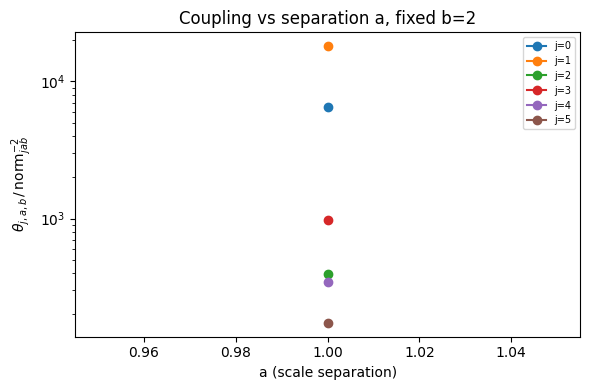

a=[1, 2], v vals=[np.float32(-8312.464), np.float32(92830.6)]
a=[1, 2], v vals=[np.float32(17316.123), np.float32(-12085.425)]
a=[1, 2], v vals=[np.float32(1524.4734), np.float32(3831.712)]
a=[1, 2], v vals=[np.float32(-976.8729), np.float32(1325.0515)]
a=[1, 2], v vals=[np.float32(52.43866), np.float32(18.114418)]


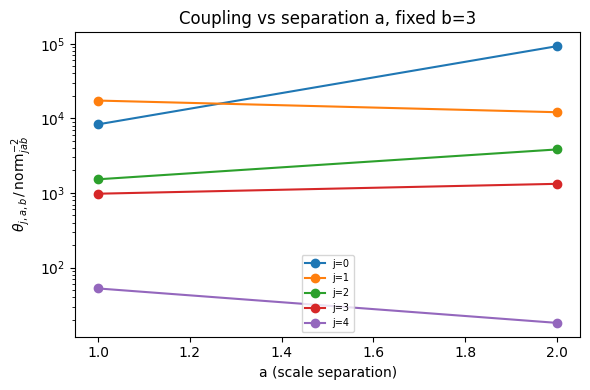

a=[1, 2, 3], v vals=[np.float32(-14126.673), np.float32(-88470.78), np.float32(124586.64)]
a=[1, 2, 3], v vals=[np.float32(-13015.302), np.float32(7463.868), np.float32(-11760.7295)]
a=[1, 2, 3], v vals=[np.float32(2091.1587), np.float32(-273.7896), np.float32(-1414.1707)]
a=[1, 2, 3], v vals=[np.float32(444.59027), np.float32(-210.7322), np.float32(-84.34613)]


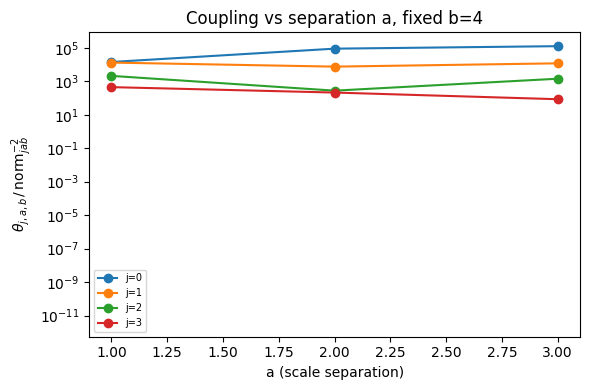

a=[1, 2, 3, 4], v vals=[np.float32(-28486.146), np.float32(33787.555), np.float32(-69785.43), np.float32(23312.777)]
a=[1, 2, 3, 4], v vals=[np.float32(15092.16), np.float32(-6206.3696), np.float32(9552.758), np.float32(-2291.8542)]
a=[1, 2, 3, 4], v vals=[np.float32(882.0086), np.float32(-2929.704), np.float32(86.0437), np.float32(239.35332)]


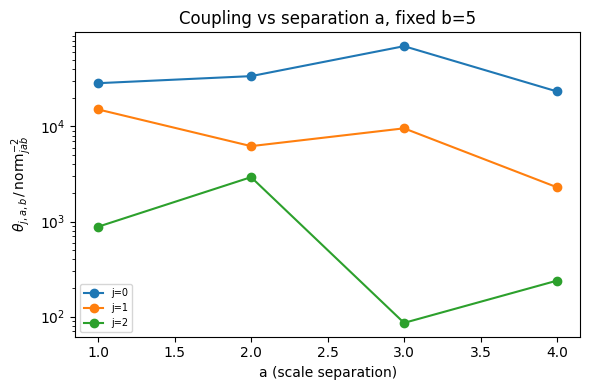

a=[1, 2, 3, 4, 5], v vals=[np.float32(226429.31), np.float32(-143558.34), np.float32(-52963.406), np.float32(-18200.098), np.float32(8599.5)]
a=[1, 2, 3, 4, 5], v vals=[np.float32(23892.705), np.float32(4440.6772), np.float32(7914.3804), np.float32(2230.6636), np.float32(-16.896944)]


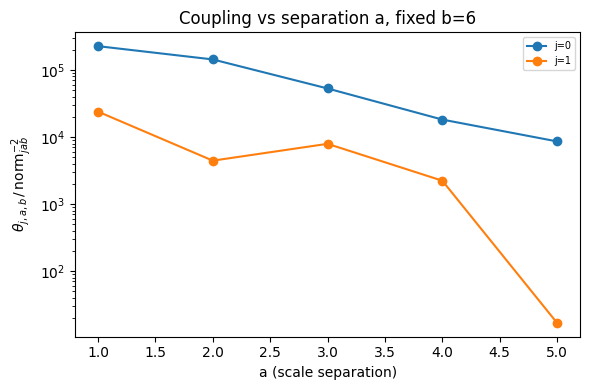

a=[1, 2, 3, 4, 5, 6], v vals=[np.float32(-170771.98), np.float32(-58158.746), np.float32(-40268.195), np.float32(-4814.0435), np.float32(-4397.717), np.float32(6009.644)]


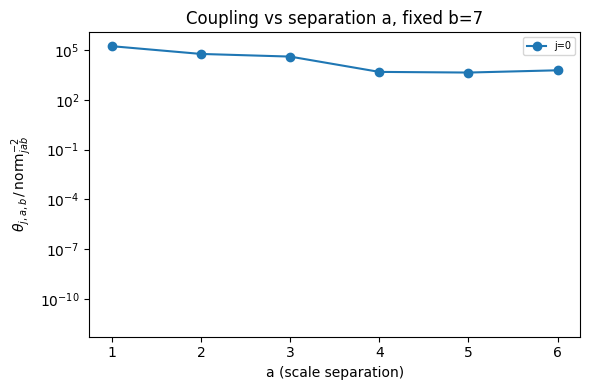

In [42]:
# ----------------------------------------------------------------------
# Fixed-b scaling: for each b, x-axis = a (scale separation), one line
# per j. Potential is order 4 (~|x|^4), so normalize raw theta by
# norm_jab**2, not norm_jab (that's the order-2 bound used in section 1b).
# ----------------------------------------------------------------------
theta_raw_mean = theta_scat_raw[keep].mean(axis=0)          # (scat_dim,), pre-normalization units
theta_o4 = theta_raw_mean #* norm_jab**2                      # order-4 normalized

table_o4 = {(int(j), int(a), int(b)): v
            for j, a, b, v in zip(j_arr, a_arr, b_arr, theta_o4)}

groups_by_b = defaultdict(list)   # key: b -> [(a, j, theta)]
for (j, a, b), v in table_o4.items():
    if np.isfinite(v):
        groups_by_b[b].append((a, j, v))

for b in sorted(groups_by_b):
    pts_by_j = defaultdict(list)
    for a, j, v in groups_by_b[b]:
        pts_by_j[j].append((a, v))

    plt.figure(figsize=(6, 4))
    for j in sorted(pts_by_j):
        pts = sorted(pts_by_j[j])
        a_vals = [p[0] for p in pts]
        v_vals = [p[1] for p in pts]
        plt.plot(a_vals, np.abs(v_vals), 'o-', label=f'j={j}')
        print(f"a={a_vals}, v vals={v_vals}")
    plt.axhline(0, color='k', ls='--', lw=0.8)
    plt.yscale("log") 
    plt.xlabel('a (scale separation)')
    plt.ylabel(r'$\theta_{j,a,b}\,/\,\mathrm{norm}_{jab}^{-2}$')
    plt.title(f'Coupling vs separation a, fixed b={b}')
    plt.legend(fontsize=7)
    plt.tight_layout()
    #plt.savefig(f"scaling_figs/scaling_b{b}.png") 
    plt.show()

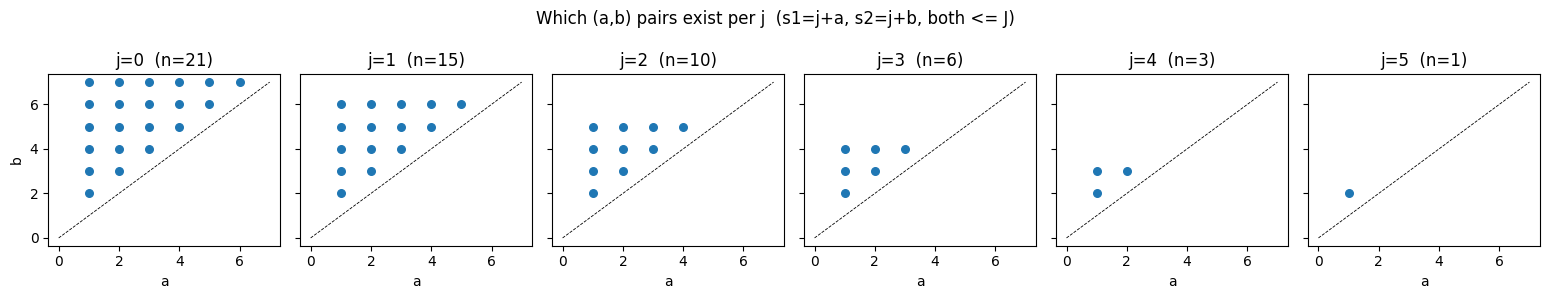

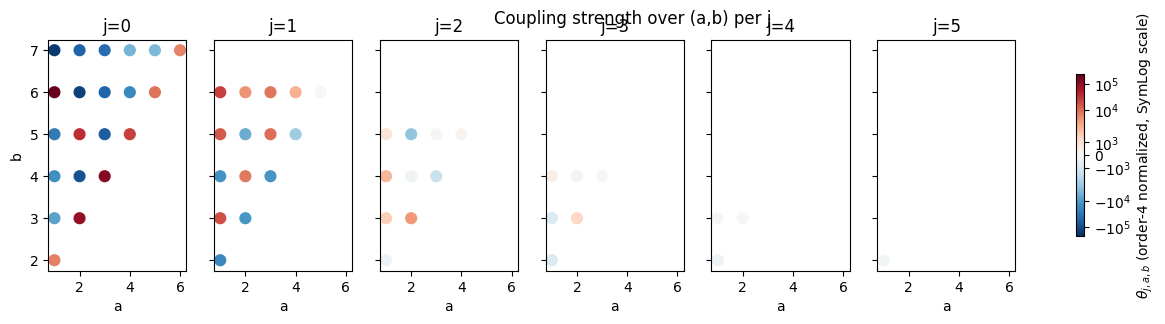

In [44]:
# ----------------------------------------------------------------------
# Diagnostic: what (a,b) pairs exist for each j -- pure index structure,
# no theta values yet, just to build intuition before interpreting magnitudes.
# ----------------------------------------------------------------------
js_unique = sorted(set(j_arr))
fig, axes = plt.subplots(1, len(js_unique), figsize=(2.6*len(js_unique), 3), sharex=True, sharey=True)
for ax, j in zip(np.atleast_1d(axes), js_unique):
    mask = j_arr == j
    ax.scatter(a_arr[mask], b_arr[mask], s=30)
    ax.plot([0, Jp], [0, Jp], 'k--', lw=0.6)  # a=b diagonal, excluded by construction
    ax.set_title(f'j={j}  (n={mask.sum()})')
    ax.set_xlabel('a')
axes[0].set_ylabel('b')
plt.suptitle('Which (a,b) pairs exist per j  (s1=j+a, s2=j+b, both <= J)')
plt.tight_layout()
plt.show()

# Same thing but colored by theta value, to see magnitude vs (a,b) at each j
from matplotlib.colors import SymLogNorm
theta_o4_table = theta_o4  # from previous message: theta_raw_mean * norm_jab**2
vmax = np.nanmax(np.abs(theta_o4_table[np.isfinite(theta_o4_table)]))
linthresh = vmax * 0.01 if vmax > 0 else 1e-5
fig, axes = plt.subplots(1, len(js_unique), figsize=(2.6*len(js_unique), 3), sharex=True, sharey=True)
for ax, j in zip(np.atleast_1d(axes), js_unique):
    mask = j_arr == j
    
    # Use SymLogNorm instead of vmin/vmax directly in the scatter call
    sc = ax.scatter(a_arr[mask], b_arr[mask], 
                    c=theta_o4_table[mask],
                    cmap='RdBu_r', 
                    norm=SymLogNorm(linthresh=linthresh, linscale=1, vmin=-vmax, vmax=vmax), 
                    s=60)
    ax.set_title(f'j={j}')
    ax.set_xlabel('a')

axes[0].set_ylabel('b')
fig.colorbar(sc, ax=axes, shrink=0.7, label=r'$\theta_{j,a,b}$ (order-4 normalized, SymLog scale)')
plt.suptitle('Coupling strength over (a,b) per j')
plt.show()

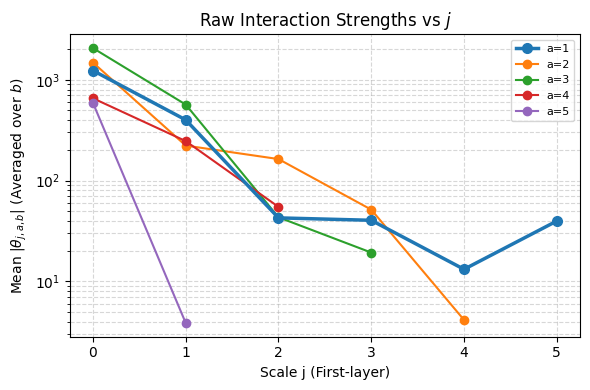

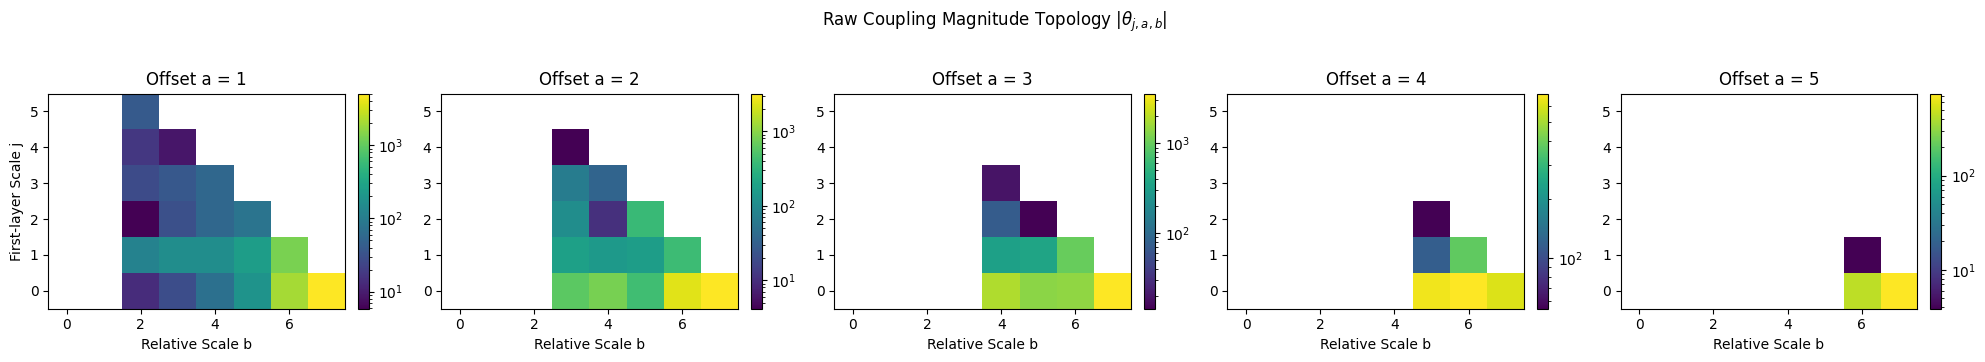

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1. New Plot: Raw |theta_{j,a,b}| averaged over b, plotted vs j
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))

# Find all unique 'a' values present in our decoded data
unique_a = sorted({a for (_, a) in xi})

for a in unique_a:
    js_for_a = []
    avg_thetas = []
    
    # Loop over j to find what data exists for this specific 'a'
    for j in sorted(set(j_arr)):
        if (j, a) in groups:
            pts = groups[(j, a)]  # list of (b, abs_theta)
            
            # Collapse across all available 'b' values by taking the mean
            raw_vals = [p[1] for p in pts]
            avg_theta_over_b = np.mean(raw_vals) 
            
            js_for_a.append(j)
            avg_thetas.append(avg_theta_over_b)
            
    if js_for_a:
        kw = dict(marker='o', label=f'a={a}')
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        # We use semilogy here because physical coupling parameters 
        # span orders of magnitude across different scales
        plt.semilogy(js_for_a, avg_thetas, **kw)

plt.xlabel('Scale j (First-layer)')
plt.ylabel(r'Mean $|\theta_{j,a,b}|$ (Averaged over $b$)')
plt.title(r'Raw Interaction Strengths vs $j$')
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 2. Smart Alternative: 2D Heatmap Matrix of Raw |theta| (j vs b)
# ----------------------------------------------------------------------
# Dynamically determine the required grid dimensions from the data arrays
max_j = int(j_arr.max()) + 1
max_b = int(b_arr.max()) + 1

fig, axes = plt.subplots(1, len(unique_a), figsize=(4 * len(unique_a), 3.5), squeeze=False)

for idx, a in enumerate(unique_a):
    # Dynamically size the grid so an IndexError is structurally impossible
    grid = np.full((max_j, max_b), np.nan)
    
    for (j, aa, b), v in table.items():
        if aa == a and np.isfinite(v):
            # Ensuring coordinates fall safely inside the grid boundaries
            if j < max_j and b < max_b:
                grid[j, b] = abs(v)
            
    ax = axes[0, idx]
    from matplotlib.colors import LogNorm
    
    if not np.nanmax(grid) > 0:
        continue
        
    im = ax.imshow(grid, origin='lower', cmap='viridis', 
                   norm=LogNorm(vmin=np.nanmin(grid[grid>0]), vmax=np.nanmax(grid)),
                   aspect='auto') # 'auto' handles non-square aspect ratios beautifully
    
    ax.set_title(f'Offset a = {a}')
    ax.set_xlabel('Relative Scale b')
    if idx == 0:
        ax.set_ylabel('First-layer Scale j')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(r'Raw Coupling Magnitude Topology $|\theta_{j,a,b}|$', y=1.02)
plt.tight_layout()
plt.show()

## Coarse grain 

39999 132


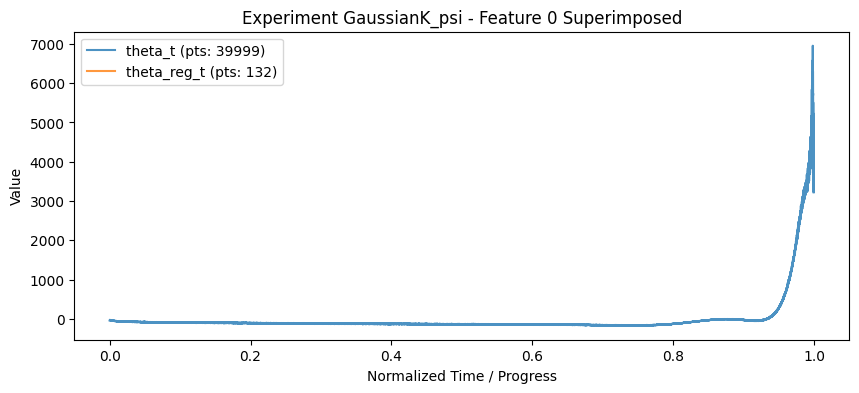

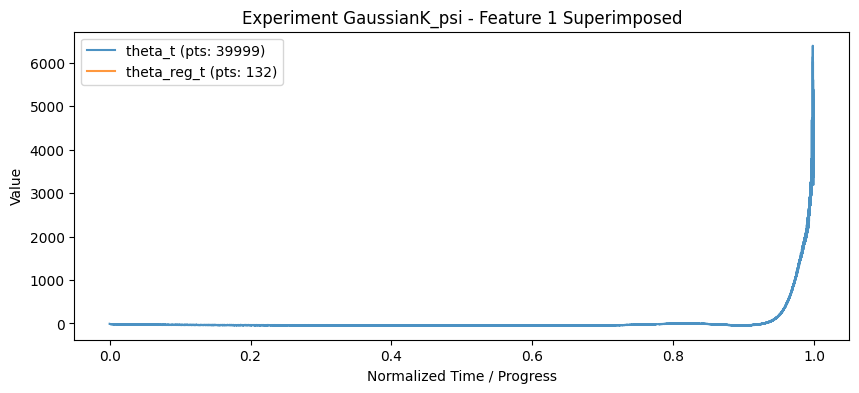

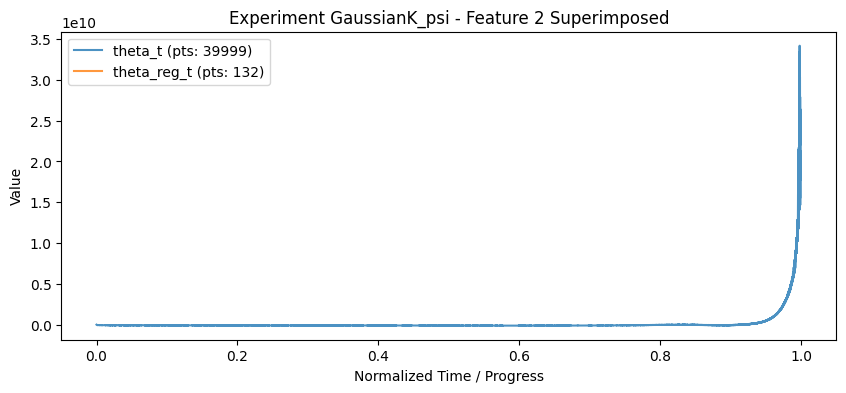

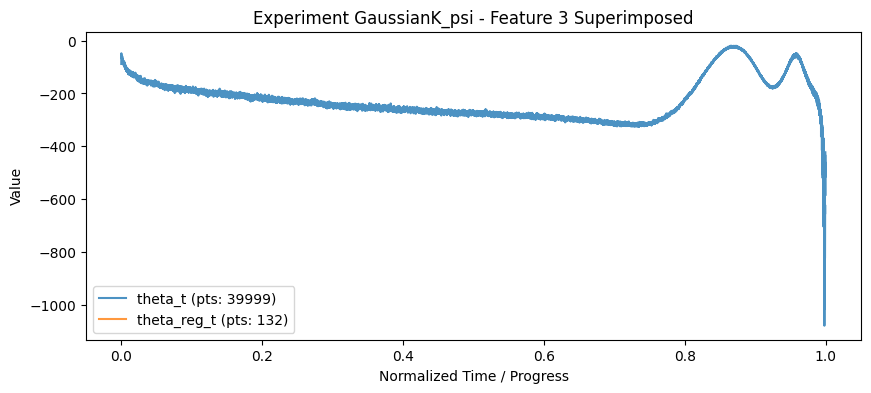

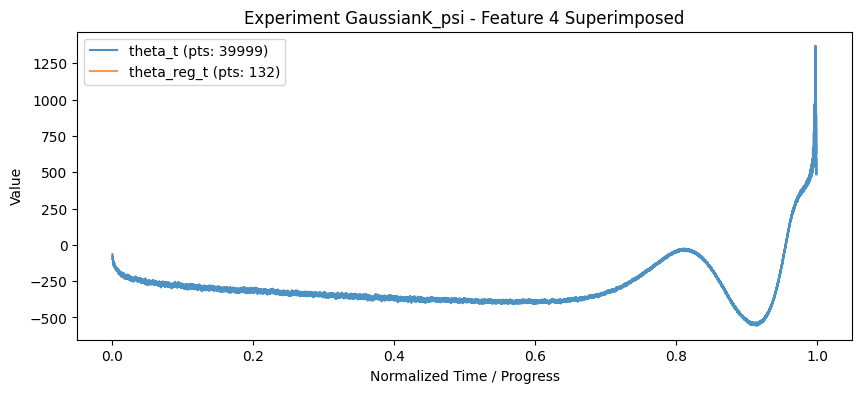

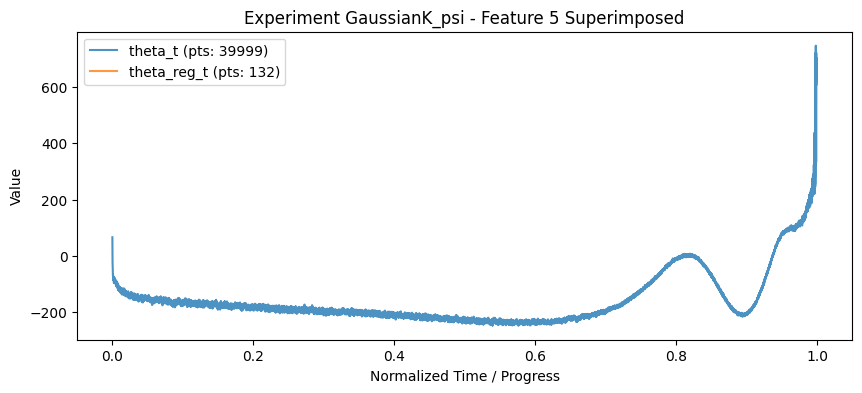

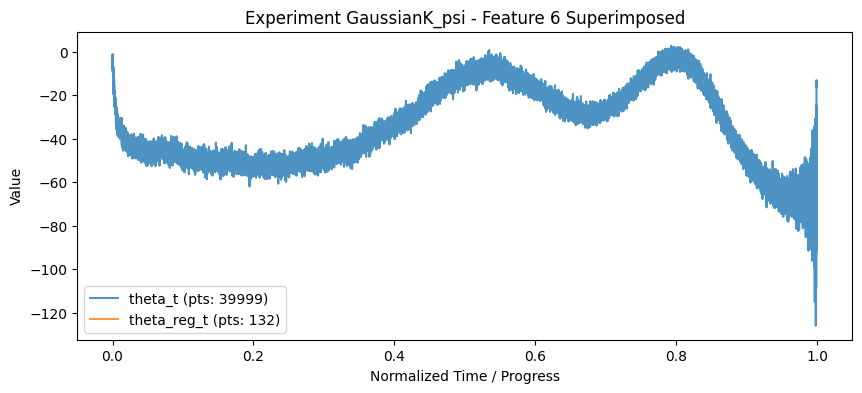

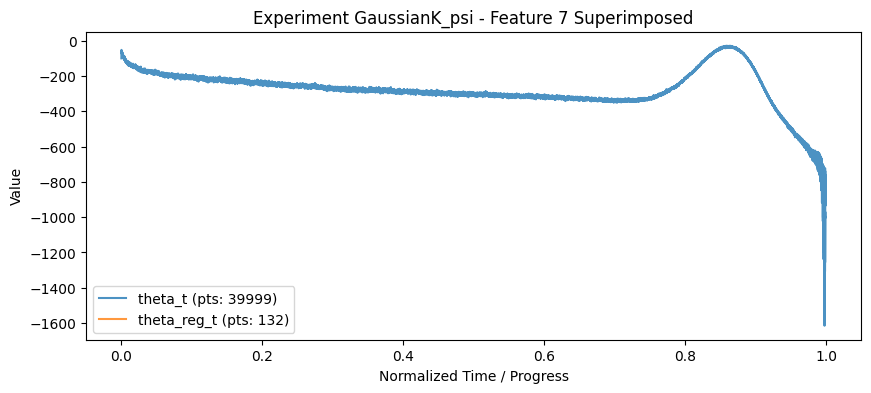

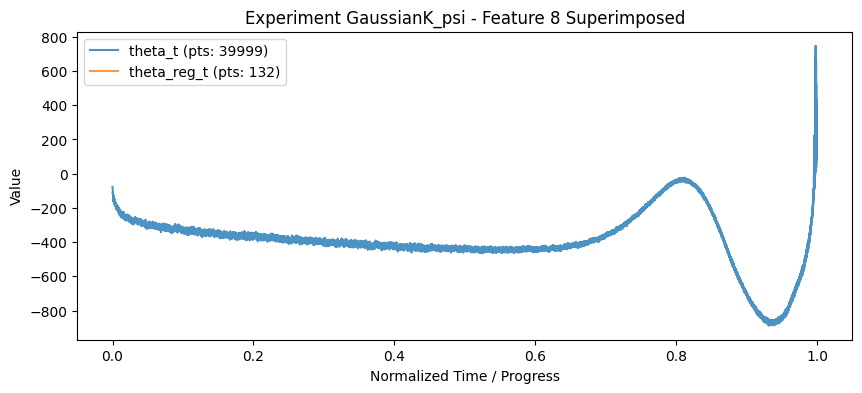

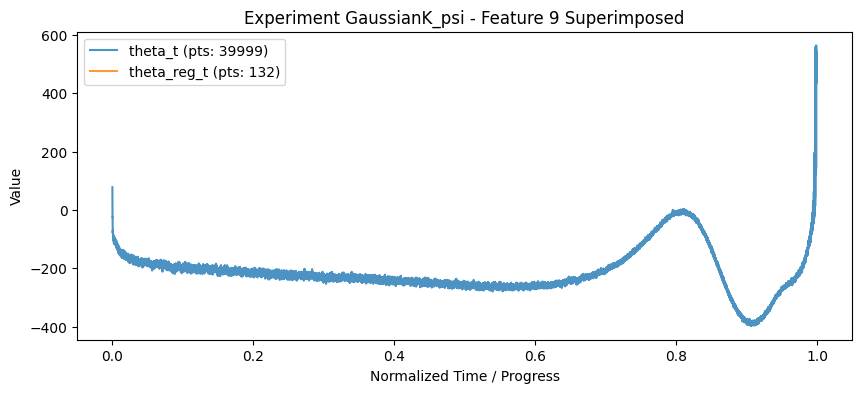

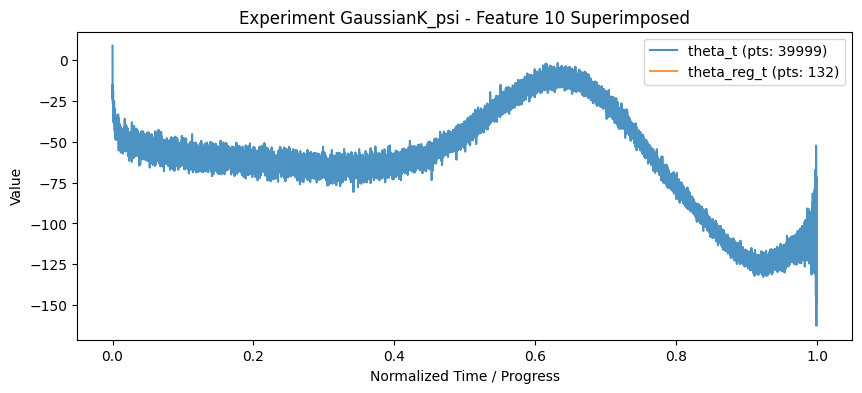

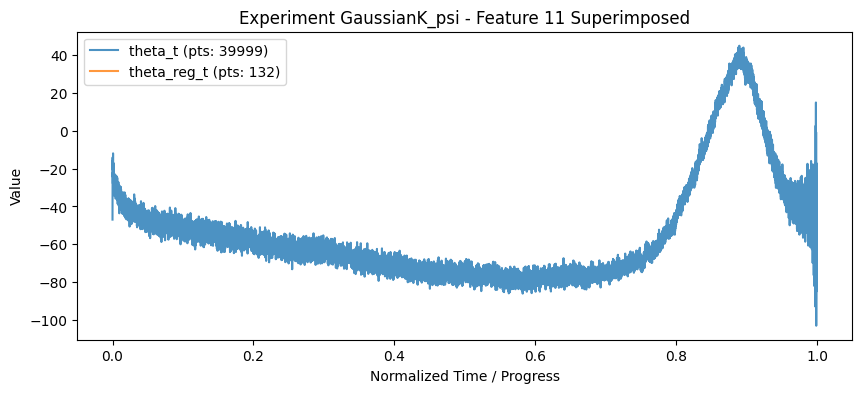

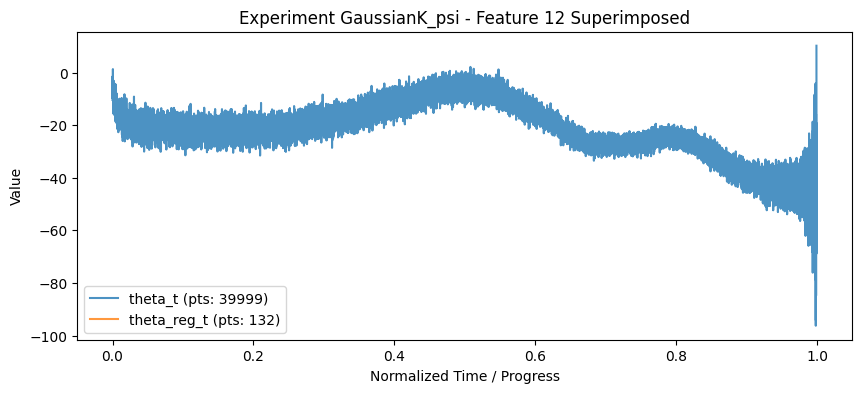

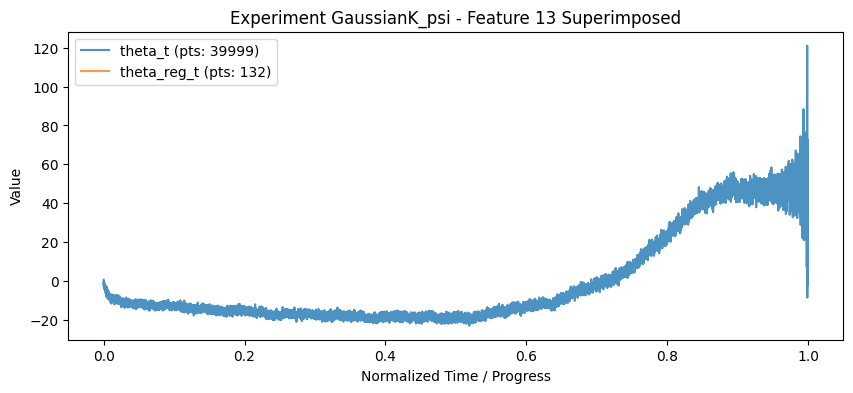

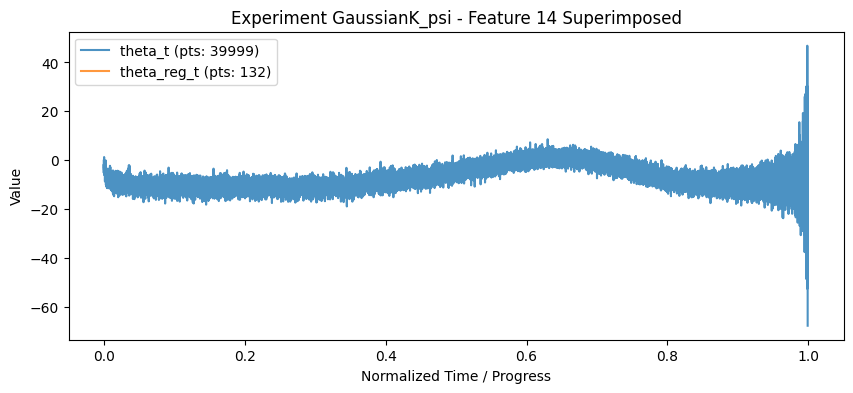

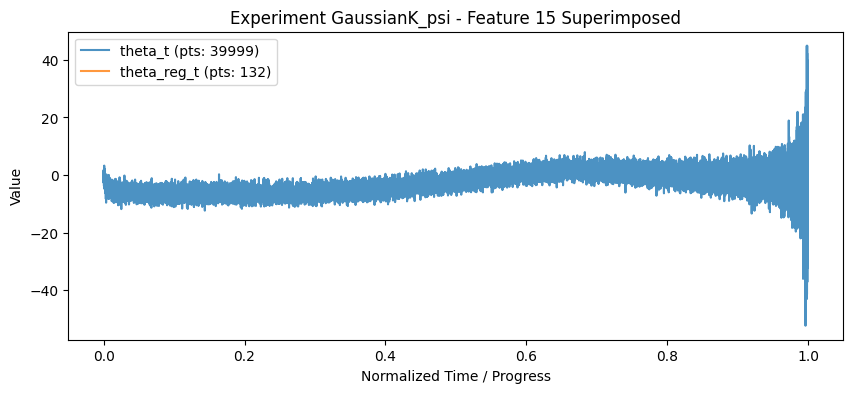

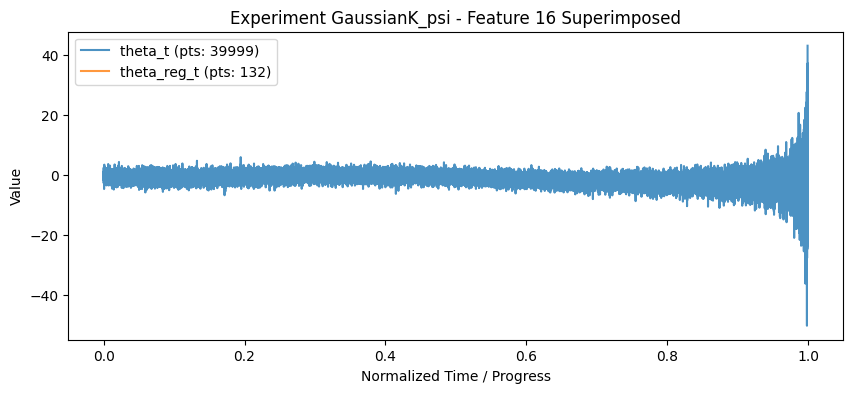

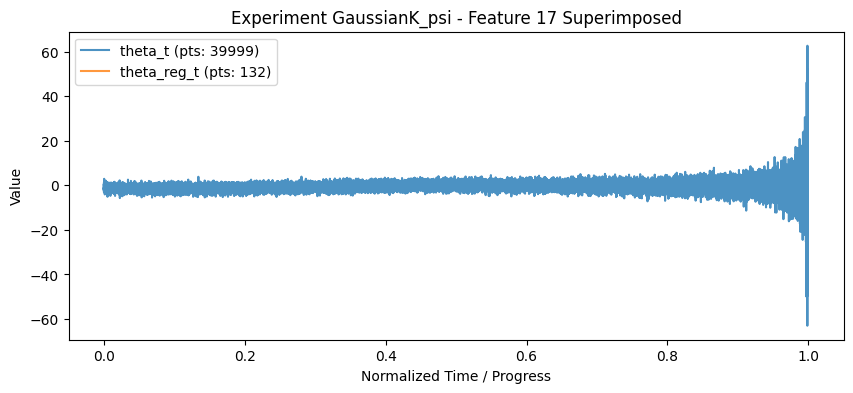

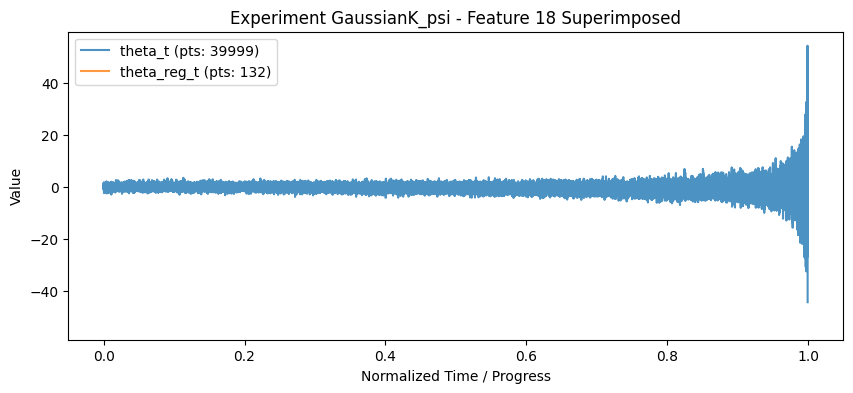

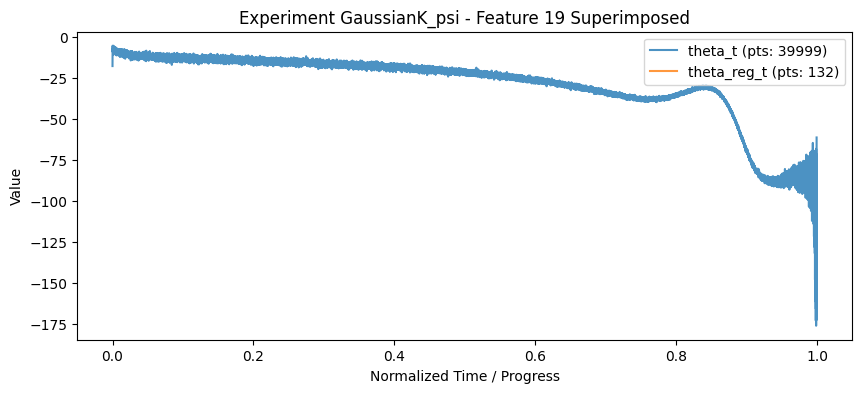

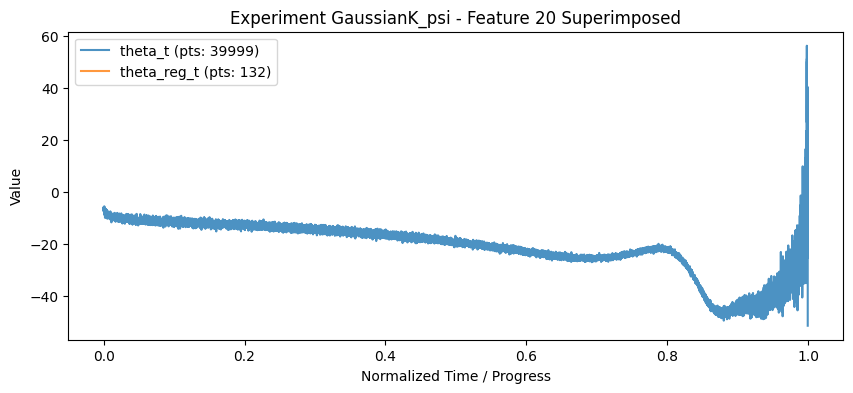

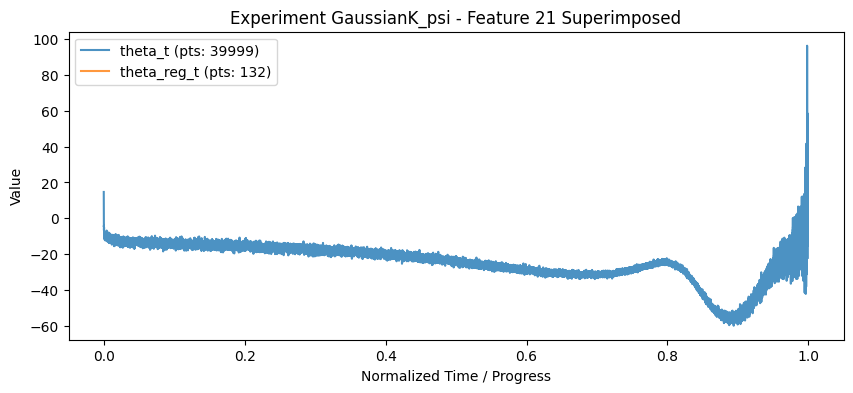

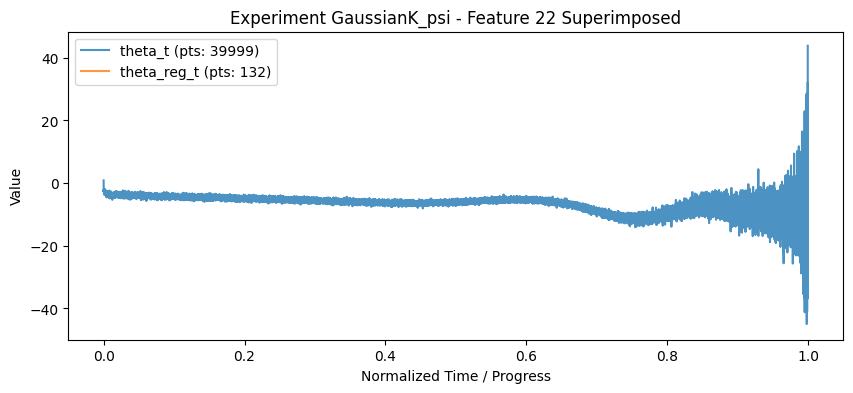

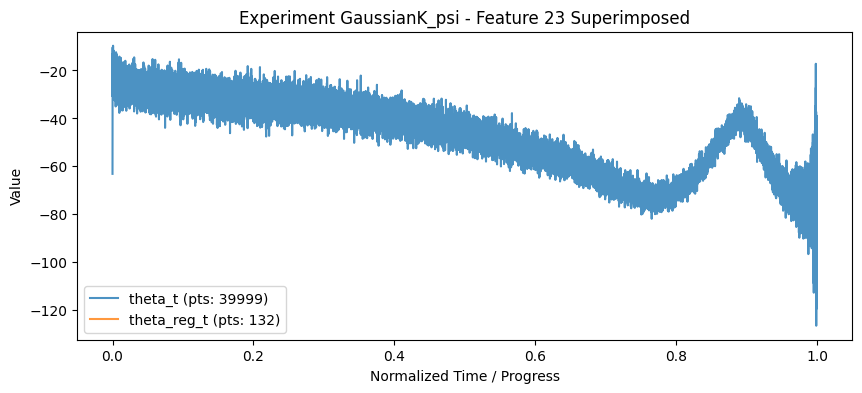

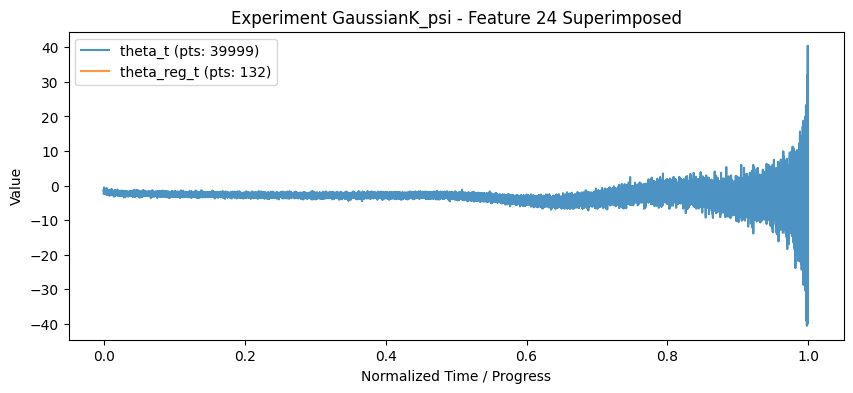

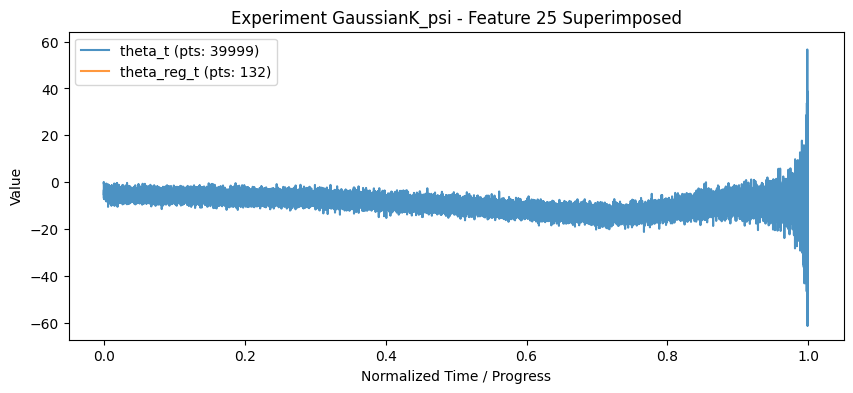

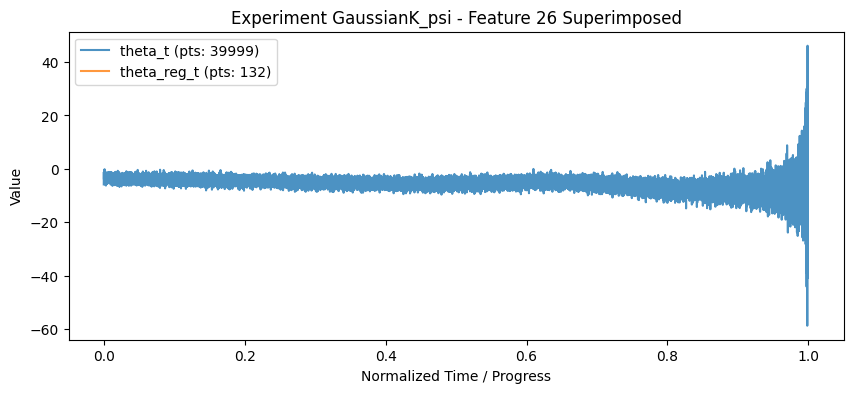

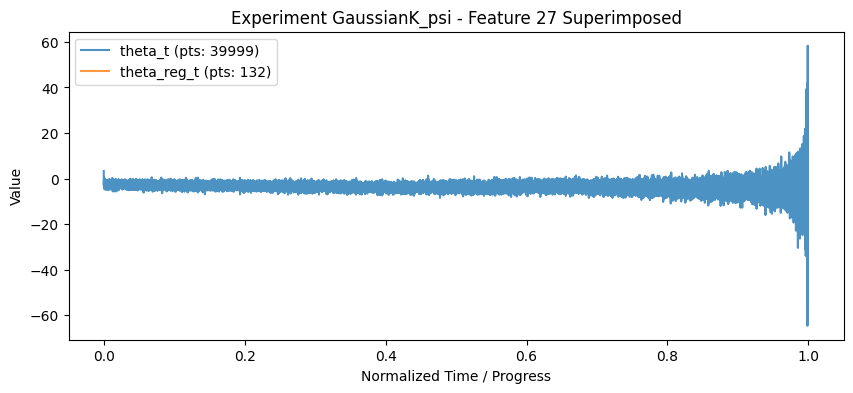

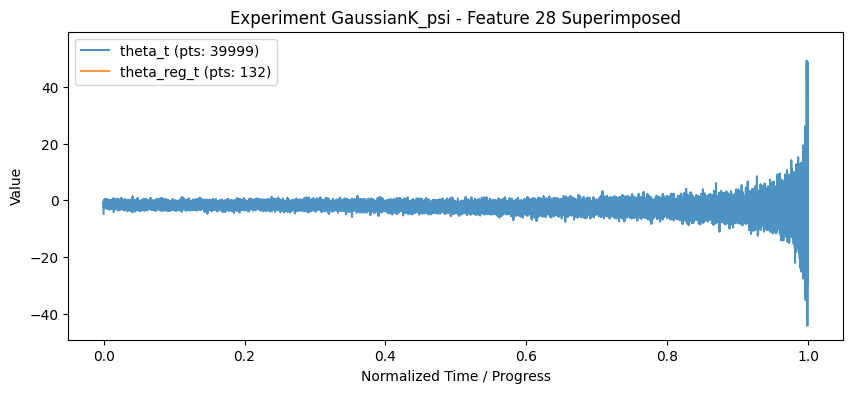

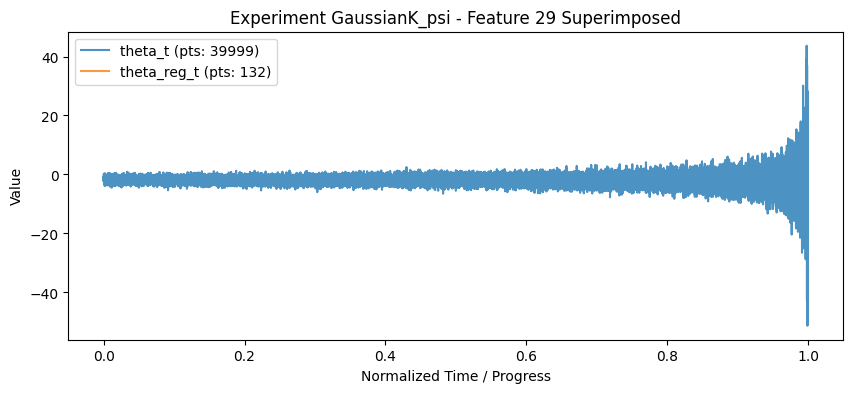

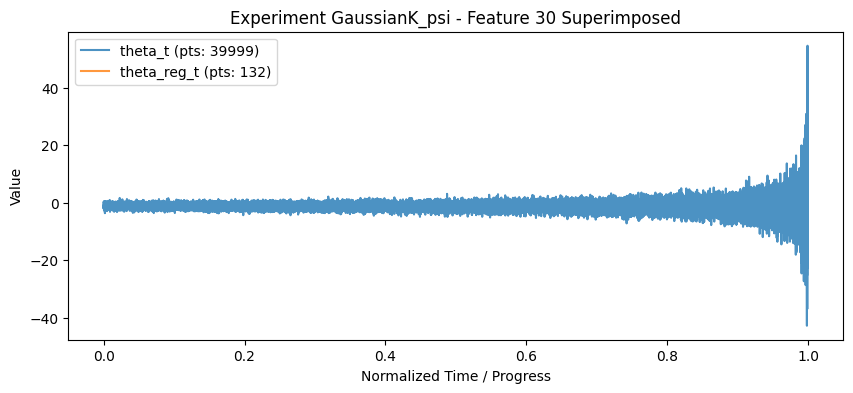

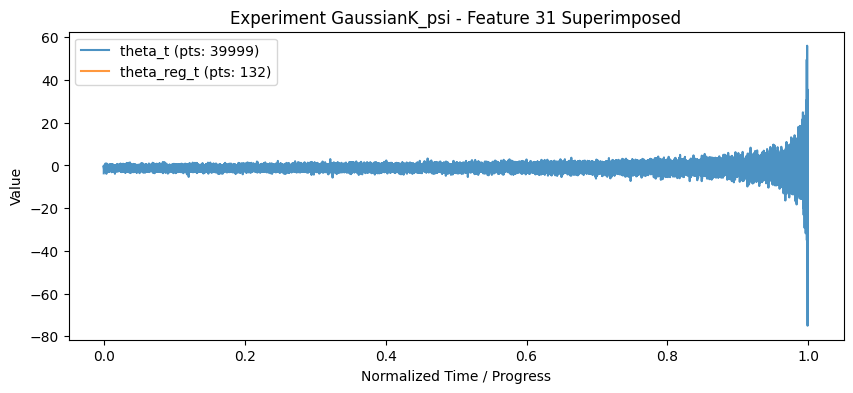

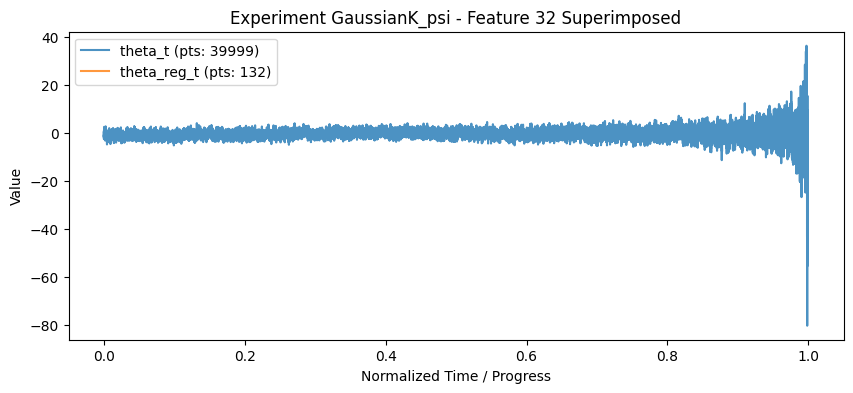

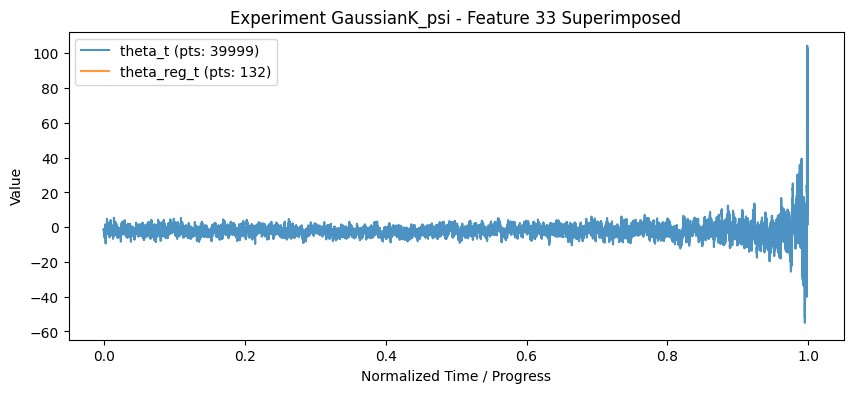

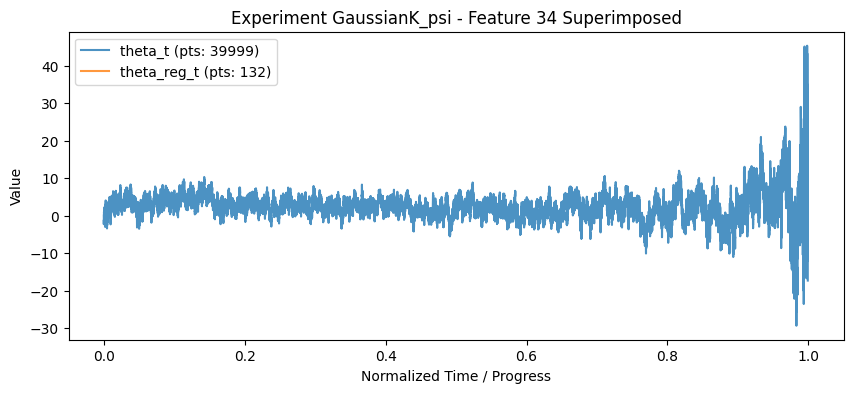

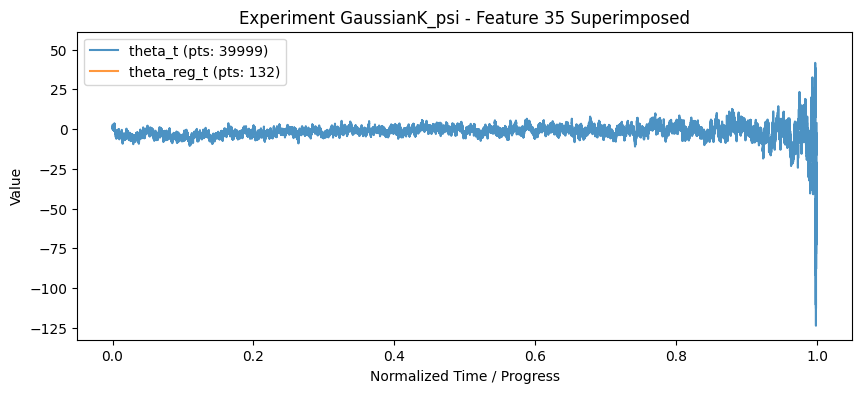

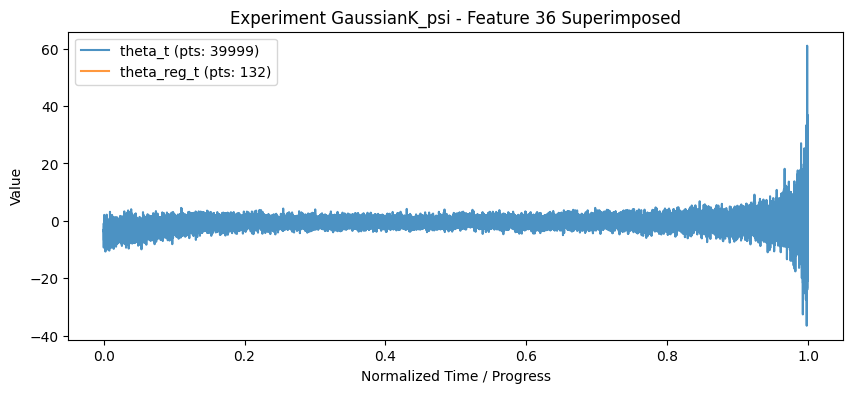

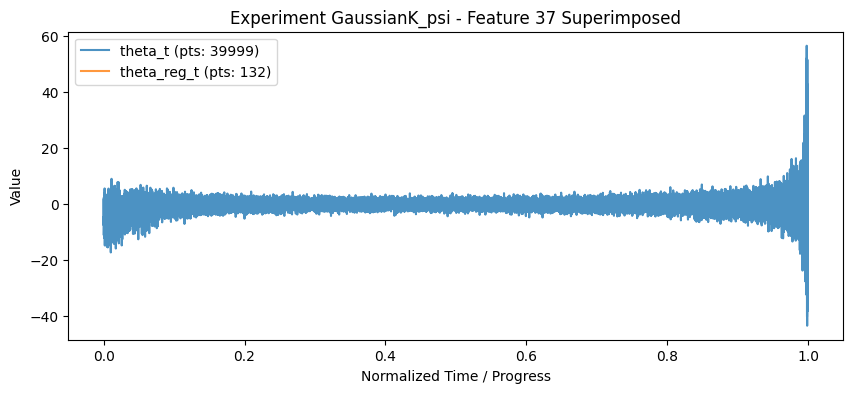

In [51]:
# Move to CPU and convert to numpy for easier plotting
import matplotlib.pyplot as plt
theta_t = theta_t.cpu()
theta_reg_t = theta_reg_t.cpu()

# Get the number of time steps (rows) for each
len_t = theta_t.shape[0]
len_reg = theta_reg_t.shape[0]
print(len_t, len_reg) 

# Iterate through each feature/column
for i in range(theta_t.shape[1]): 
    # Create matching X-axes spanning from 0 to 1 (or 0 to len_t if preferred)
    x_t = np.linspace(0, 1, len_t)
    x_reg = np.linspace(0, 1, len_reg)
    
    plt.figure(figsize=(10, 4))
    
    # Plot both on the same axes
    #plt.plot(results[key]['xt'], theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_t, theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_reg, theta_reg_t[:, i], label=f"theta_reg_t (pts: {len_reg})", alpha=0.8) 
    
    plt.title(f"Experiment {key} - Feature {i} Superimposed")
    plt.xlabel("Normalized Time / Progress")
    plt.ylabel("Value")
    plt.legend()
    plt.show()  # Show the combined plot

## Moment matching diagnostics

In [84]:
threshold = 1e-8

for key, exp in experiments.items():
    res = results[key]
    print(exp['label'])
    if res.get('barphi_e') is None or res.get('barphi_p') is None:
        print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
    else:
        plot_moment_matching(res['barphi_e'], res['barphi_p'], res['t'], threshold)
        plt.suptitle(exp['label'])
        plt.show()


GaussianKregions ψ
Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.


## Visual comparison of samples

torch.Size([2000, 1, 32])
GaussianKregions ψ


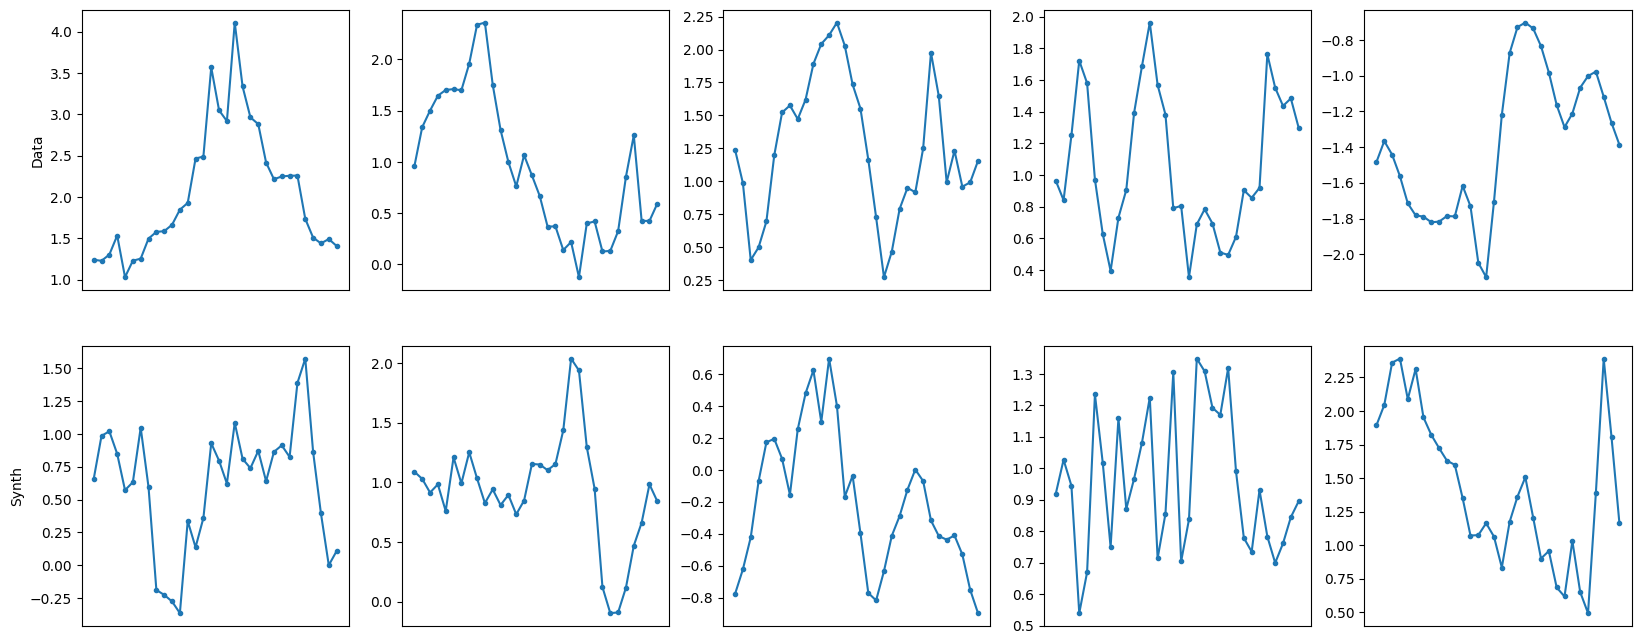

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


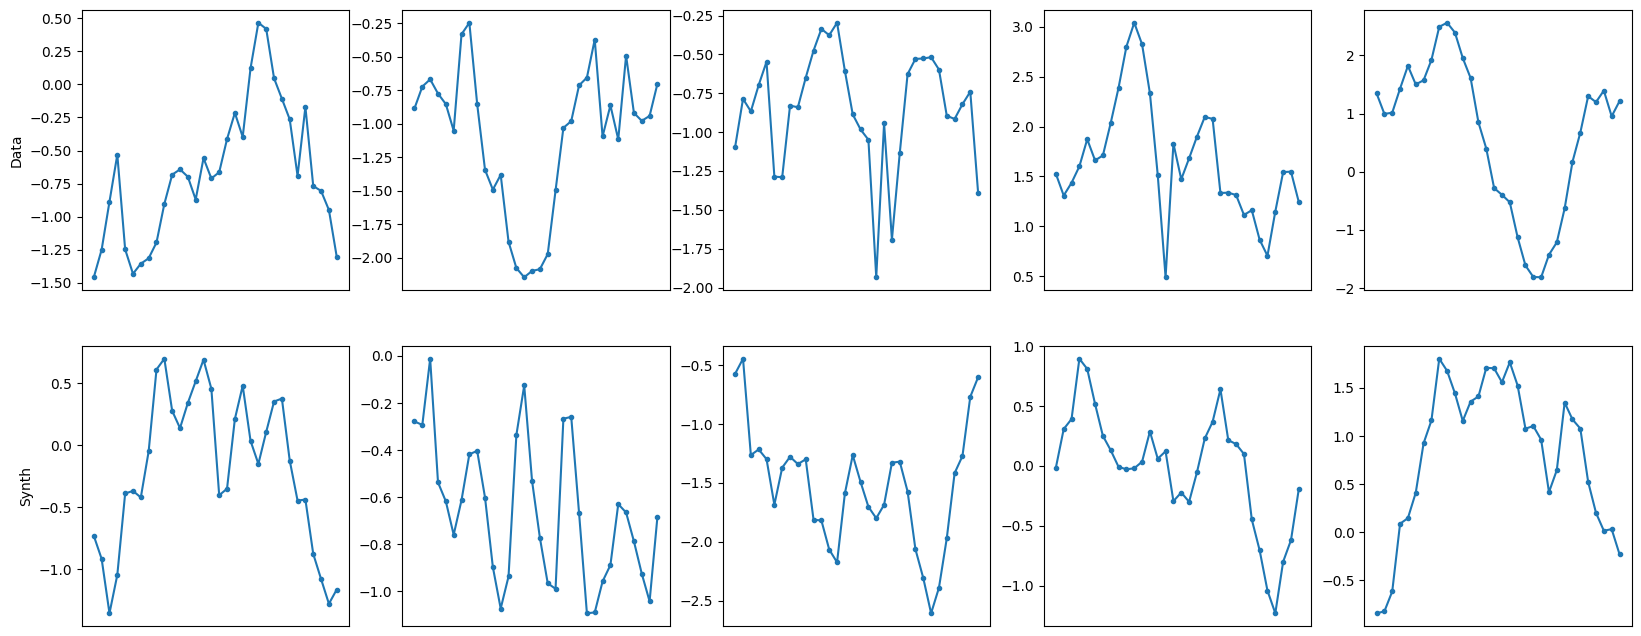

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


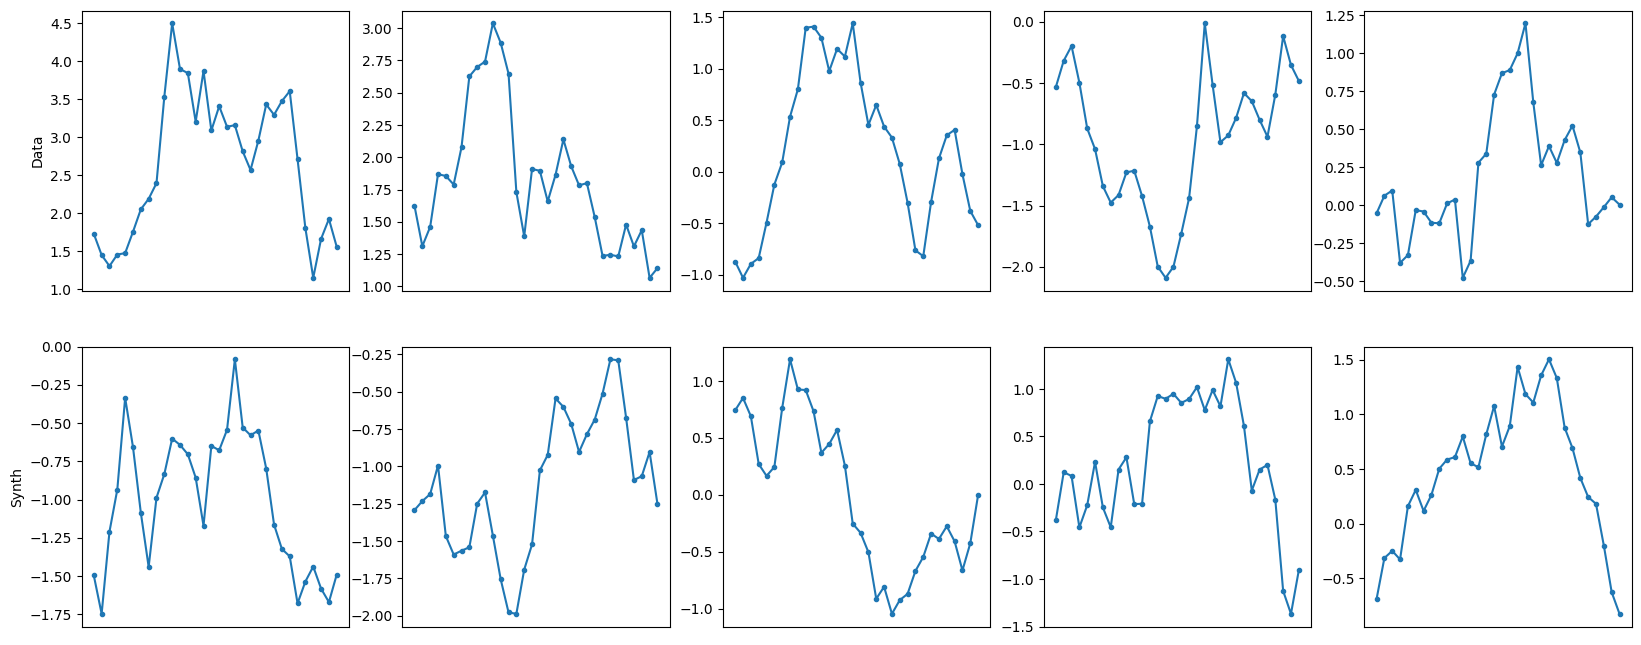

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


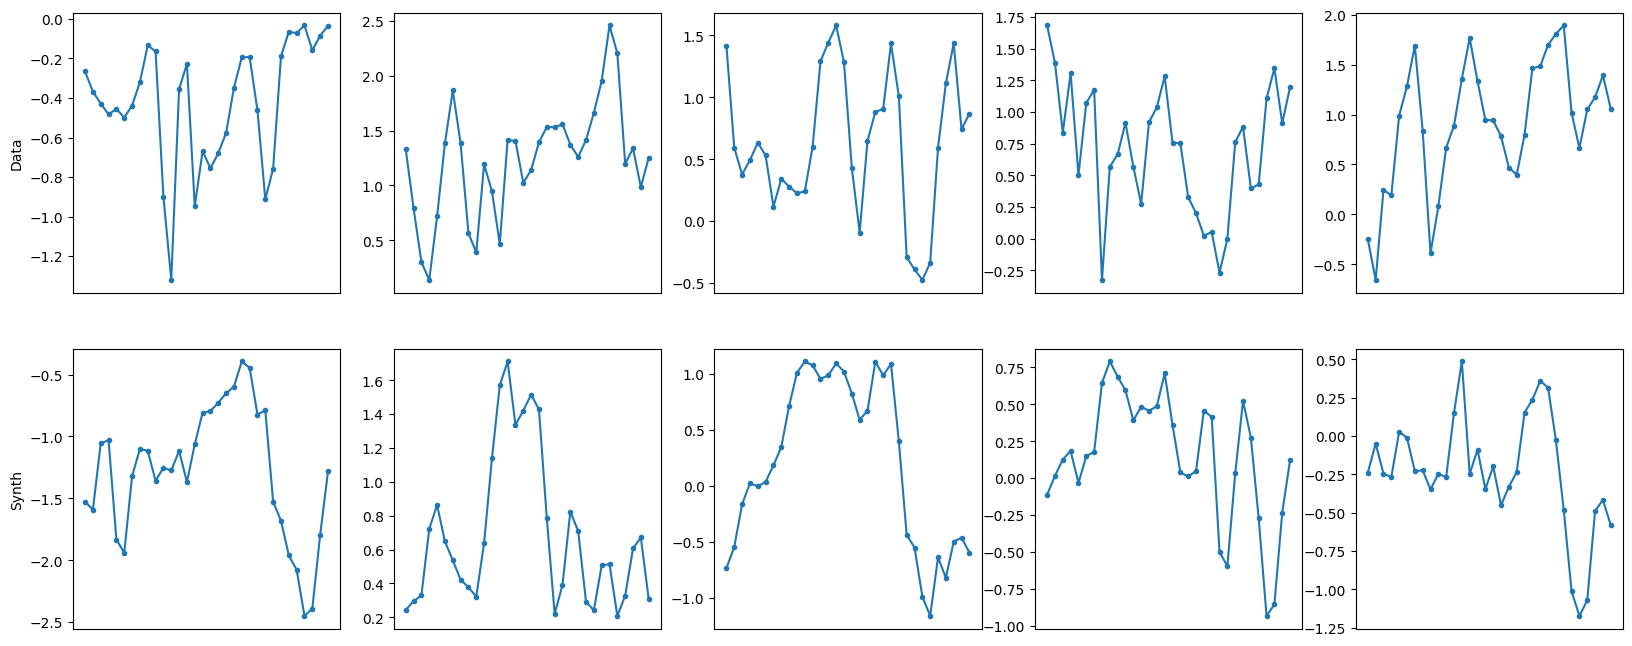

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


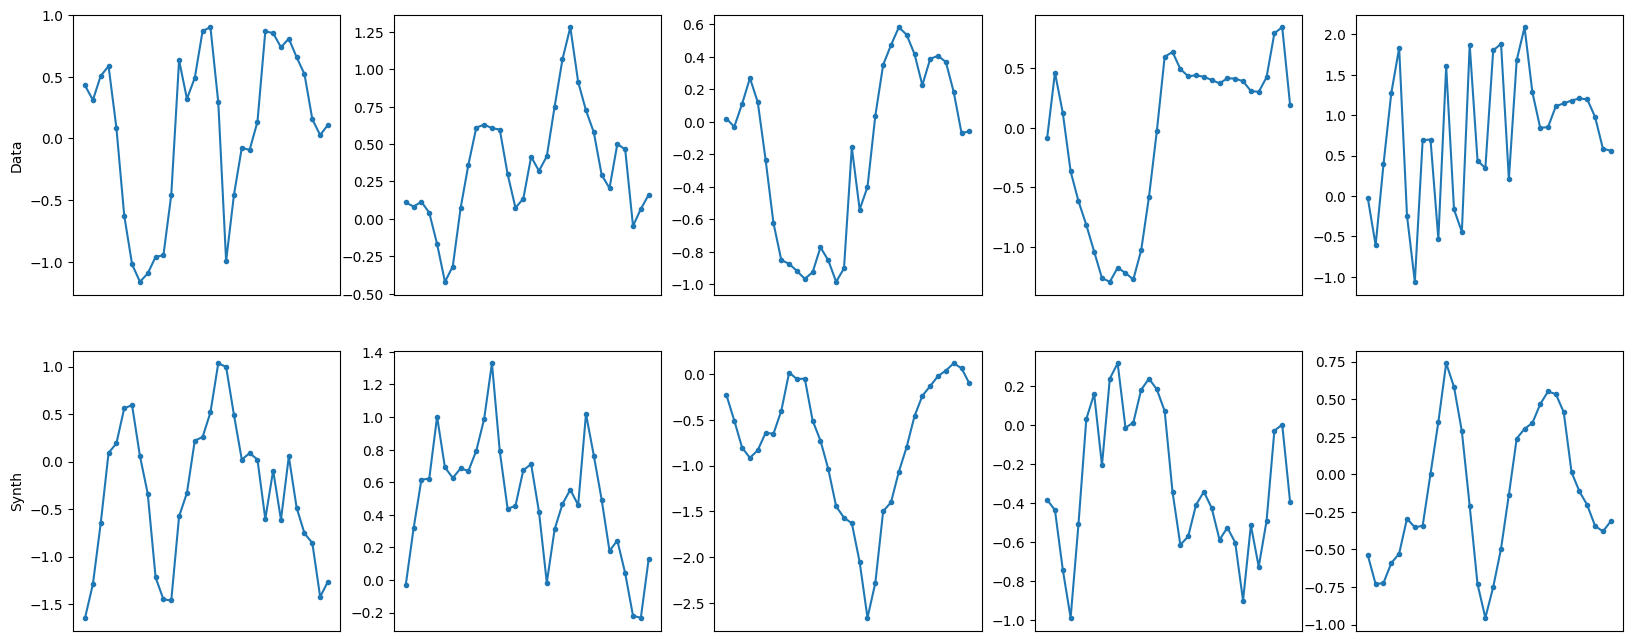

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


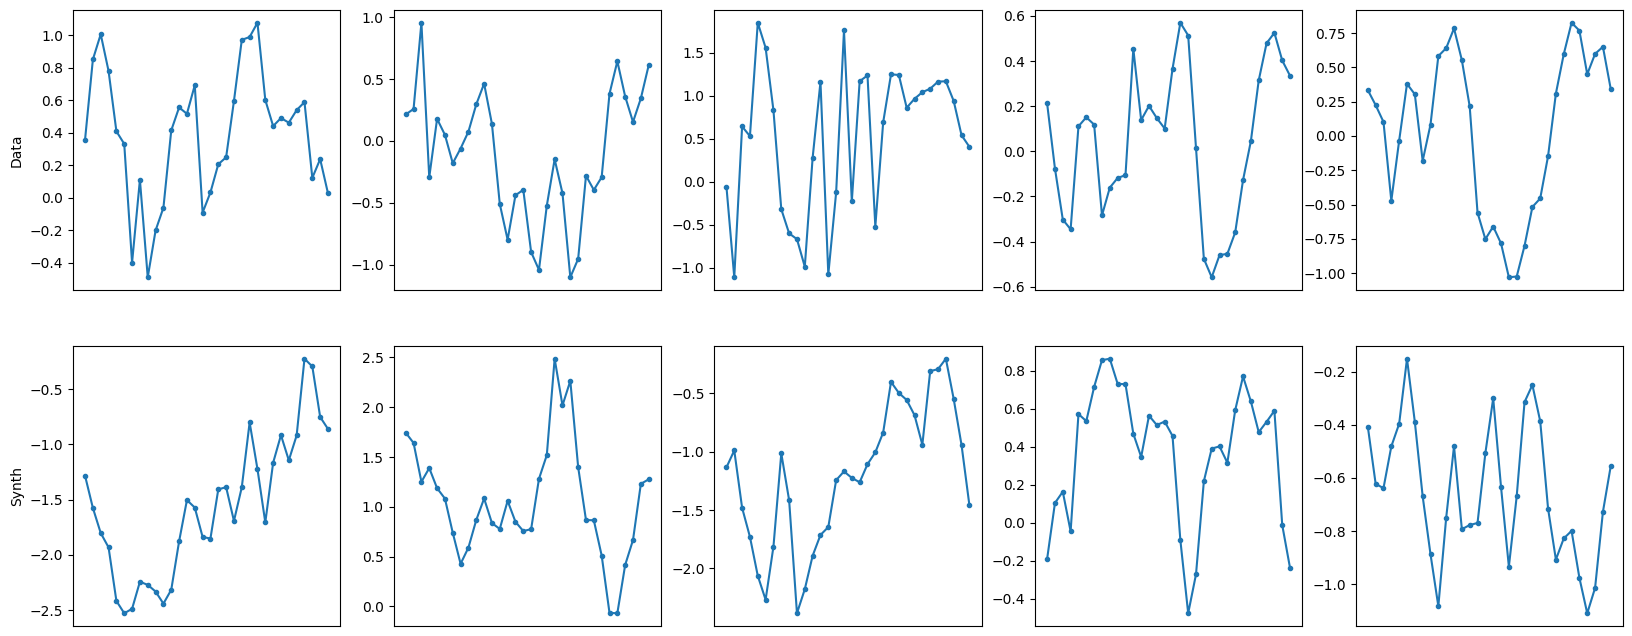

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


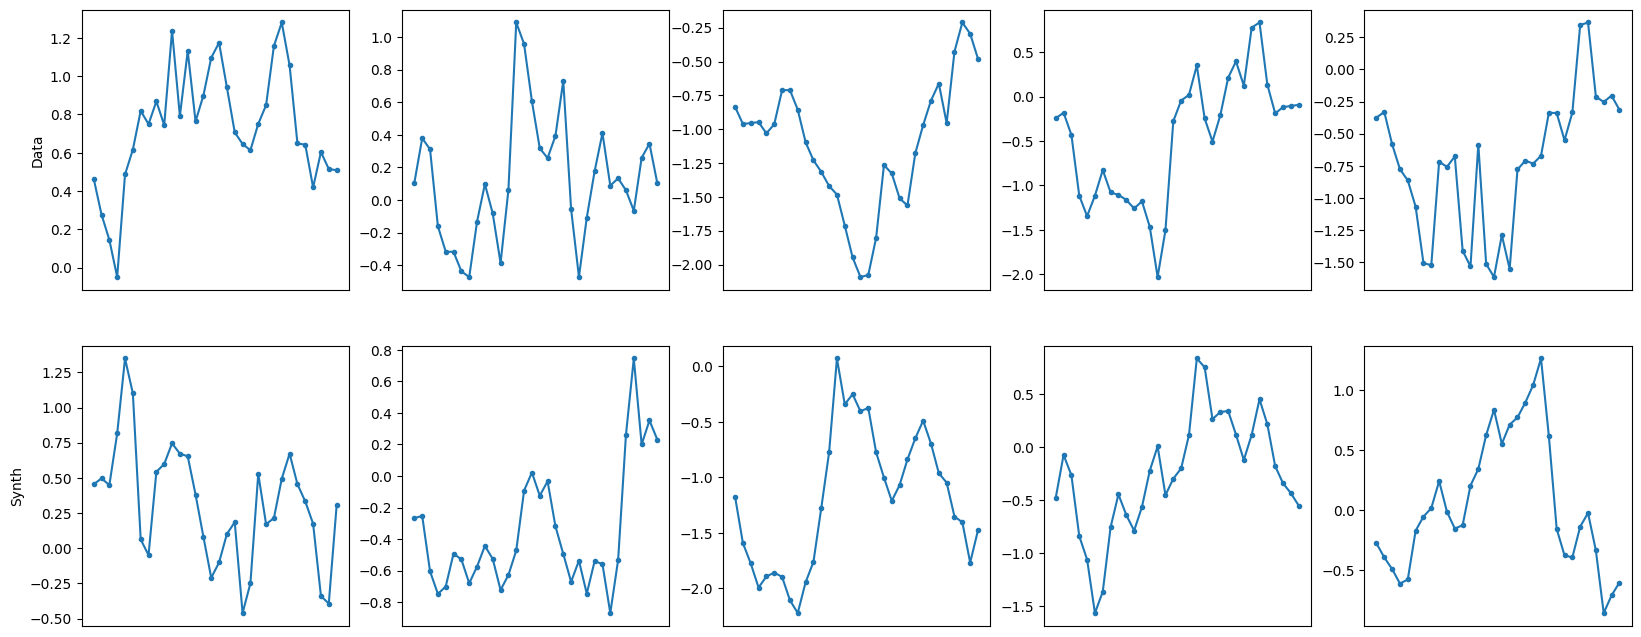

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


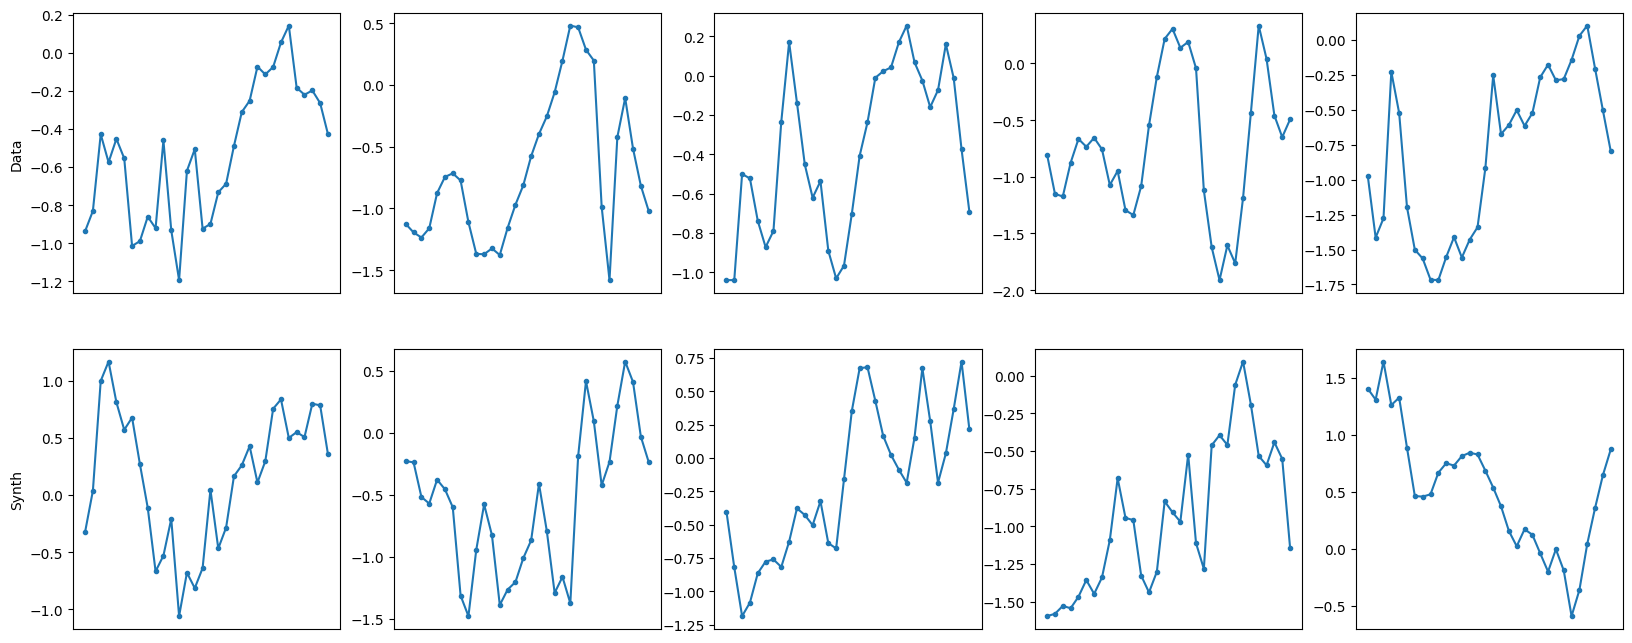

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


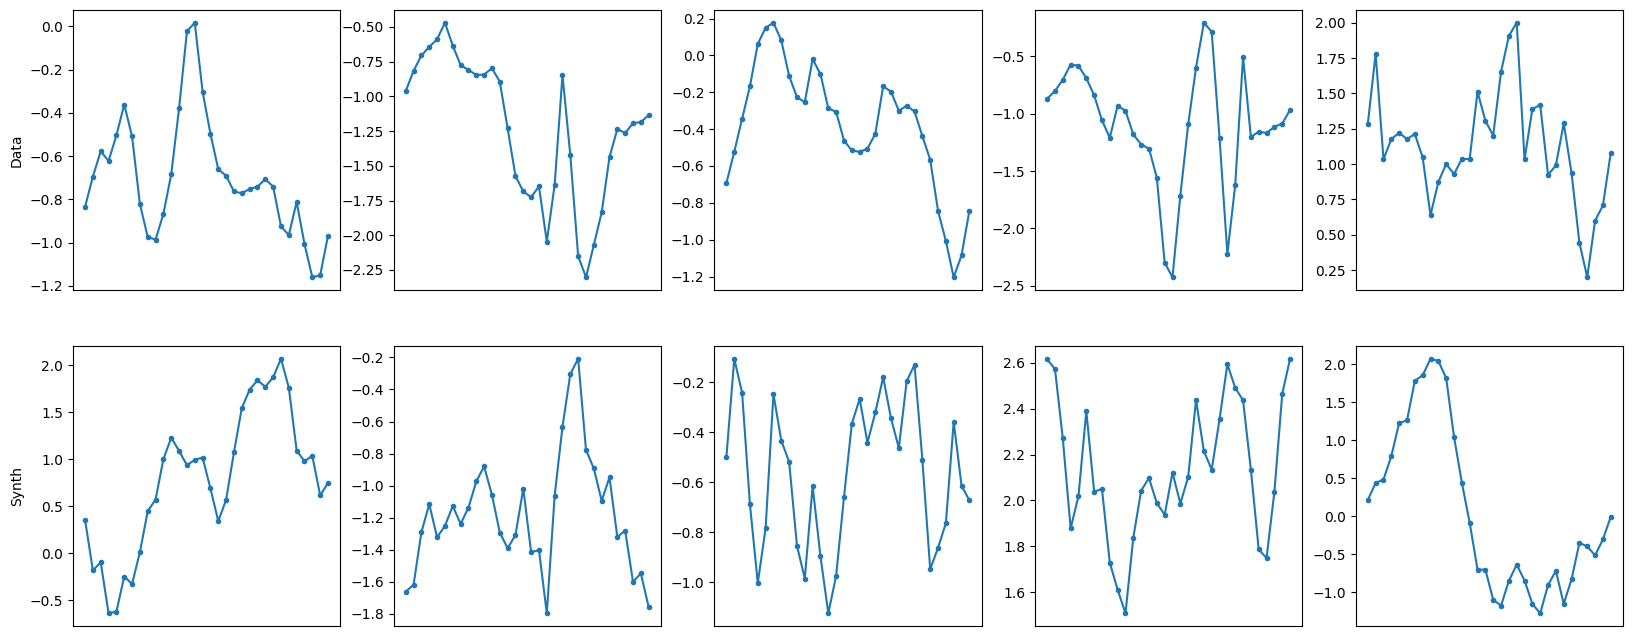

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


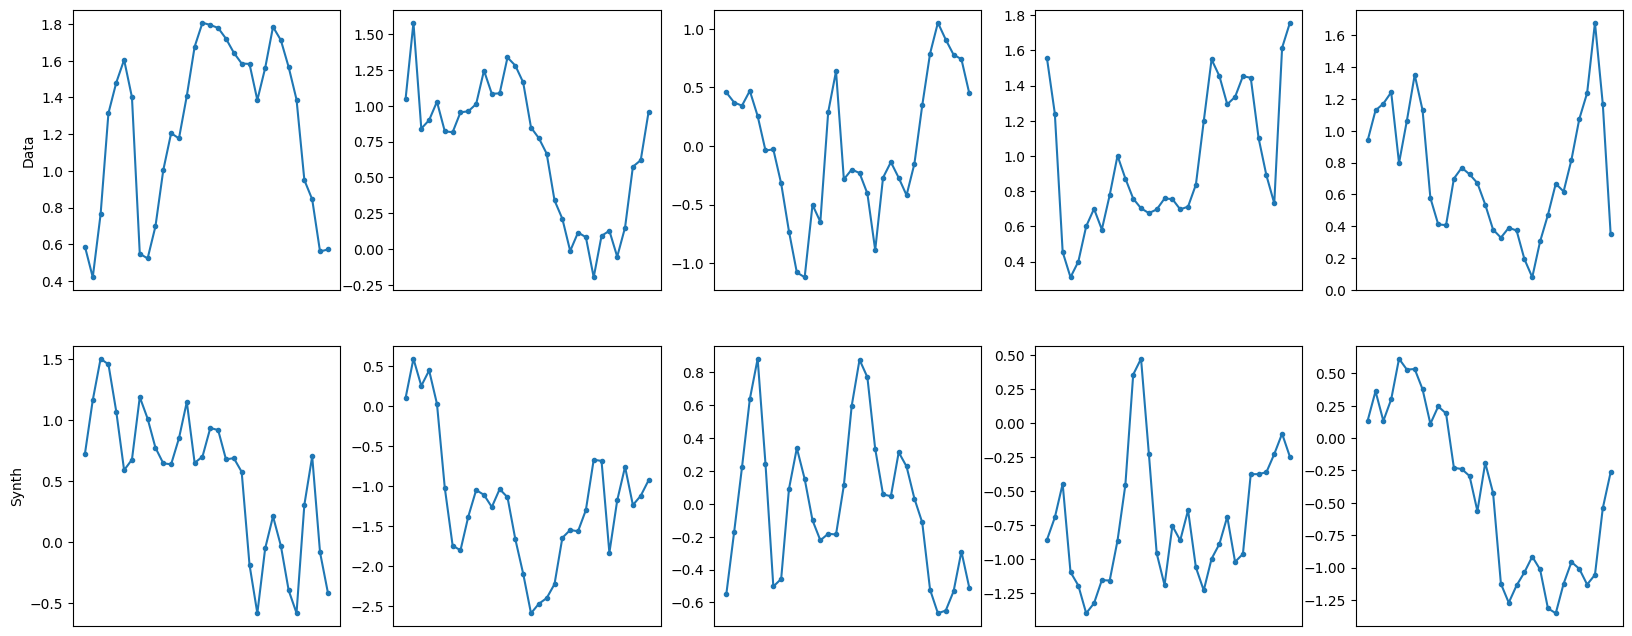

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


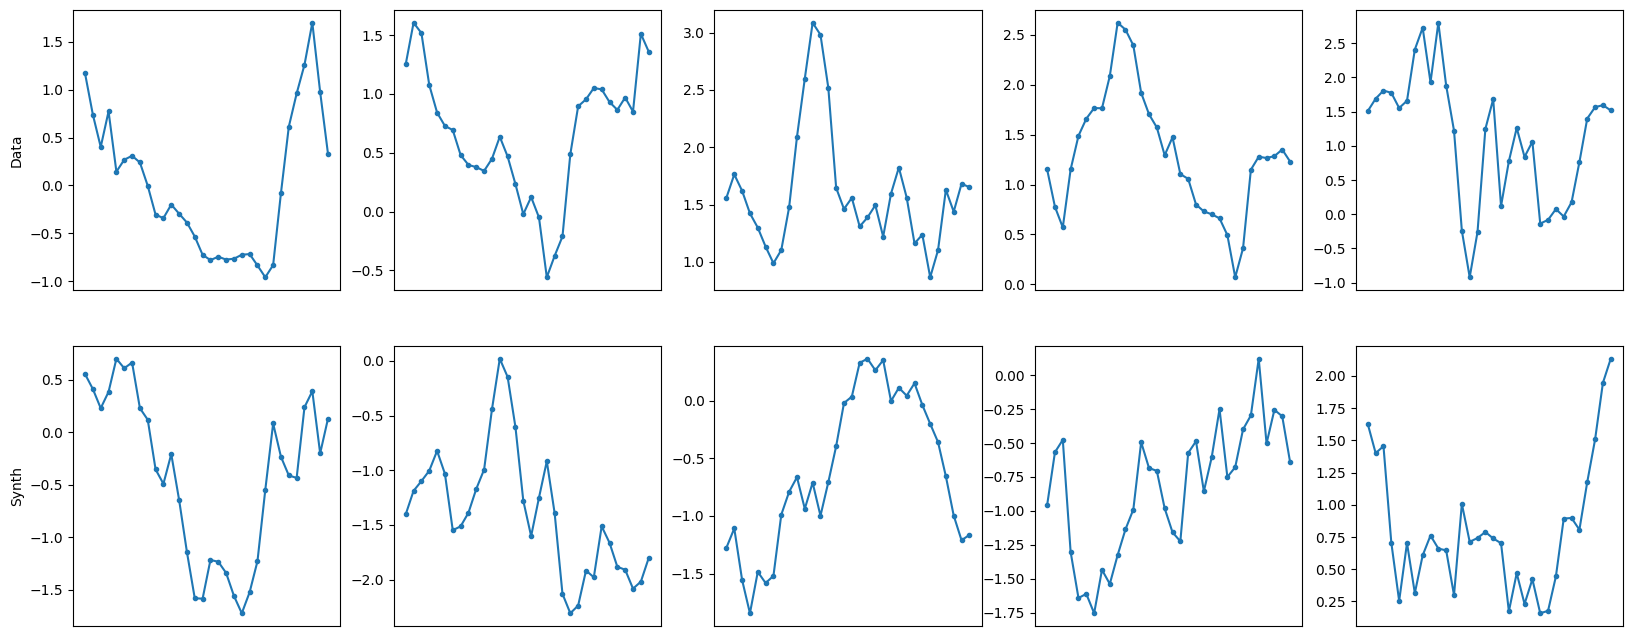

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


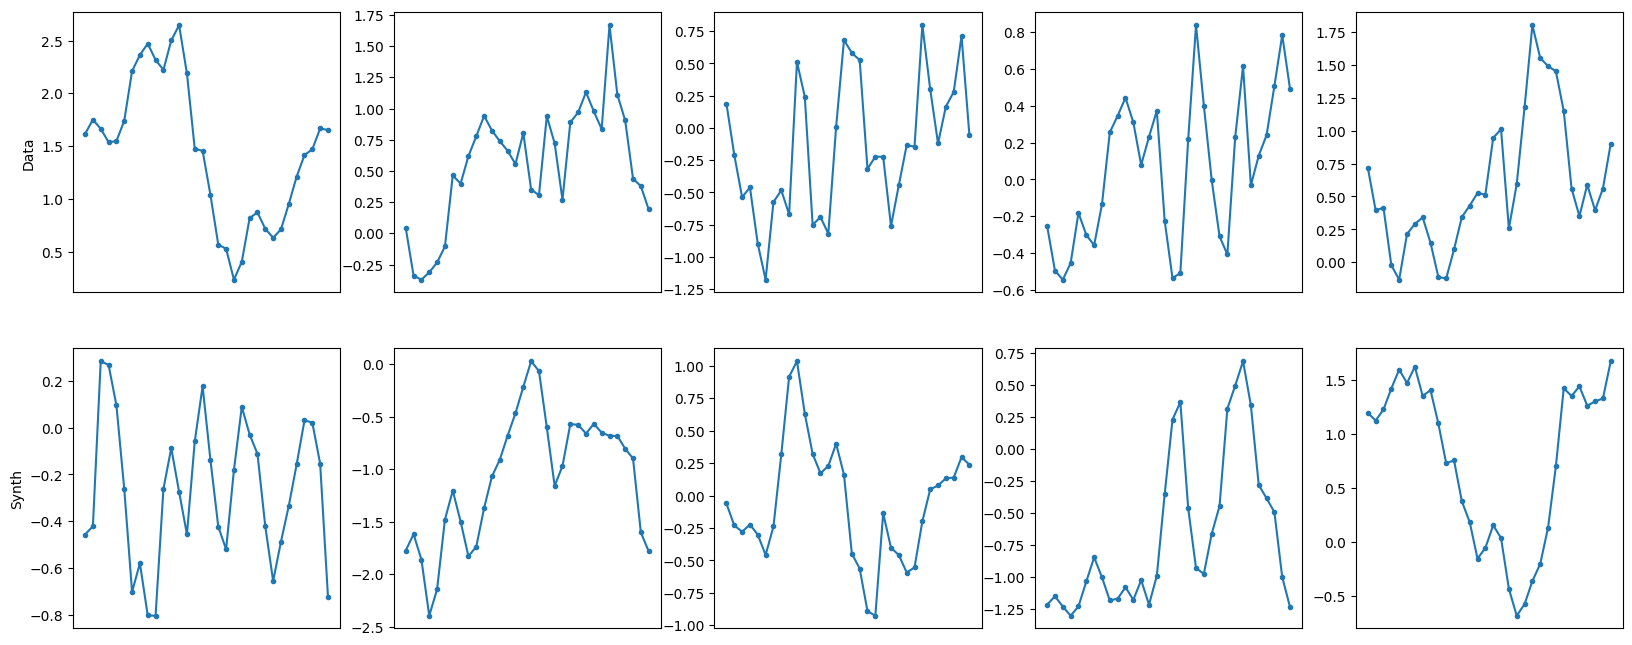

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


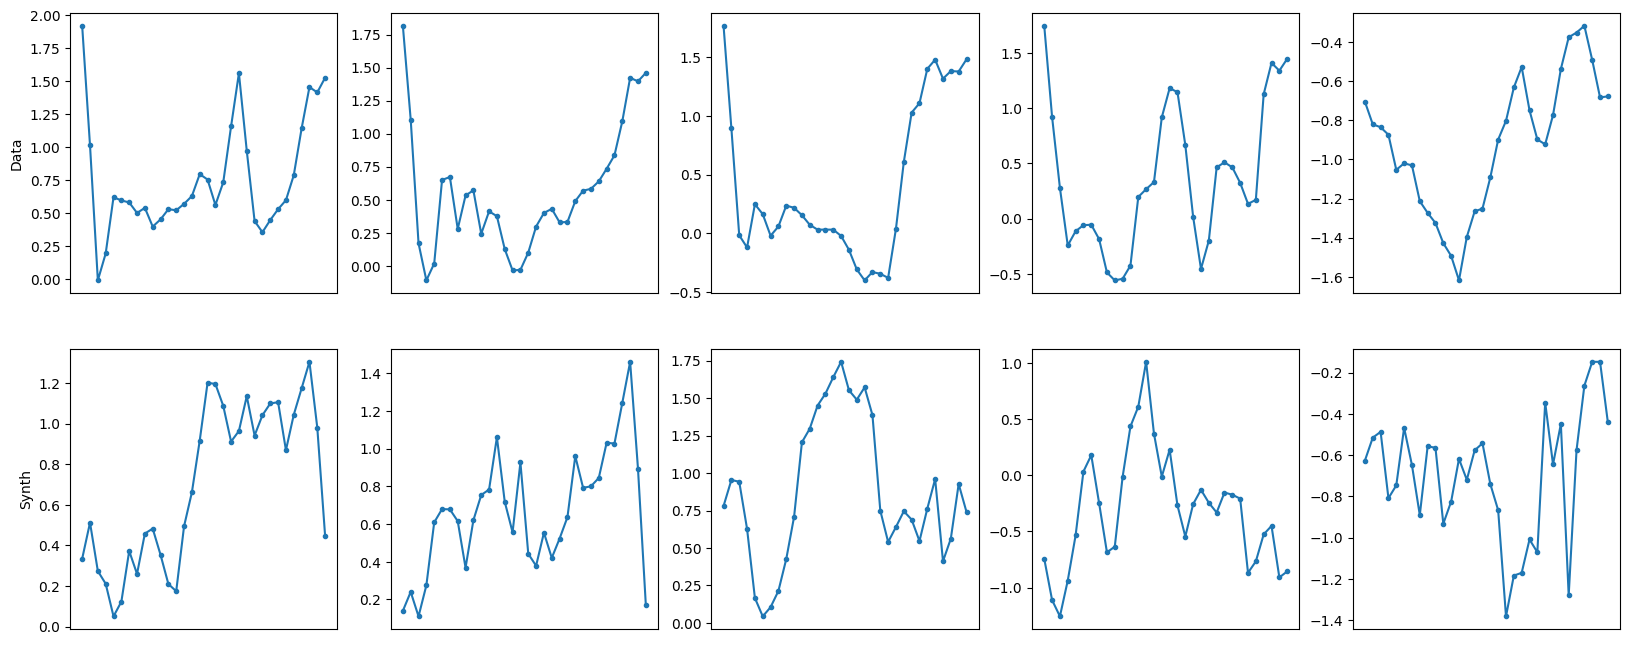

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


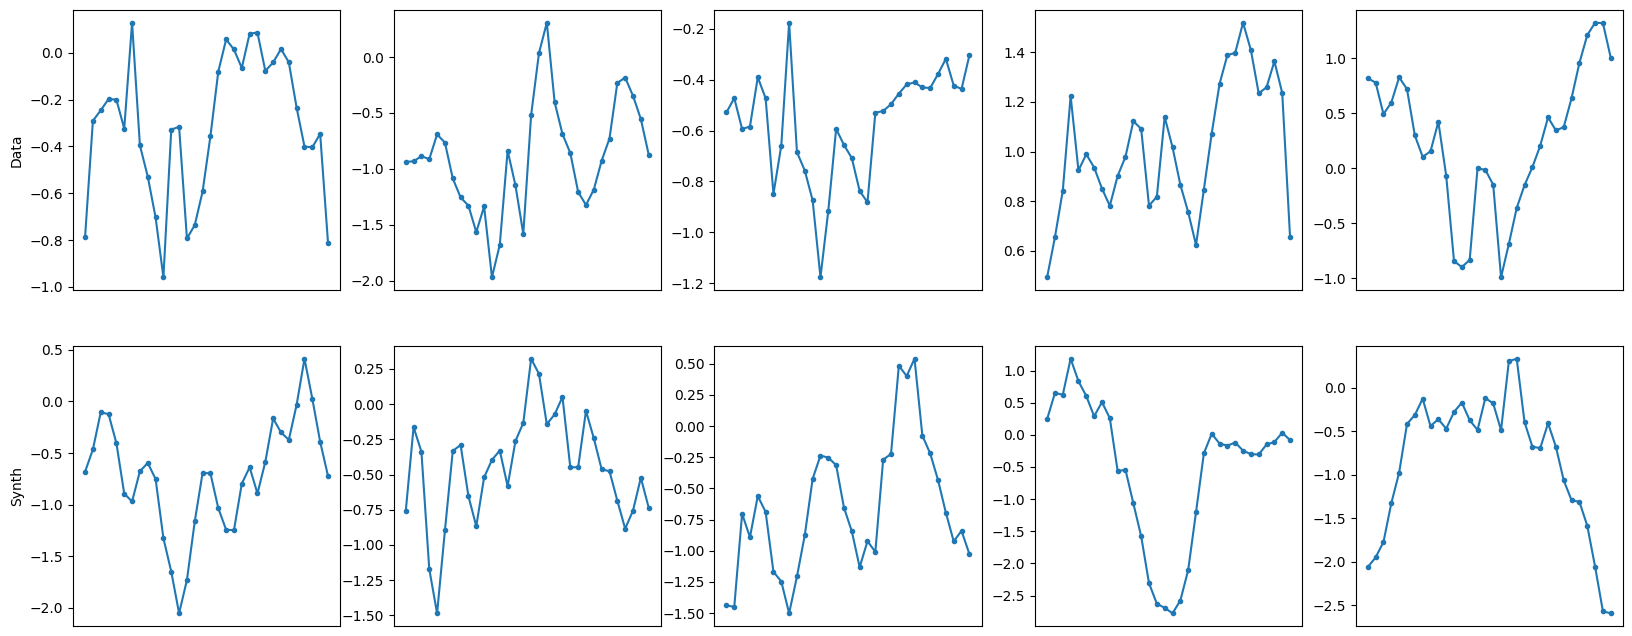

<Figure size 640x480 with 0 Axes>

torch.Size([2000, 1, 32])
GaussianKregions ψ


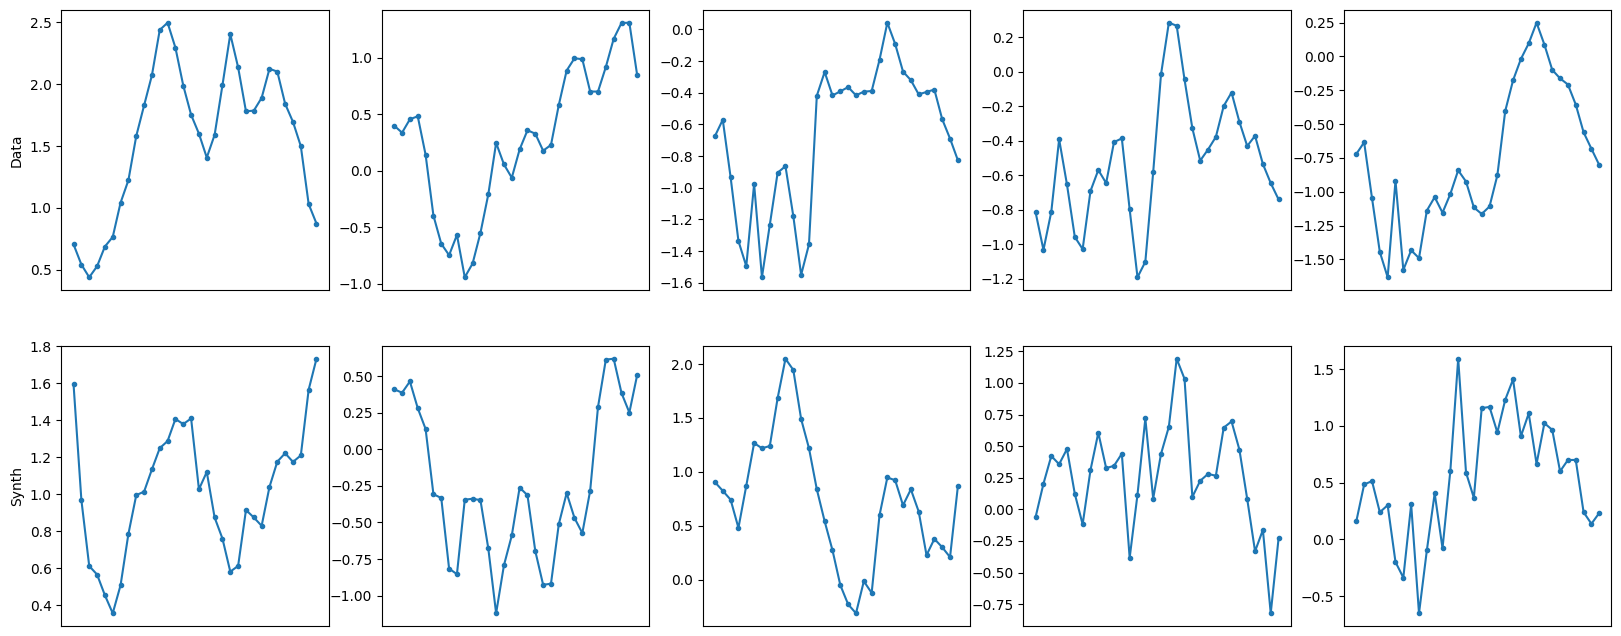

<Figure size 640x480 with 0 Axes>

In [13]:
for i in range(0,15): 
    for key, exp in experiments.items():
        print(results[key]['xt'].shape) 
        print(exp['label'])
        Compare_time_series_row(x1[i*5:i*5+5,:,:], results[key]['xt'][i*5:i*5+5,:,:],5)
        plt.suptitle(exp['label'])
        plt.show()


## Project diagnostics

### Scaling exponent ratio 

Computing structure functions for 22 lags...
Computing structure functions for 22 lags...


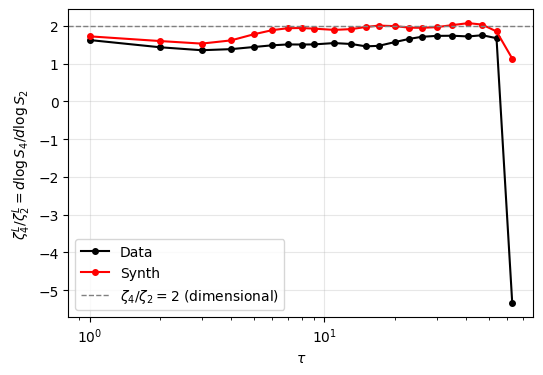

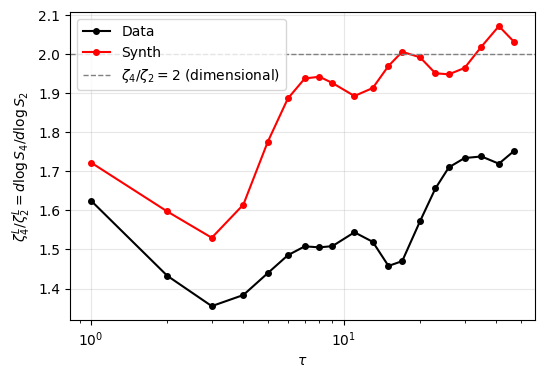

In [47]:
for key, exp in experiments.items():
    taus, ratio_data, ratio_synth = scaling_exponent_ratio_compare(x1, results[key]['xt'], 30) 

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus[:-2], ratio_data[:-2], 'ko-', ms=4, label='Data')
ax.plot(taus[:-2], ratio_synth[:-2], 'ro-', ms=4, label='Synth')
ax.axhline(2.0, color='grey', ls='--', lw=1, label=r'$\zeta_4/\zeta_2=2$ (dimensional)')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$\zeta_4^L/\zeta_2^L = d\log S_4 / d\log S_2$')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Histograms reproduction and other diagnostics 

Spectrum
GaussianKregions ψ


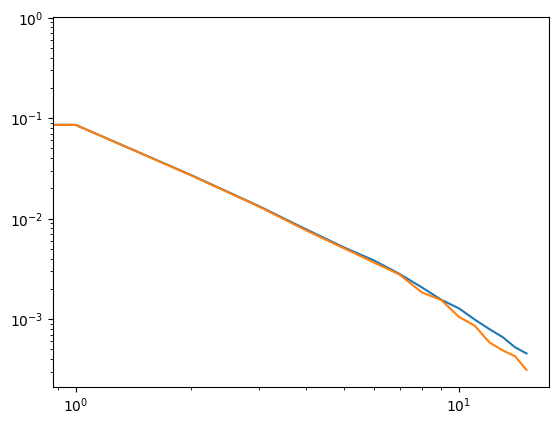

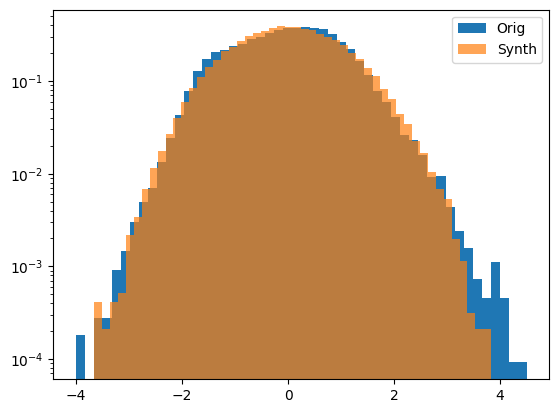

<Figure size 640x480 with 0 Axes>

Histogram
GaussianKregions ψ


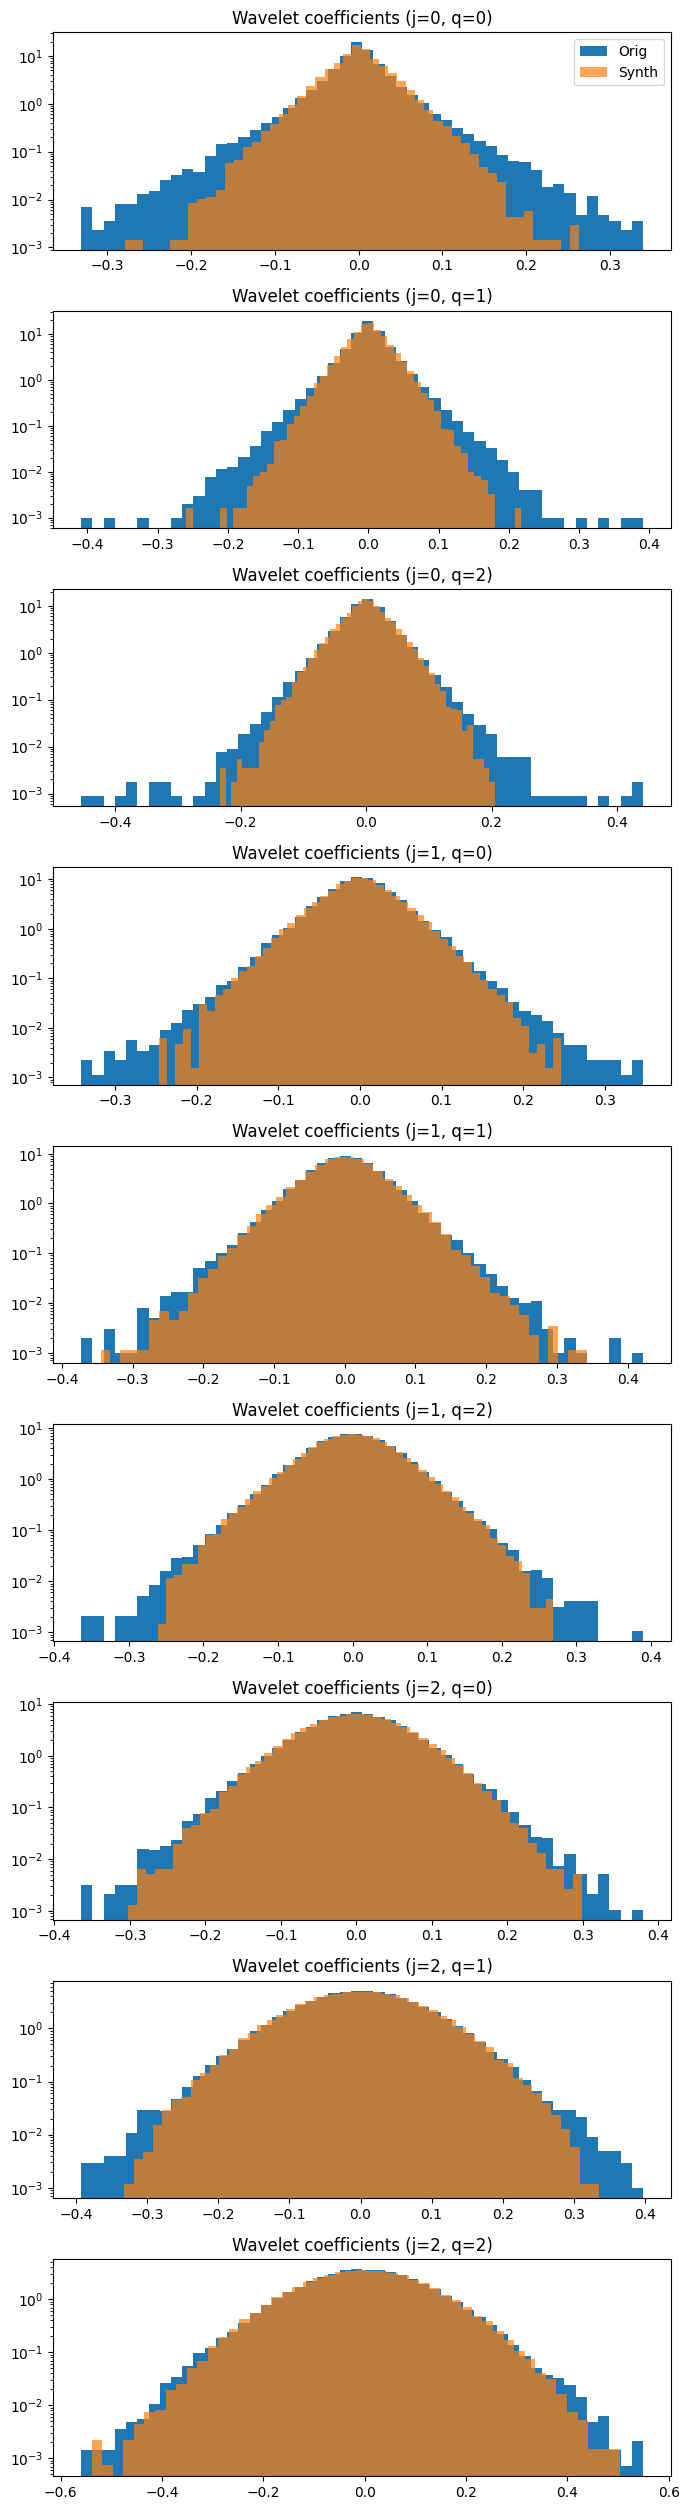

<Figure size 640x480 with 0 Axes>

Structure functions
GaussianKregions ψ
Computing structure functions for 15 lags...
Computing structure functions for 15 lags...


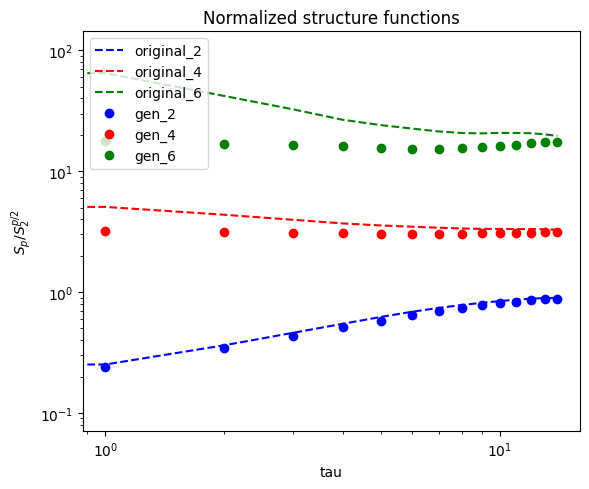

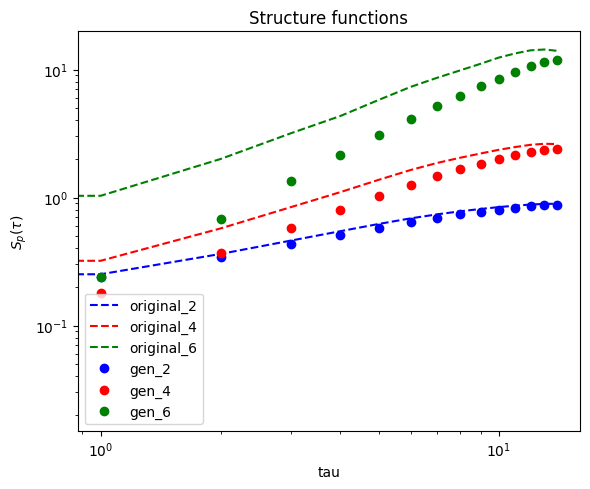

<Figure size 640x480 with 0 Axes>

In [85]:
def run_project_diagnostics(x_ref, results, experiments):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        for key, exp in experiments.items():
            print(exp['label'])
            diag_fun(x_ref, results[key]['xt'])
            plt.suptitle(f"{diag_name}: {exp['label']}")
            plt.show()

    #print('' + '=' * 80)
    #print('Cross statistics')
    #print('=' * 80)
    #for key, exp in experiments.items():
        #print(exp['label'])
        #cross_plot(x_ref, xt_cg, pq=[(3, 1), (3, 3), (4, 4)])
        #plt.suptitle(f"Cross statistics: {exp['label']}")
        #plt.show()

run_project_diagnostics(x1, results, experiments)


Marginal histograms


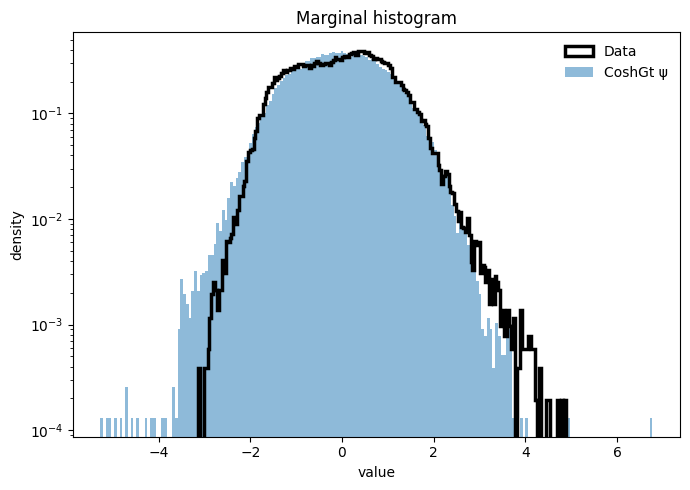

Per-band wavelet histograms  (one model at a time)


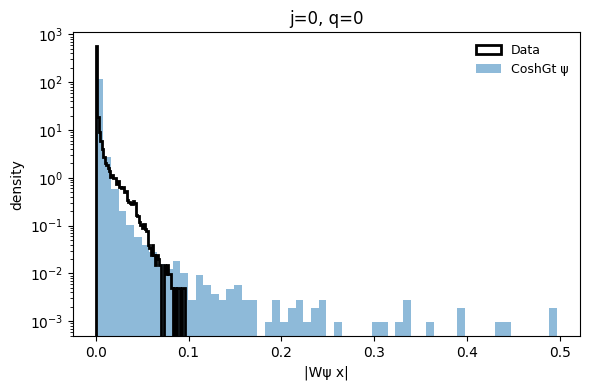

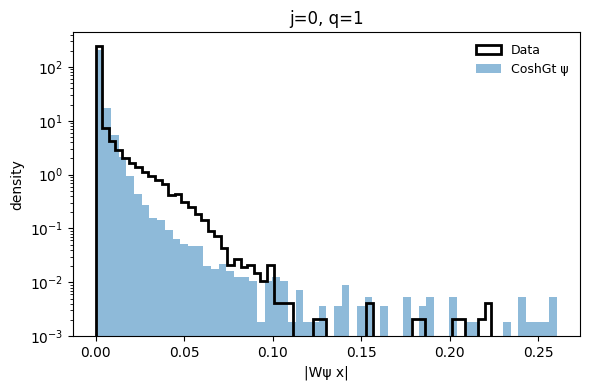

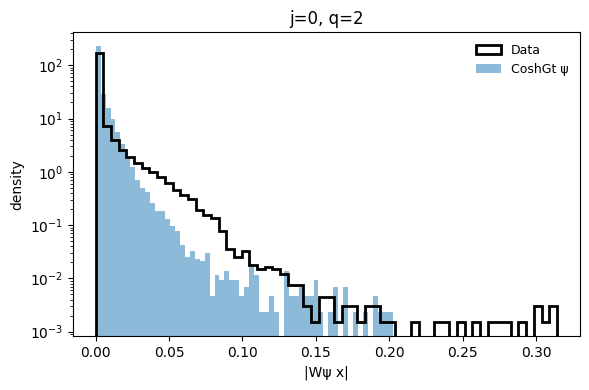

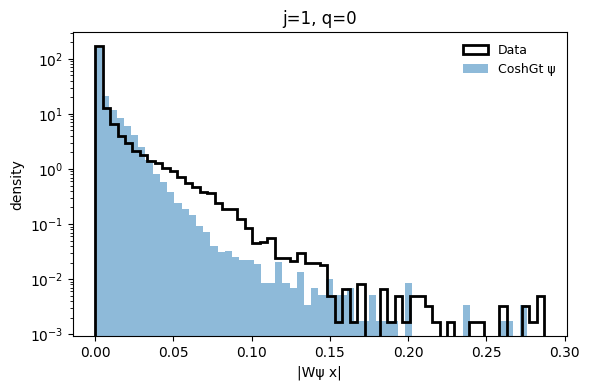

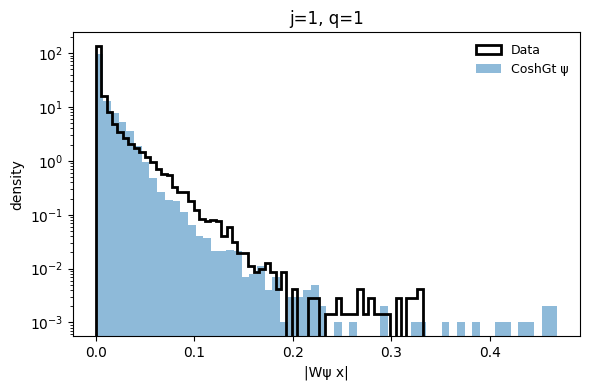

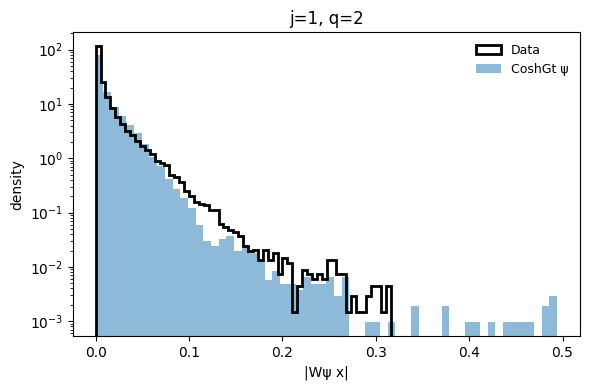

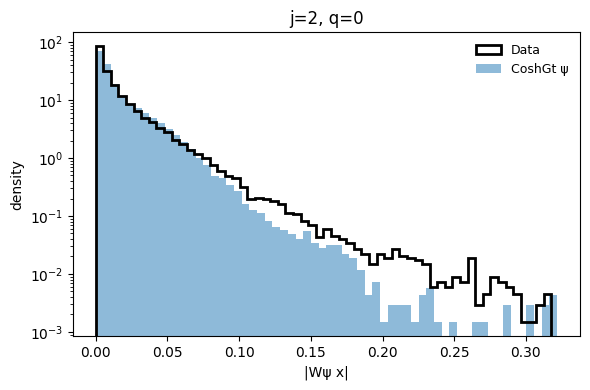

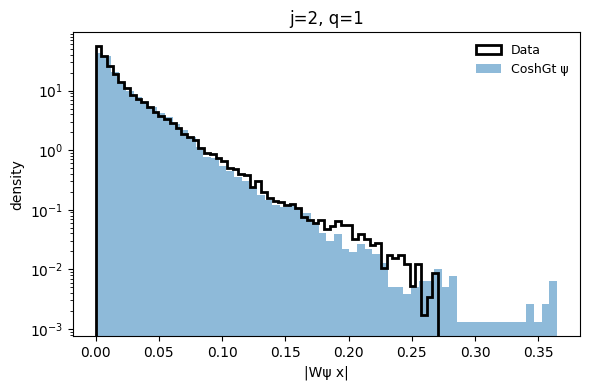

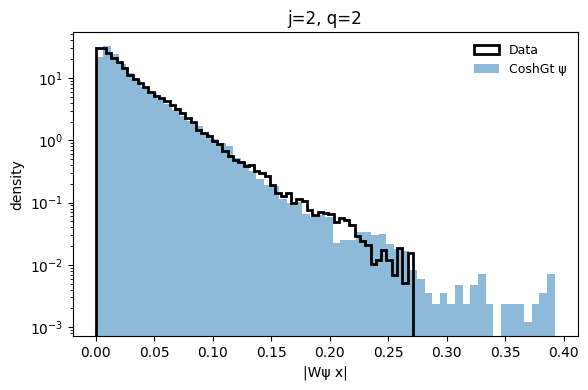

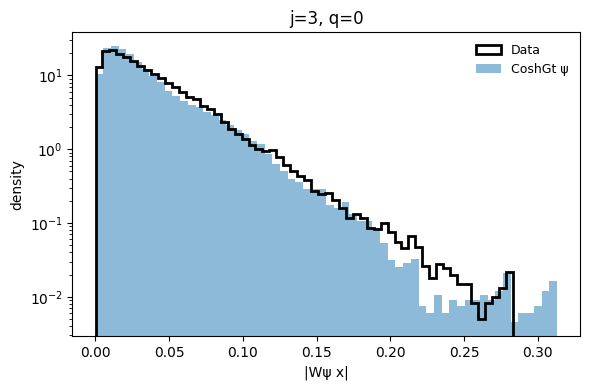

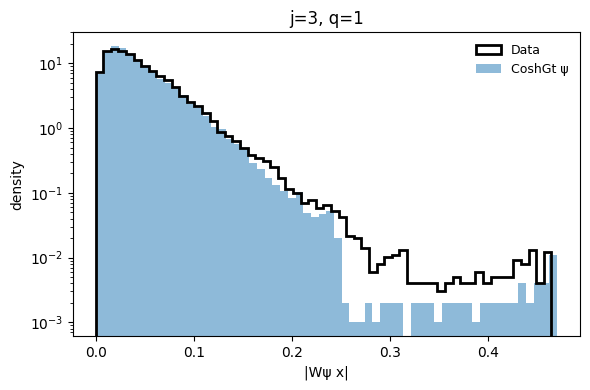

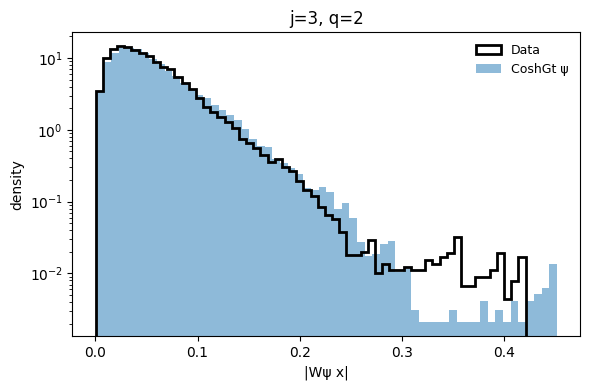

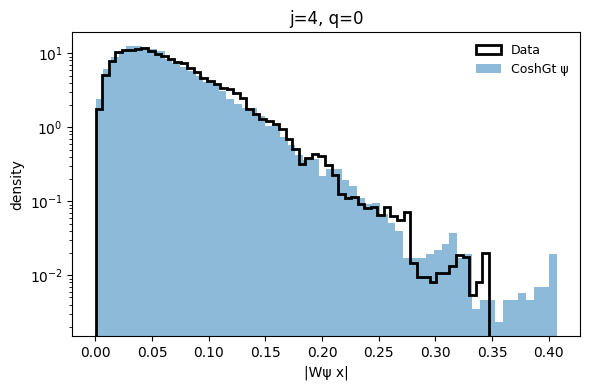

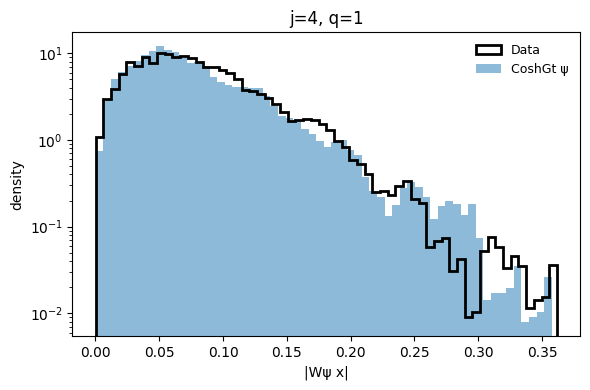

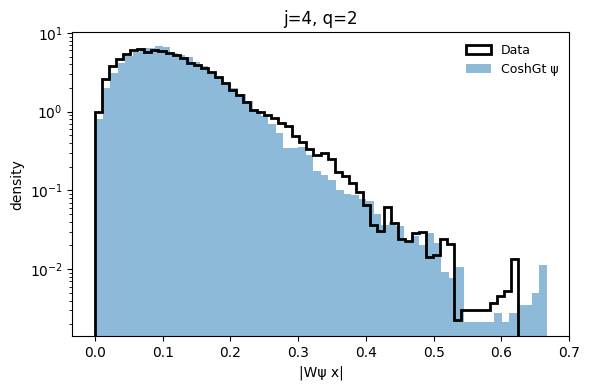

Visual comparison panels


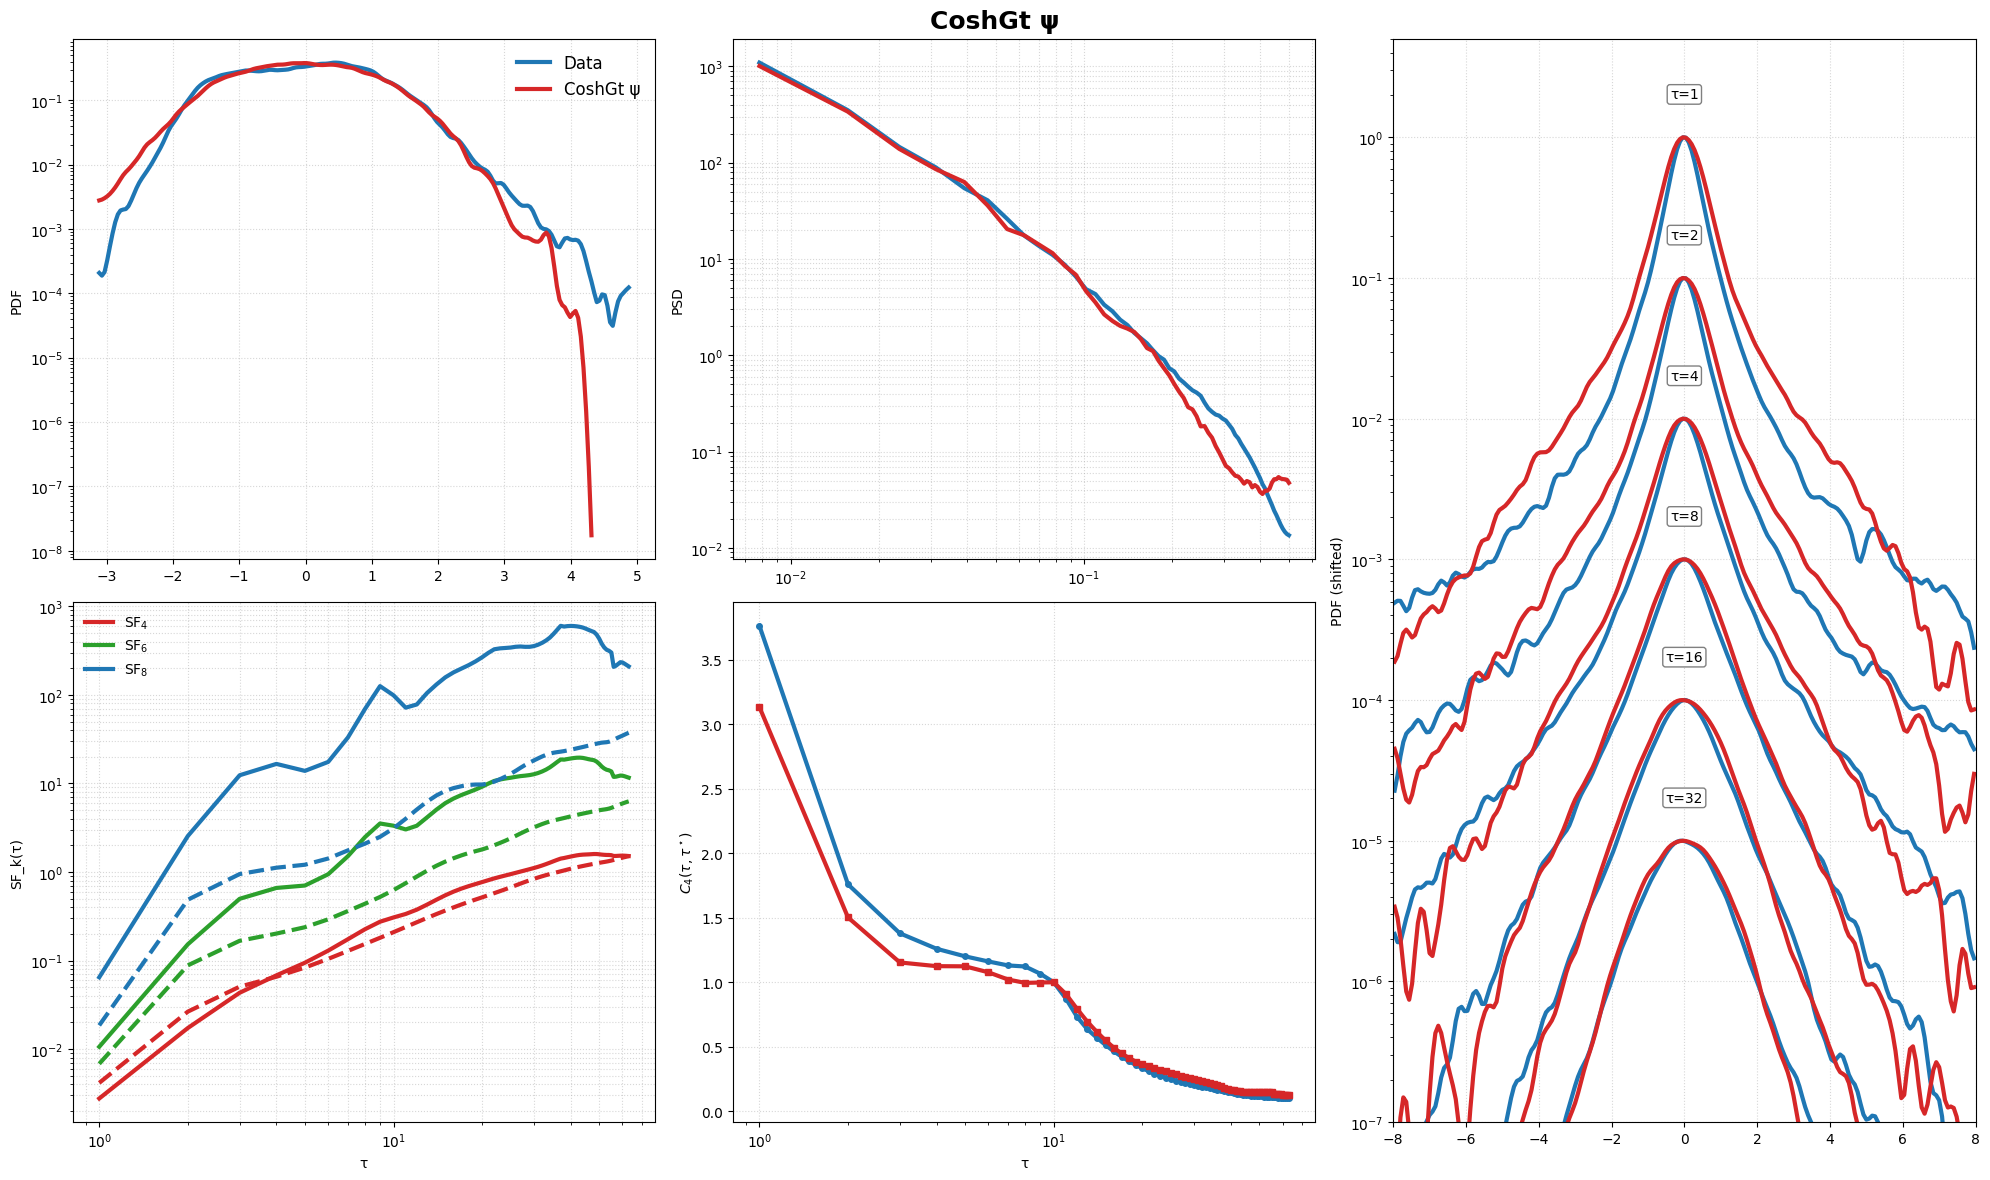

Scalar metrics
          mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
CoshGt ψ      4166780.25       0.007502          0.000047          0.052217           0.071398


,mean_rel_error,std_rel_error,spectrum_rel_mse,wasserstein_mean,structure_rel_mse
CoshGt ψ,4166780.25,0.007502,0.000047,0.052217,0.071398


In [23]:
from diagnostics import * 
df = run_diagnostics(x1, results, experiments)
df  # displays the metrics table in Jupyter

## Entropy bound comparison

In [41]:
results[key]['t']

tensor([0.0000e+00, 2.4998e-04, 4.9990e-04,  ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00])

In [23]:
results[key]['t'].shape[0]

8001

Contains NaN: tensor(True, device='cuda:0')
Contains Inf: tensor(False, device='cuda:0')
CoshGt ψ
  Entropy bound: nan
  Gaussian estimation: 66.83854675292969


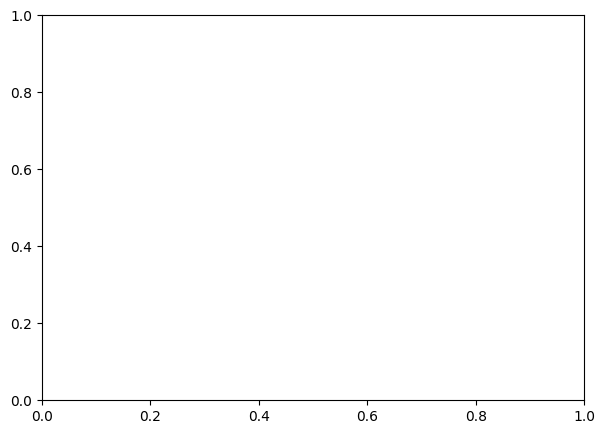

<class 'ValueError'>: x and y must have same first dimension, but have shapes (8001,) and (7999,)

In [24]:
def entropy_curves(x_ref, dH_t_bound, t_used):
    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound = dH_t_bound.cumsum(0).detach().cpu() / (t_used.shape[0]) + H_p_0
    H_t_gaussian = compute_gaussian_entropy(x_ref, interpolant, t_used)
    return H_t_bound, H_t_gaussian

plt.figure(figsize=(7, 5))
last_gaussian = None
for key, exp in experiments.items():
    H_t_bound, H_t_gaussian = entropy_curves(x1, results[key]['dH_t_bound'], results[key]['t'])

    print("Contains NaN:", torch.isnan(results[key]['dH_t_bound']).any())
    print("Contains Inf:", torch.isinf(results[key]['dH_t_bound']).any())
    last_gaussian = H_t_gaussian
    print(exp['label'])
    print('  Entropy bound:', H_t_bound[-1].item() if torch.is_tensor(H_t_bound[-1]) else H_t_bound[-1])
    print('  Gaussian estimation:', H_t_gaussian[-1].item() if torch.is_tensor(H_t_gaussian[-1]) else H_t_gaussian[-1])
    plt.plot(results[key]['t'].detach().cpu(), H_t_bound, label=f"bound: {exp['label']}")
"""
plt.plot(
    t.detach().cpu(),
    last_gaussian.detach().cpu() if torch.is_tensor(last_gaussian) else last_gaussian,
    '--',
    label='Gaussian entropy estimate',
)
plt.xlabel('t')
plt.ylabel('entropy')
plt.legend()
plt.tight_layout()
plt.show()
"""

## Project entropy plotting utility for each model